# Lección 6.3 · Cobertura y la teoría de Lander-Waterman: ¿cuánto hay que secuenciar?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-06-ngs/6.3_cobertura_lander_waterman.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 6 — Secuenciación de nueva generación (NGS)** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio | Lecciones 6.1 y 6.2 (qué es una lectura NGS), probabilidad básica (binomial y Poisson), NumPy |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Definir** cobertura (profundidad media) y amplitud de cobertura, y **calcular** a mano $c = LN/G$ para cualquier
   experimento.
2. **Simular** lecturas que caen al azar sobre un genoma y **obtener** el perfil de profundidad base a base.
3. **Demostrar** que la profundidad de una base sigue, aproximadamente, una distribución de **Poisson** de media $c$, y
   **deducir** que la fracción del genoma sin cubrir es $e^{-c}$.
4. **Derivar** paso a paso las fórmulas de **Lander y Waterman (1988)** para el número y la longitud esperada de
   contigs y huecos, y **verificarlas** por simulación.
5. **Reconocer** la **sobredispersión** de los datos reales (sesgo por GC, duplicados de PCR) y **ajustar** una
   distribución **binomial negativa** a una simulación sobre el genoma de *E. coli*.
6. **Resolver** la ecuación de diseño $P(D \geq k \mid c) \geq 1 - \alpha$ con Poisson y binomial negativa, y
   **calcular** la profundidad necesaria para **detectar una variante heterocigota** con una probabilidad dada.
7. **Interpretar** una **curva de saturación** (lecturas únicas frente a lecturas secuenciadas) y la tasa de duplicados.
8. **Planificar** un experimento: cuántas lecturas y cuántas gigabases pedir para una bacteria, un exoma o un genoma
   humano a 30×.

## 🗺️ Mapa de la clase

1. ¿Qué es la cobertura? $c = LN/G$
2. Lecturas que caen al azar (🎬 animación)
3. La profundidad sigue una Poisson: bases sin cubrir $= e^{-c}$
4. La teoría de Lander-Waterman: contigs y huecos (🎬 animación)
5. 🎛️ Calculadora interactiva de Lander-Waterman
6. Lecturas largas y repeticiones
7. El mundo real: sesgo por GC y sobredispersión en *E. coli*
8. 🎛️ Poisson frente a binomial negativa
9. ¿Cuánta profundidad necesito? La ecuación de diseño $P(D \geq k) \geq 1 - \alpha$ (🎛️ interactivo)
10. ¿Cuánta profundidad para ver un heterocigoto? (puente al Módulo 9)
11. Duplicados de PCR y curvas de saturación
12. Planificar un experimento: la calculadora final
13. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Rectangle
from scipy.stats import poisson, nbinom, binom
from scipy.special import gammaln

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) copia del repositorio en GitHub;
    3) servicio original (NCBI). Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [f"{RAW}/data/{name}", live_url]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=120) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

rng = np.random.default_rng(63)       # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 6.3")

Entorno listo ✔  |  Colab: False


Listo para la Lección 6.3


## 1. ¿Qué es la cobertura? $c = LN/G$

Un secuenciador de lecturas cortas no lee un cromosoma de punta a punta. Primero se **rompe** el ADN en millones de
fragmentos al azar, y luego se lee un trocito de cada fragmento: una **lectura** (*read*) de 100–300 bases. Imagine
que alguien tritura cien copias de un libro, saca al azar un puñado de tiras de papel y las lee. Para reconstruir el
libro necesita que **cada frase** aparezca en al menos una tira, y mejor aún en varias, para no fiarse de una sola
lectura con una errata. La pregunta de esta clase es: **¿cuántas tiras hay que leer?**

La medida central es la **cobertura** (o **profundidad media**): cuántas veces, en promedio, fue leída cada base del
genoma. Se calcula con una simple regla de tres: el total de bases leídas dividido por el tamaño del genoma.

$$
\boxed{\;c \;=\; \frac{L \cdot N}{G}\;}
$$

| Símbolo | Significado | Unidades |
|---|---|---|
| $c$ | **cobertura** o profundidad media (se escribe "30×", "treinta equis") | veces |
| $L$ | longitud de cada lectura | pb (pares de bases) |
| $N$ | número de lecturas (en *paired-end*, cada par aporta **dos** lecturas) | lecturas |
| $G$ | tamaño del genoma (o de la región objetivo, en un exoma) | pb |
| $L \cdot N$ | rendimiento total del experimento | pb (se suele dar en Gb $=10^9$ pb) |
| $D_x$ | **profundidad** en la posición $x$: número de lecturas que la cubren | lecturas |

Tres palabras que se confunden a menudo:

* **Profundidad** ($D_x$): propiedad de **una base**. "La posición 1 234 567 tiene 28 lecturas encima."
* **Cobertura media** ($c$): el **promedio** de $D_x$ sobre todas las bases. Es lo que se pide al laboratorio.
* **Amplitud de cobertura** (*breadth*): la **fracción del genoma** con profundidad $\geq 1$ (o $\geq 10$, $\geq 20$…).
  Dos experimentos con la misma cobertura media pueden tener amplitudes muy distintas, como veremos en la sección 7.

### Ejemplo a mano

**Una bacteria.** El genoma de *E. coli* K-12 mide $G = 4\,641\,652$ pb. Si secuenciamos $N = 1\,000\,000$ de
lecturas de $L = 150$ pb:

$$
c = \frac{150 \times 1\,000\,000}{4\,641\,652} = \frac{1.5 \times 10^{8}}{4.64 \times 10^{6}} \approx 32.3\times
$$

**Un humano a 30×.** Con $G \approx 3.1 \times 10^9$ pb y lecturas de 150 pb, despejamos $N$:

$$
N = \frac{c\,G}{L} = \frac{30 \times 3.1\times 10^{9}}{150} = 6.2 \times 10^{8}\ \text{lecturas}
\;=\; 310 \text{ millones de pares}
\;\approx\; 93\ \text{Gb}
$$

La cuenta es sencilla, pero **no** nos dice si quedó algún rincón del genoma sin leer, ni cuántos. Para eso hay que
pensar en **dónde** caen las lecturas.

In [2]:
def coverage(L, N, G):
    """Cobertura media c = L·N / G."""
    return L * N / G

def reads_needed(c, L, G):
    """Número de lecturas necesarias para una cobertura c."""
    return c * G / L

print(f"E. coli, 1 M lecturas de 150 pb : c = {coverage(150, 1e6, 4_641_652):.1f}×")
n_h = reads_needed(30, 150, 3.1e9)
print(f"Humano a 30×                   : N = {n_h:.3g} lecturas = {n_h / 2 / 1e6:.0f} M pares = {n_h * 150 / 1e9:.0f} Gb")

E. coli, 1 M lecturas de 150 pb : c = 32.3×
Humano a 30×                   : N = 6.2e+08 lecturas = 310 M pares = 93 Gb


Para simular necesitamos dos piezas: sortear el **inicio** de cada lectura (uniforme sobre el genoma) y convertir una
lista de lecturas en un **perfil de profundidad** base a base. Lo segundo parece requerir un bucle por lectura, pero
hay un truco clásico: en un arreglo auxiliar se suma $+1$ donde empieza cada lectura y $-1$ donde termina; la **suma
acumulada** de ese arreglo es exactamente la profundidad. Así se procesa un millón de lecturas en milisegundos.

Tratamos el genoma como **circular** (el de *E. coli* lo es): una lectura que empieza cerca del final continúa por el
principio. Esto evita los "bordes", donde la cobertura cae artificialmente.

In [3]:
def simulate_starts(N, G, rng, weights=None):
    """Posiciones de inicio (0-based) de N lecturas: uniformes, o proporcionales a `weights`."""
    if weights is None:
        return rng.integers(0, G, int(N))
    return rng.choice(G, size=int(N), p=weights / weights.sum())

def depth_profile(starts, L, G):
    """Profundidad por base en un genoma circular: +1 al inicio, −1 al final y suma acumulada."""
    diff = np.zeros(G + 1, dtype=np.int64)
    np.add.at(diff, starts, 1)
    ends = starts + L
    wrap = ends > G                       # lecturas que dan la vuelta al círculo
    np.add.at(diff, np.where(wrap, ends - G, ends), -1)
    diff[0] += wrap.sum()                 # ...y continúan desde la posición 0
    return np.cumsum(diff[:G])

def pack_rows(starts, L):
    """Asigna cada lectura a una fila para dibujarlas sin que se tapen (como en un visor de alineamientos)."""
    row_end, rows = [], np.zeros(len(starts), int)
    for i in np.argsort(starts):
        for r, e in enumerate(row_end):
            if starts[i] > e + 3:
                rows[i], row_end[r] = r, starts[i] + L
                break
        else:
            rows[i] = len(row_end); row_end.append(starts[i] + L)
    return rows

# Prueba en miniatura: genoma de 20 pb y tres lecturas de 6 pb
toy = depth_profile(np.array([2, 5, 17]), 6, 20)
print("profundidad:", toy)          # la lectura que empieza en 17 da la vuelta y cubre 0, 1 y 2

profundidad: [1 1 2 1 1 2 2 2 1 1 1 0 0 0 0 0 0 1 1 1]


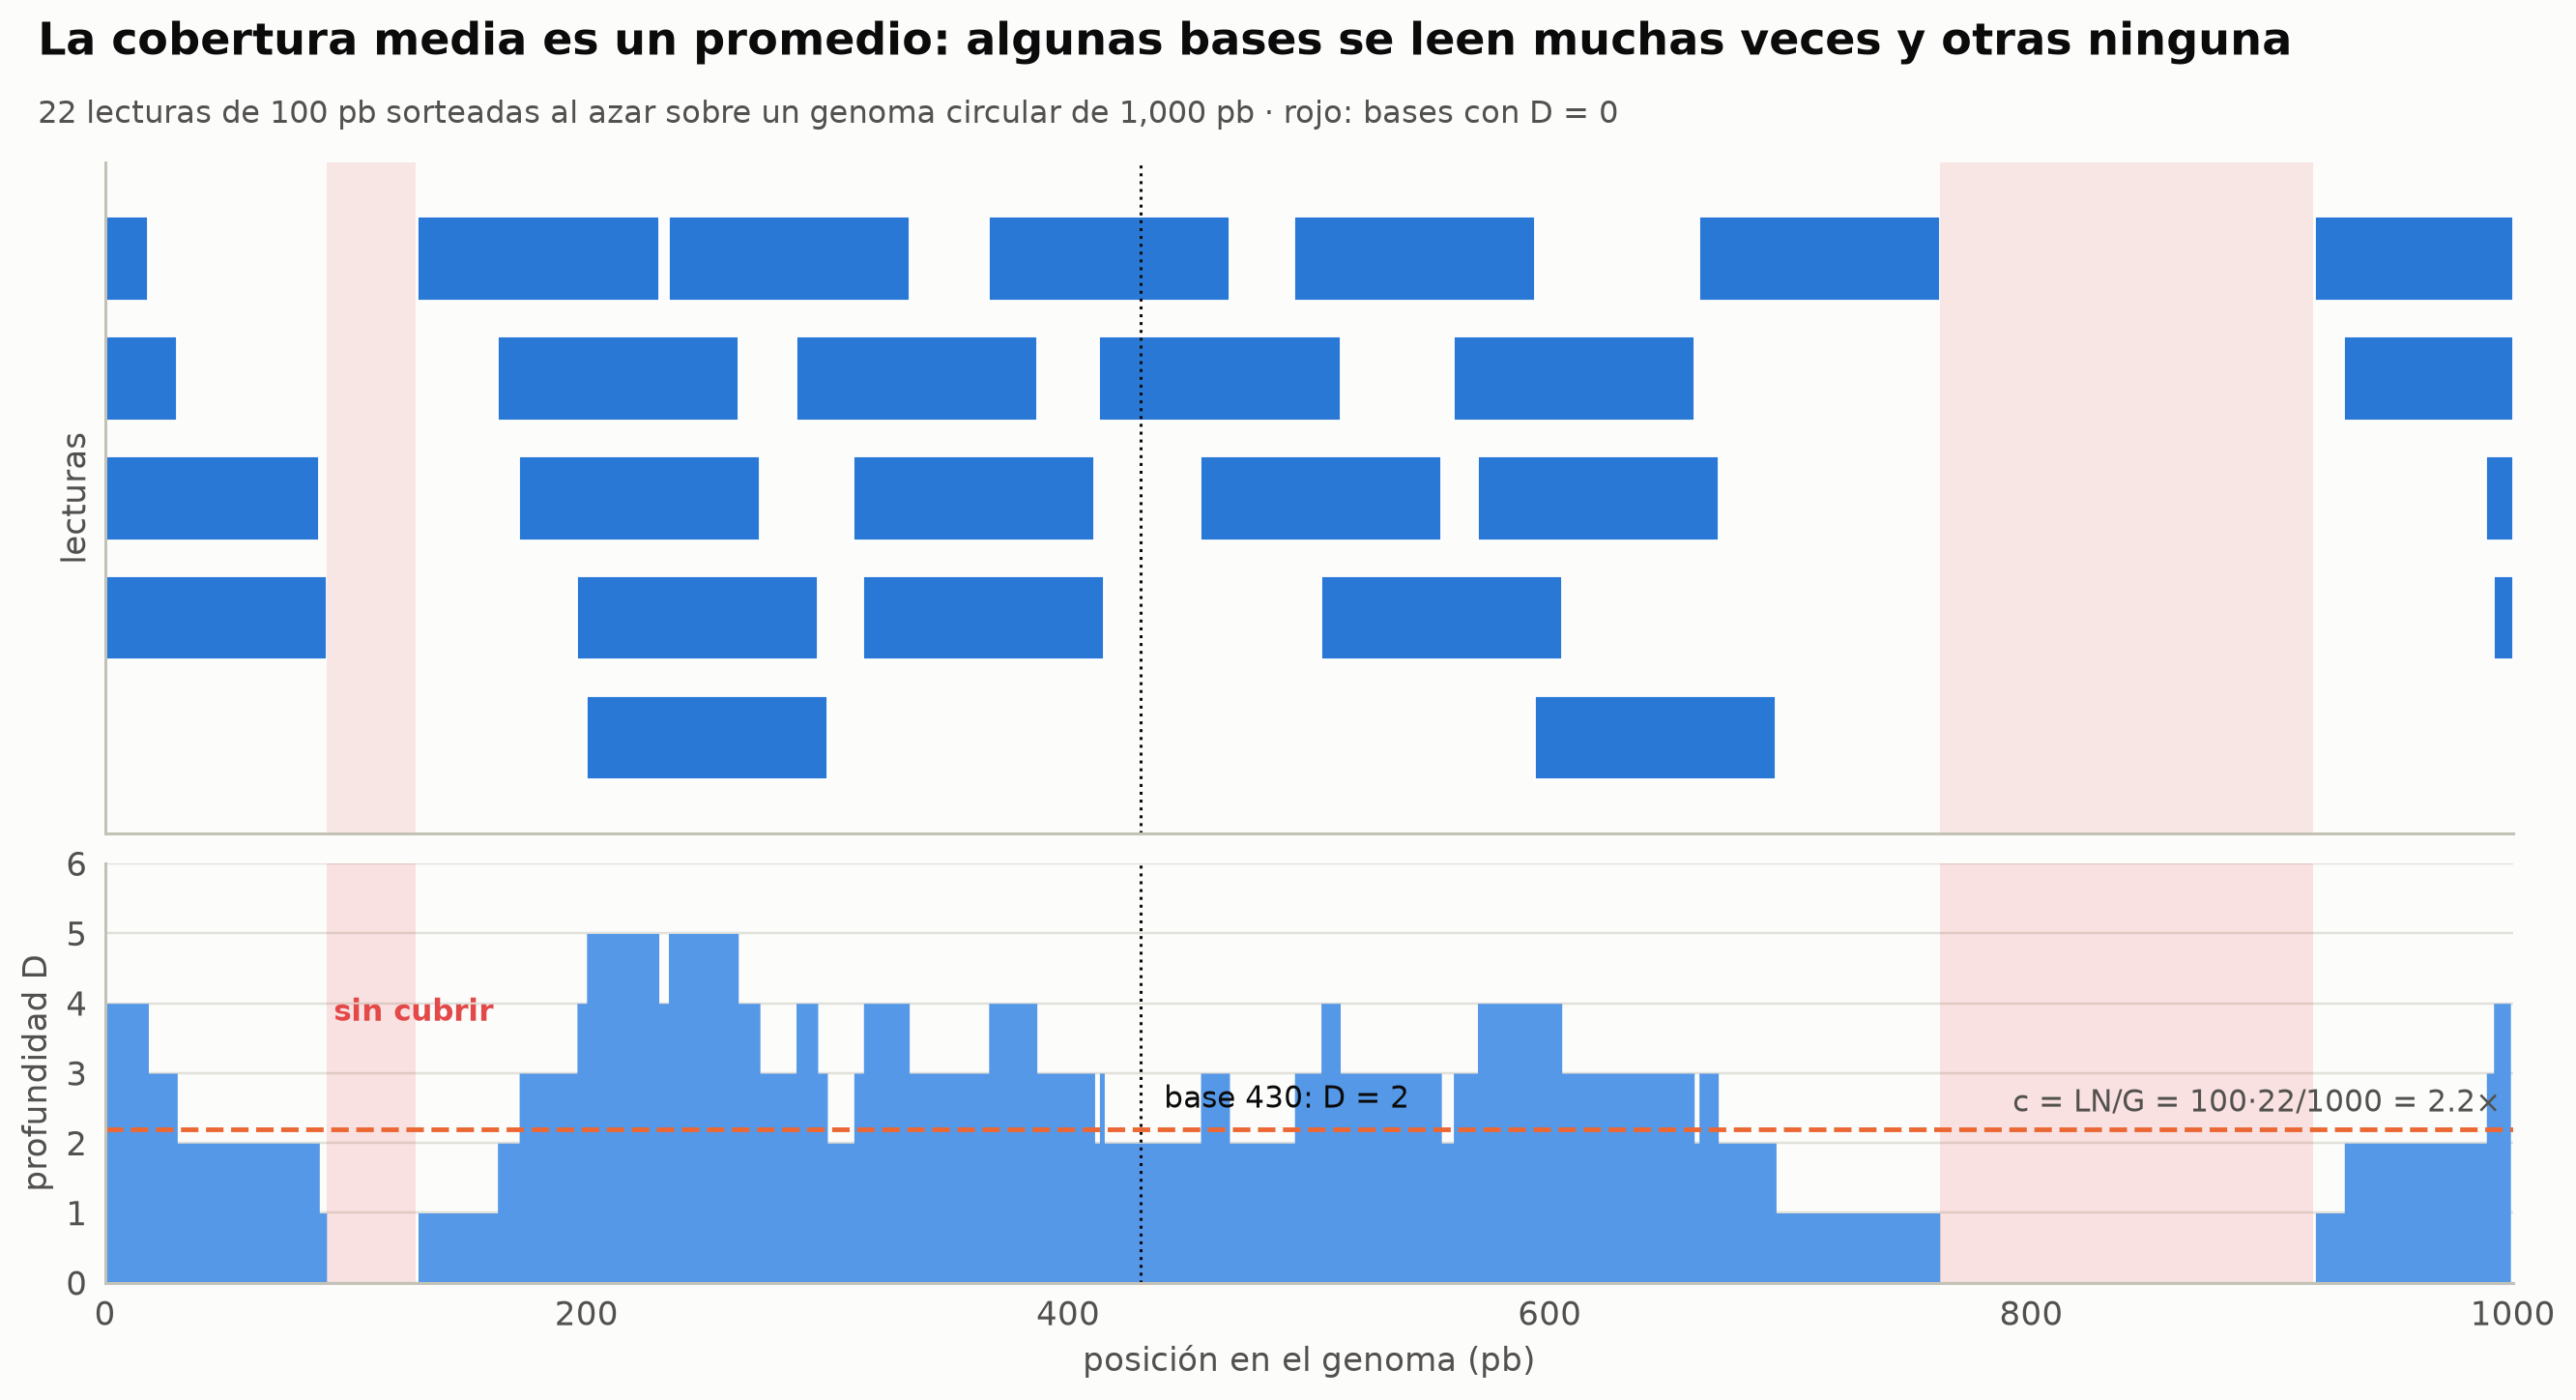

In [4]:
G_TOY, L_TOY = 1_000, 100
starts_toy = simulate_starts(22, G_TOY, rng)
d_toy = depth_profile(starts_toy, L_TOY, G_TOY)
rows_toy = pack_rows(starts_toy, L_TOY)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5.8), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1]))
for s, r in zip(starts_toy, rows_toy):
    for a, b in ([(s, s + L_TOY)] if s + L_TOY <= G_TOY else [(s, G_TOY), (0, s + L_TOY - G_TOY)]):
        ax1.add_patch(Rectangle((a, r - 0.35), b - a, 0.7, fc=ec.BLUE, ec="white", lw=0.6))
ax1.set_ylim(rows_toy.max() + 0.8, -0.8); ax1.set_yticks([]); ax1.set_ylabel("lecturas")
ax2.fill_between(np.arange(G_TOY), d_toy, step="post", color=ec.SEQ_BLUE[5], lw=0)
gap = d_toy == 0
ax2.fill_between(np.arange(G_TOY), 0, d_toy.max() + 1, where=gap, step="post", color=ec.RED, alpha=0.15, lw=0)
ax1.fill_between(np.arange(G_TOY), -0.8, rows_toy.max() + 0.8, where=gap, step="post", color=ec.RED, alpha=0.12, lw=0)
b0 = 430
ax2.axvline(b0, color=ec.INK, lw=1, ls=":"); ax1.axvline(b0, color=ec.INK, lw=1, ls=":")
ax2.annotate(f"base {b0}: D = {d_toy[b0]}", (b0, d_toy[b0]), xytext=(8, 12), textcoords="offset points",
             fontsize=10, color=ec.INK)
ax2.axhline(d_toy.mean(), color=ec.ORANGE, lw=1.6, ls="--")
ax2.text(G_TOY - 5, d_toy.mean() + 0.15, f"c = LN/G = {L_TOY}·{len(starts_toy)}/{G_TOY} = {d_toy.mean():.1f}×",
         ha="right", va="bottom", fontsize=10, color=ec.INK_2)
if gap.any():
    g0 = np.argmax(gap)
    ax2.text(g0 + 3, d_toy.max() * 0.75, "sin cubrir", color=ec.RED, fontsize=10, fontweight="bold")
ax2.set_xlim(0, G_TOY); ax2.set_ylim(0, d_toy.max() + 1)
ax2.set_xlabel("posición en el genoma (pb)"); ax2.set_ylabel("profundidad D")
ec.fig_title(fig, "La cobertura media es un promedio: algunas bases se leen muchas veces y otras ninguna",
             f"{len(starts_toy)} lecturas de {L_TOY} pb sorteadas al azar sobre un genoma circular de {G_TOY:,} pb · rojo: bases con D = 0")
plt.show()

> 🔎 **Qué observamos.** Con 22 lecturas la cobertura media es $22 \times 100 / 1\,000 = 2.2\times$, pero la
> profundidad **varía mucho** de una base a otra: hay zonas con 4–5 lecturas encima y, casi siempre, algún tramo en
> rojo que **nadie leyó**. La cobertura media no garantiza nada sobre una base concreta. El resto de la clase consiste
> en cuantificar esa variabilidad.

✅ **Compruebe su comprensión.** Un colega secuencia el genoma de la levadura *S. cerevisiae* ($G \approx 12.1$ Mb)
con 2 millones de **pares** de lecturas de 2×150 pb. ¿Qué cobertura obtiene? (Respuesta: $N = 4 \times 10^6$
lecturas, así que $c = 150 \times 4\times10^6 / 1.21\times10^7 \approx 49.6\times$. Olvidar que cada par son dos
lecturas es el error más común: daría la mitad.)

## 2. Lecturas que caen al azar

Veamos el proceso en cámara lenta. Tomamos un genoma circular de 2 000 pb y dejamos caer lecturas de 100 pb, una
tras otra, en posiciones sorteadas al azar, hasta llegar a 200 lecturas ($c = 10\times$). Cada lectura se apila en la
primera fila libre, como las cajas de un visor de alineamientos (IGV, por ejemplo). Abajo se dibuja la profundidad de
cada base y, en rojo, las bases que todavía nadie ha leído.

> 🤔 **Antes de ejecutar, prediga:** cuando la cobertura media sea de $3\times$, ¿qué porcentaje del genoma cree que
> seguirá sin cubrir: 0 %, alrededor del 5 %, o alrededor del 30 %?

![Las lecturas caen al azar sobre un genoma de 2 000 pb: la pila crece, la profundidad se vuelve más pareja y los huecos rojos desaparecen al ritmo que predice e^(−c)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-06-ngs/6.3_lecturas_caen.gif)

*Las lecturas caen al azar sobre un genoma de 2 000 pb: la pila crece, la profundidad se vuelve más pareja y los huecos rojos desaparecen al ritmo que predice e^(−c)*

In [5]:
G_AN, L_AN, N_AN = 2_000, 100, 200
starts_an = simulate_starts(N_AN, G_AN, rng)

# Apilado en orden de llegada: cada lectura ocupa la fila libre más baja
occupied = np.zeros((40, G_AN), bool)
row_an = np.zeros(N_AN, int)
for i, s in enumerate(starts_an):
    span = (s + np.arange(L_AN)) % G_AN
    r = next(r for r in range(40) if not occupied[r, span].any())
    occupied[r, span] = True; row_an[i] = r
n_rows = row_an.max() + 1
counts = np.unique(np.r_[0, np.linspace(4, N_AN, 49).astype(int)])      # lecturas mostradas en cada cuadro
final_depth = depth_profile(starts_an, L_AN, G_AN)

fig = plt.figure(figsize=(12, 6.6))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 1], hspace=0.08)
ax_p, ax_d = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
patches = []
for s, r in zip(starts_an, row_an):
    parts = [(s, L_AN)] if s + L_AN <= G_AN else [(s, G_AN - s), (0, s + L_AN - G_AN)]
    patches.append([ax_p.add_patch(Rectangle((a, r + 0.1), w, 0.8, fc=ec.BLUE, ec="white", lw=0.4, visible=False))
                    for a, w in parts])
ax_p.set_xlim(0, G_AN); ax_p.set_ylim(0, n_rows + 0.5); ax_p.set_xticks([]); ax_p.set_yticks([])
ax_p.set_ylabel("pila de lecturas")
ymax_d = final_depth.max() + 2
ax_d.set_xlim(0, G_AN); ax_d.set_ylim(0, ymax_d)
ax_d.set_xlabel("posición en el genoma (pb)"); ax_d.set_ylabel("profundidad D")
mean_line = ax_d.axhline(0, color=ec.ORANGE, lw=1.6, ls="--")
status = fig.text(0.01, 0.875, "", fontsize=11, color=ec.INK, va="top")
fig.text(0.01, 0.975, "Al llover lecturas, los huecos desaparecen deprisa pero la profundidad nunca es pareja",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.93, f"Genoma circular de {G_AN:,} pb · lecturas de {L_AN} pb en posiciones al azar · "
         "rojo: bases sin cubrir · línea naranja: cobertura media c",
         fontsize=10.5, color=ec.INK_2, va="top")
dyn = []

def update(f):
    global dyn
    n = counts[f]
    for i in range(N_AN):
        for p in patches[i]:
            p.set_visible(i < n)
    for art in dyn:
        art.remove()
    d = depth_profile(starts_an[:n], L_AN, G_AN)
    x = np.arange(G_AN)
    dyn = [ax_d.fill_between(x, d, step="post", color=ec.SEQ_BLUE[5], lw=0),
           ax_d.fill_between(x, 0, ymax_d, where=d == 0, step="post", color=ec.RED, alpha=0.18, lw=0)]
    c = n * L_AN / G_AN
    mean_line.set_ydata([c, c])
    status.set_text(f"N = {n:>3} lecturas   ·   c = {c:4.1f}×   ·   sin cubrir: {np.mean(d == 0):6.1%}"
                    f"   (predicción e^(−c) = {np.exp(-c):6.1%})")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(counts), interval=180, name="6.3_lecturas_caen")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio casi cada lectura nueva cubre terreno virgen, y el rojo se retira muy rápido.
> Pero la retirada se hace cada vez más lenta: las últimas bases sin cubrir son difíciles de alcanzar, porque la
> mayoría de las lecturas nuevas cae sobre zonas ya leídas. Hacia $c = 3\times$ todavía queda alrededor de un **5 %**
> sin cubrir; a $c = 10\times$ el genoma de juguete queda completo. La línea de estado compara, cuadro a cuadro, la
> fracción sin cubrir con el número $e^{-c}$, que deduciremos en la próxima sección. Fíjese también en que el perfil de
> profundidad sigue siendo **muy irregular** incluso al final: a $10\times$ hay bases con 4 lecturas y otras con 18.

¿Qué tan irregular es la profundidad a coberturas realistas? Simulamos un fragmento de 20 kb a tres coberturas y
dividimos la profundidad entre su media, para poder compararlas en la misma escala.

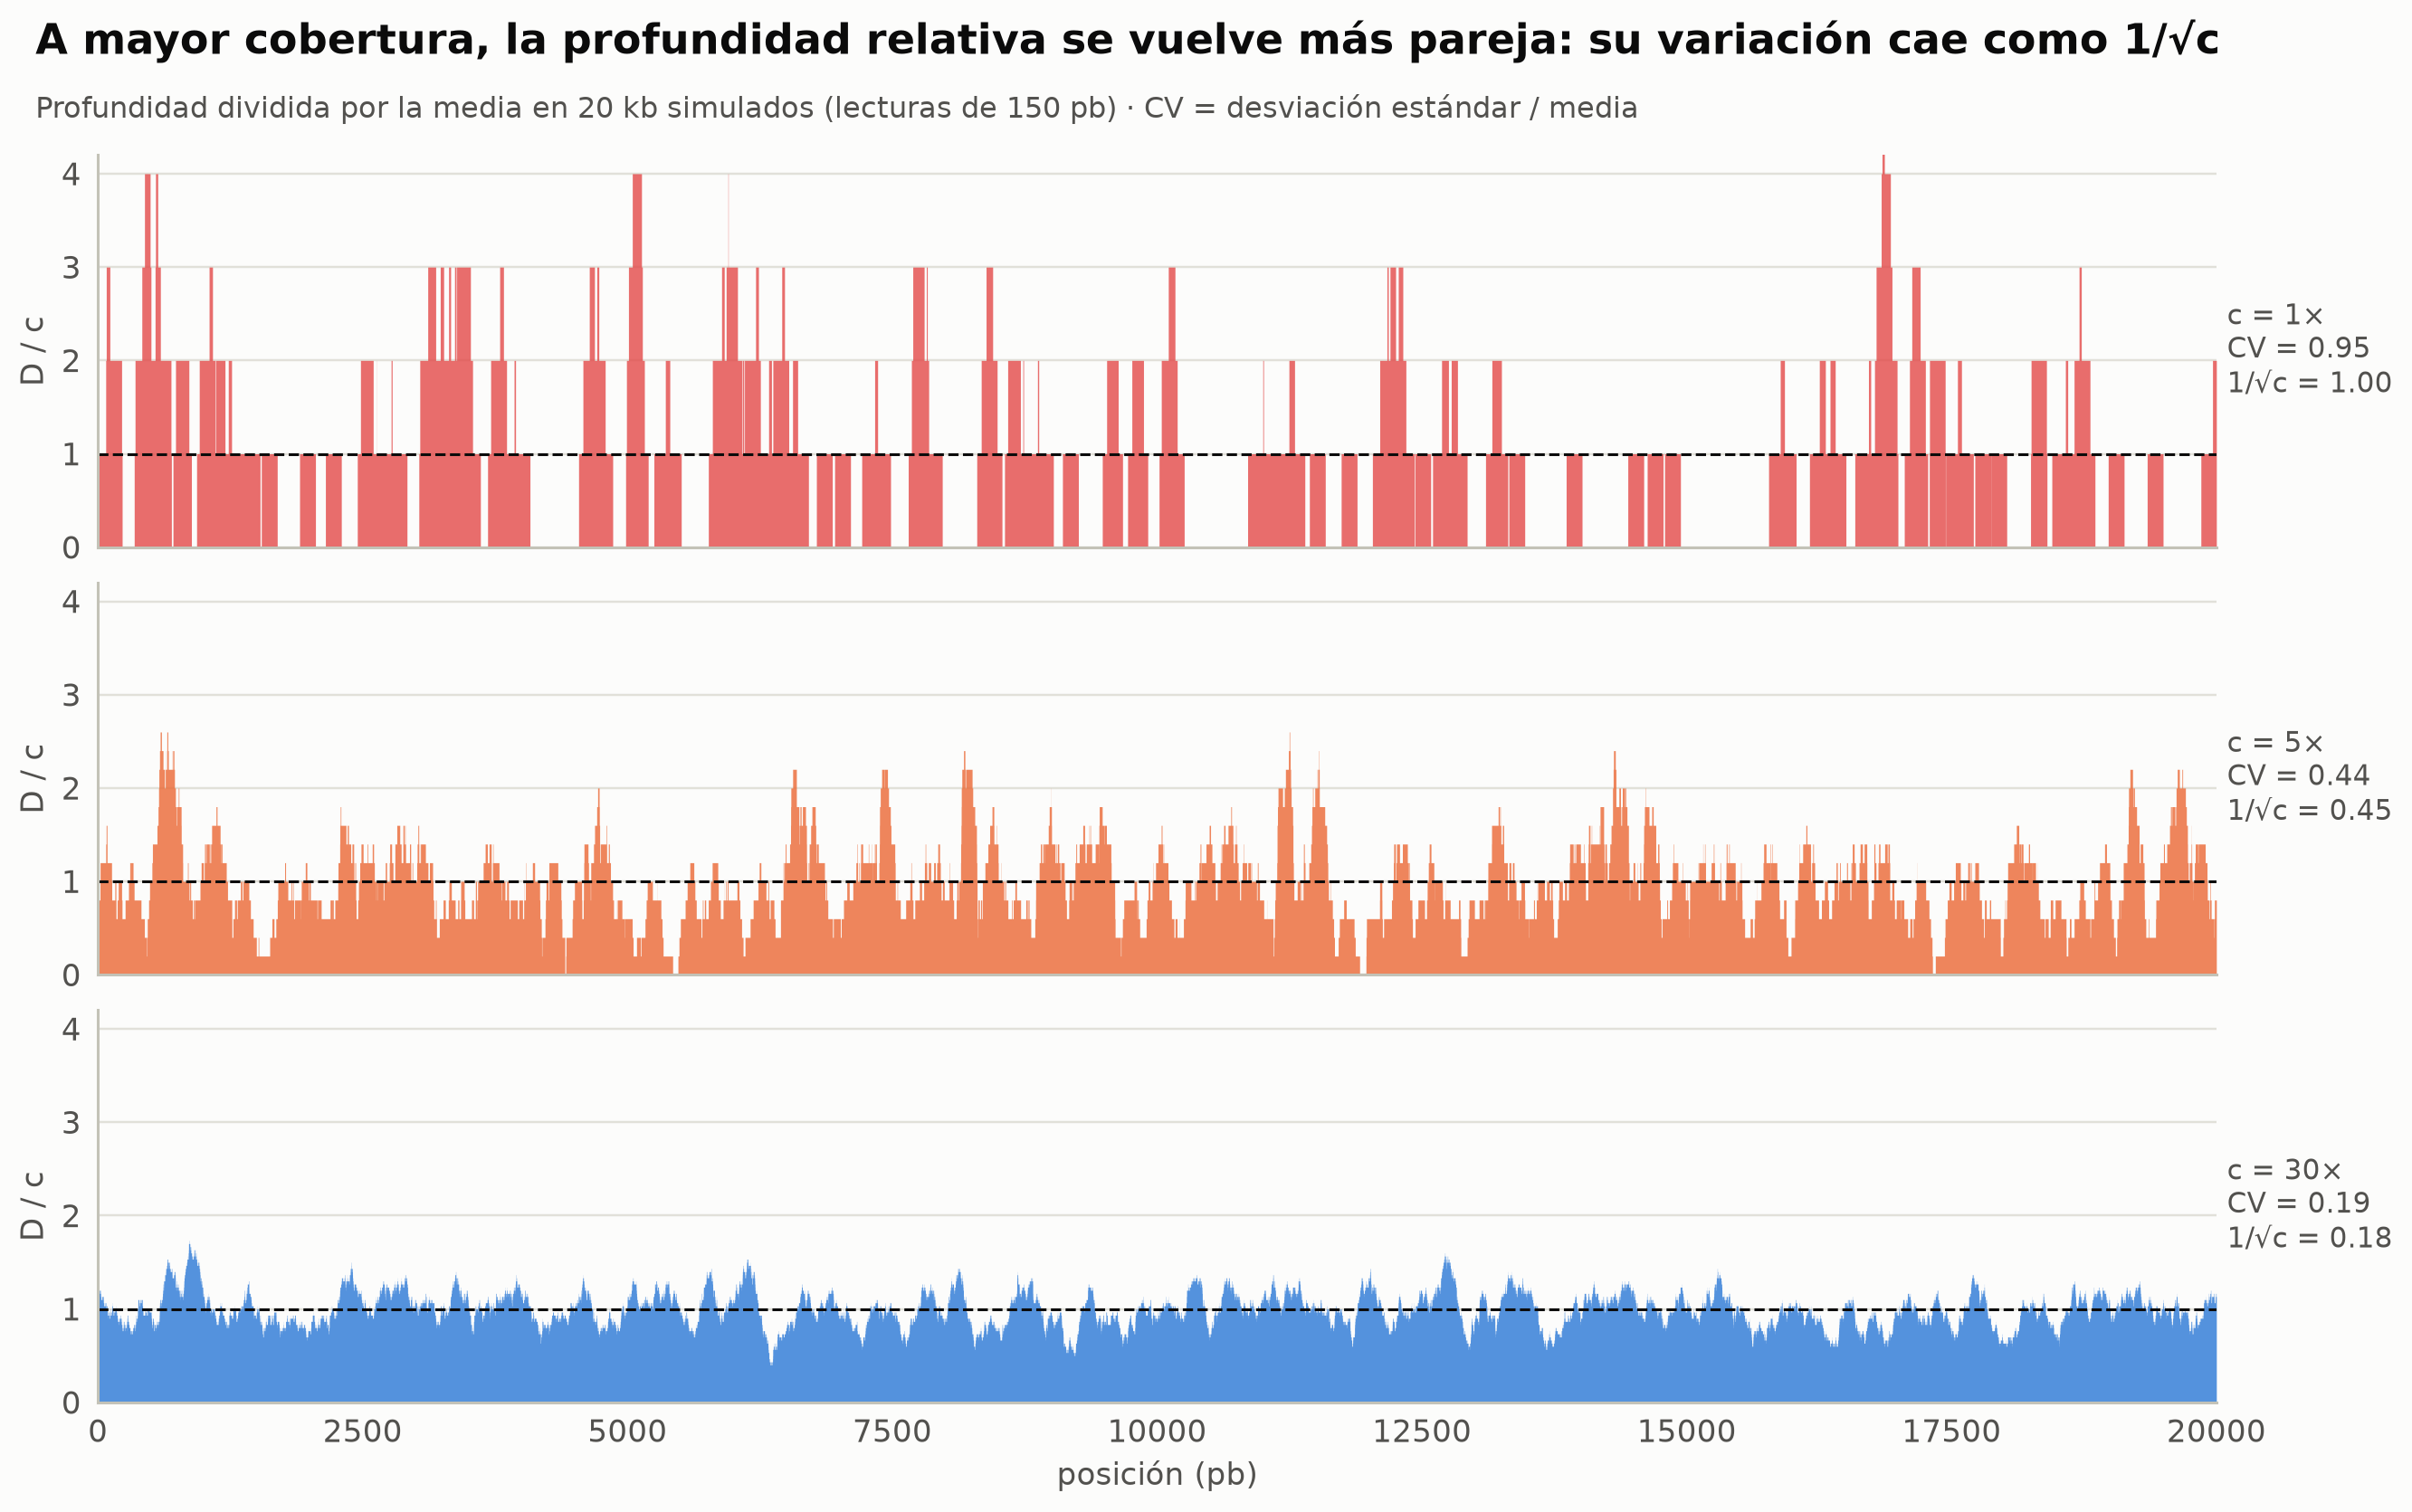

In [6]:
G_SEG, L_SEG = 20_000, 150
fig, axes = plt.subplots(3, 1, figsize=(12, 6.8), sharex=True)
for ax, c, col in zip(axes, [1, 5, 30], [ec.RED, ec.ORANGE, ec.BLUE]):
    d = depth_profile(simulate_starts(reads_needed(c, L_SEG, G_SEG), G_SEG, rng), L_SEG, G_SEG)
    ax.fill_between(np.arange(G_SEG), d / c, step="post", color=col, alpha=0.8, lw=0)
    ax.axhline(1, color=ec.INK, lw=1, ls="--")
    ax.set_ylim(0, 4.2); ax.set_xlim(0, G_SEG); ax.set_ylabel("D / c")
    cv = d.std() / d.mean()
    ax.text(1.005, 0.5, f"c = {c}×\nCV = {cv:.2f}\n1/√c = {1 / np.sqrt(c):.2f}", transform=ax.transAxes,
            fontsize=10, color=ec.INK_2, va="center")
axes[-1].set_xlabel("posición (pb)")
ec.fig_title(fig, "A mayor cobertura, la profundidad relativa se vuelve más pareja: su variación cae como 1/√c",
             "Profundidad dividida por la media en 20 kb simulados (lecturas de 150 pb) · CV = desviación estándar / media")
plt.show()

> 🔎 **Qué observamos.** A $1\times$ el perfil es un desierto con islas: muchas bases a 0 y otras a 3–4 veces la media.
> A $30\times$ el perfil oscila en torno a la media sin tocar el cero. El **coeficiente de variación** (CV) medido
> coincide con $1/\sqrt{c}$, una huella de la distribución de Poisson, cuya desviación estándar es $\sqrt{c}$.

## 3. La profundidad sigue una Poisson: bases sin cubrir $= e^{-c}$

### La intuición

Fije la mirada en **una posición** $x$ del genoma. Una lectura de longitud $L$ la cubre si empieza en alguna de las $L$
posiciones que van de $x - L + 1$ a $x$. Como el inicio se sortea entre $G$ posiciones, la probabilidad de que **una
lectura concreta** cubra la posición $x$ es $\pi = L/G$: un número diminuto (150 / 4.6 millones ≈ 0.00003). Pero hay
**muchísimas** lecturas, cada una con su pequeña oportunidad, y todas se sortean de forma independiente.

Contar cuántas de $N$ lecturas independientes "aciertan" con probabilidad $\pi$ es exactamente una **binomial**:

$$
D_x \sim \operatorname{Binomial}\!\left(N,\ \pi = \tfrac{L}{G}\right),
\qquad
\mathbb{E}[D_x] = N\,\frac{L}{G} = c
$$

Cuando $N$ es enorme y $\pi$ diminuta, con $N\pi = c$ fijo, la binomial se convierte en la distribución de **Poisson**
(la "ley de los sucesos raros", la misma que describe cuántas gotas de lluvia caen en una baldosa en un minuto):

$$
\boxed{\;P(D_x = k) \;=\; \frac{e^{-c}\,c^{k}}{k!}\;},
\qquad
\operatorname{Var}(D_x) = c,
\qquad
\operatorname{CV} = \frac{\sqrt{c}}{c} = \frac{1}{\sqrt{c}}
$$

El caso $k = 0$ es el más importante: la probabilidad de que una base **no sea leída nunca**.

$$
P(D_x = 0) = \left(1 - \tfrac{L}{G}\right)^{N} \;\approx\; e^{-NL/G} = e^{-c}
\qquad\Longrightarrow\qquad
\boxed{\;\text{fracción cubierta} = 1 - e^{-c}\;}
$$

| Símbolo | Significado |
|---|---|
| $\pi = L/G$ | probabilidad de que una lectura concreta cubra una base concreta |
| $D_x$ | profundidad en la posición $x$ (variable aleatoria) |
| $k$ | un valor posible de la profundidad: 0, 1, 2, … |
| $k!$ | factorial de $k$ ($3! = 6$; por convención $0! = 1$) |
| $e^{-c}$ | fracción esperada de bases **sin cubrir** |
| $G\,e^{-c}$ | número esperado de bases sin cubrir |

La fórmula $1 - e^{-c}$ es anterior a la secuenciación masiva: Clarke y Carbon (1976) la usaron para calcular
cuántos clones hacían falta en una genoteca para tener, con una probabilidad dada, cualquier gen de *E. coli*.

### Ejemplo a mano: $c = 3$

| $k$ | cálculo | $P(D = k)$ |
|---|---|---|
| 0 | $e^{-3}$ | 0.0498 |
| 1 | $e^{-3} \cdot 3$ | 0.1494 |
| 2 | $e^{-3} \cdot 9/2$ | 0.2240 |
| 3 | $e^{-3} \cdot 27/6$ | 0.2240 |
| 4 | $e^{-3} \cdot 81/24$ | 0.1680 |
| $\geq 1$ | $1 - e^{-3}$ | **0.9502** |

A $3\times$, el 5 % del genoma queda sin leer: en *E. coli*, unas $4.64\times10^6 \times 0.0498 \approx 231\,000$ bases.
A $10\times$, $e^{-10} = 4.5\times10^{-5}$: unas **211 bases**. A $30\times$, $e^{-30} \approx 9\times10^{-14}$: ni una sola
base en todo el genoma… en teoría.

Ahora la prueba de fuego a escala real: simulamos lecturas uniformes sobre un genoma del tamaño de *E. coli* a
$3\times$ y a $30\times$ y comparamos el histograma de profundidades con la Poisson.

c =  3: sin cubrir simulado = 0.04897   e^(−c) = 0.04979
c = 30: sin cubrir simulado = 0.00000   e^(−c) = 0.00000


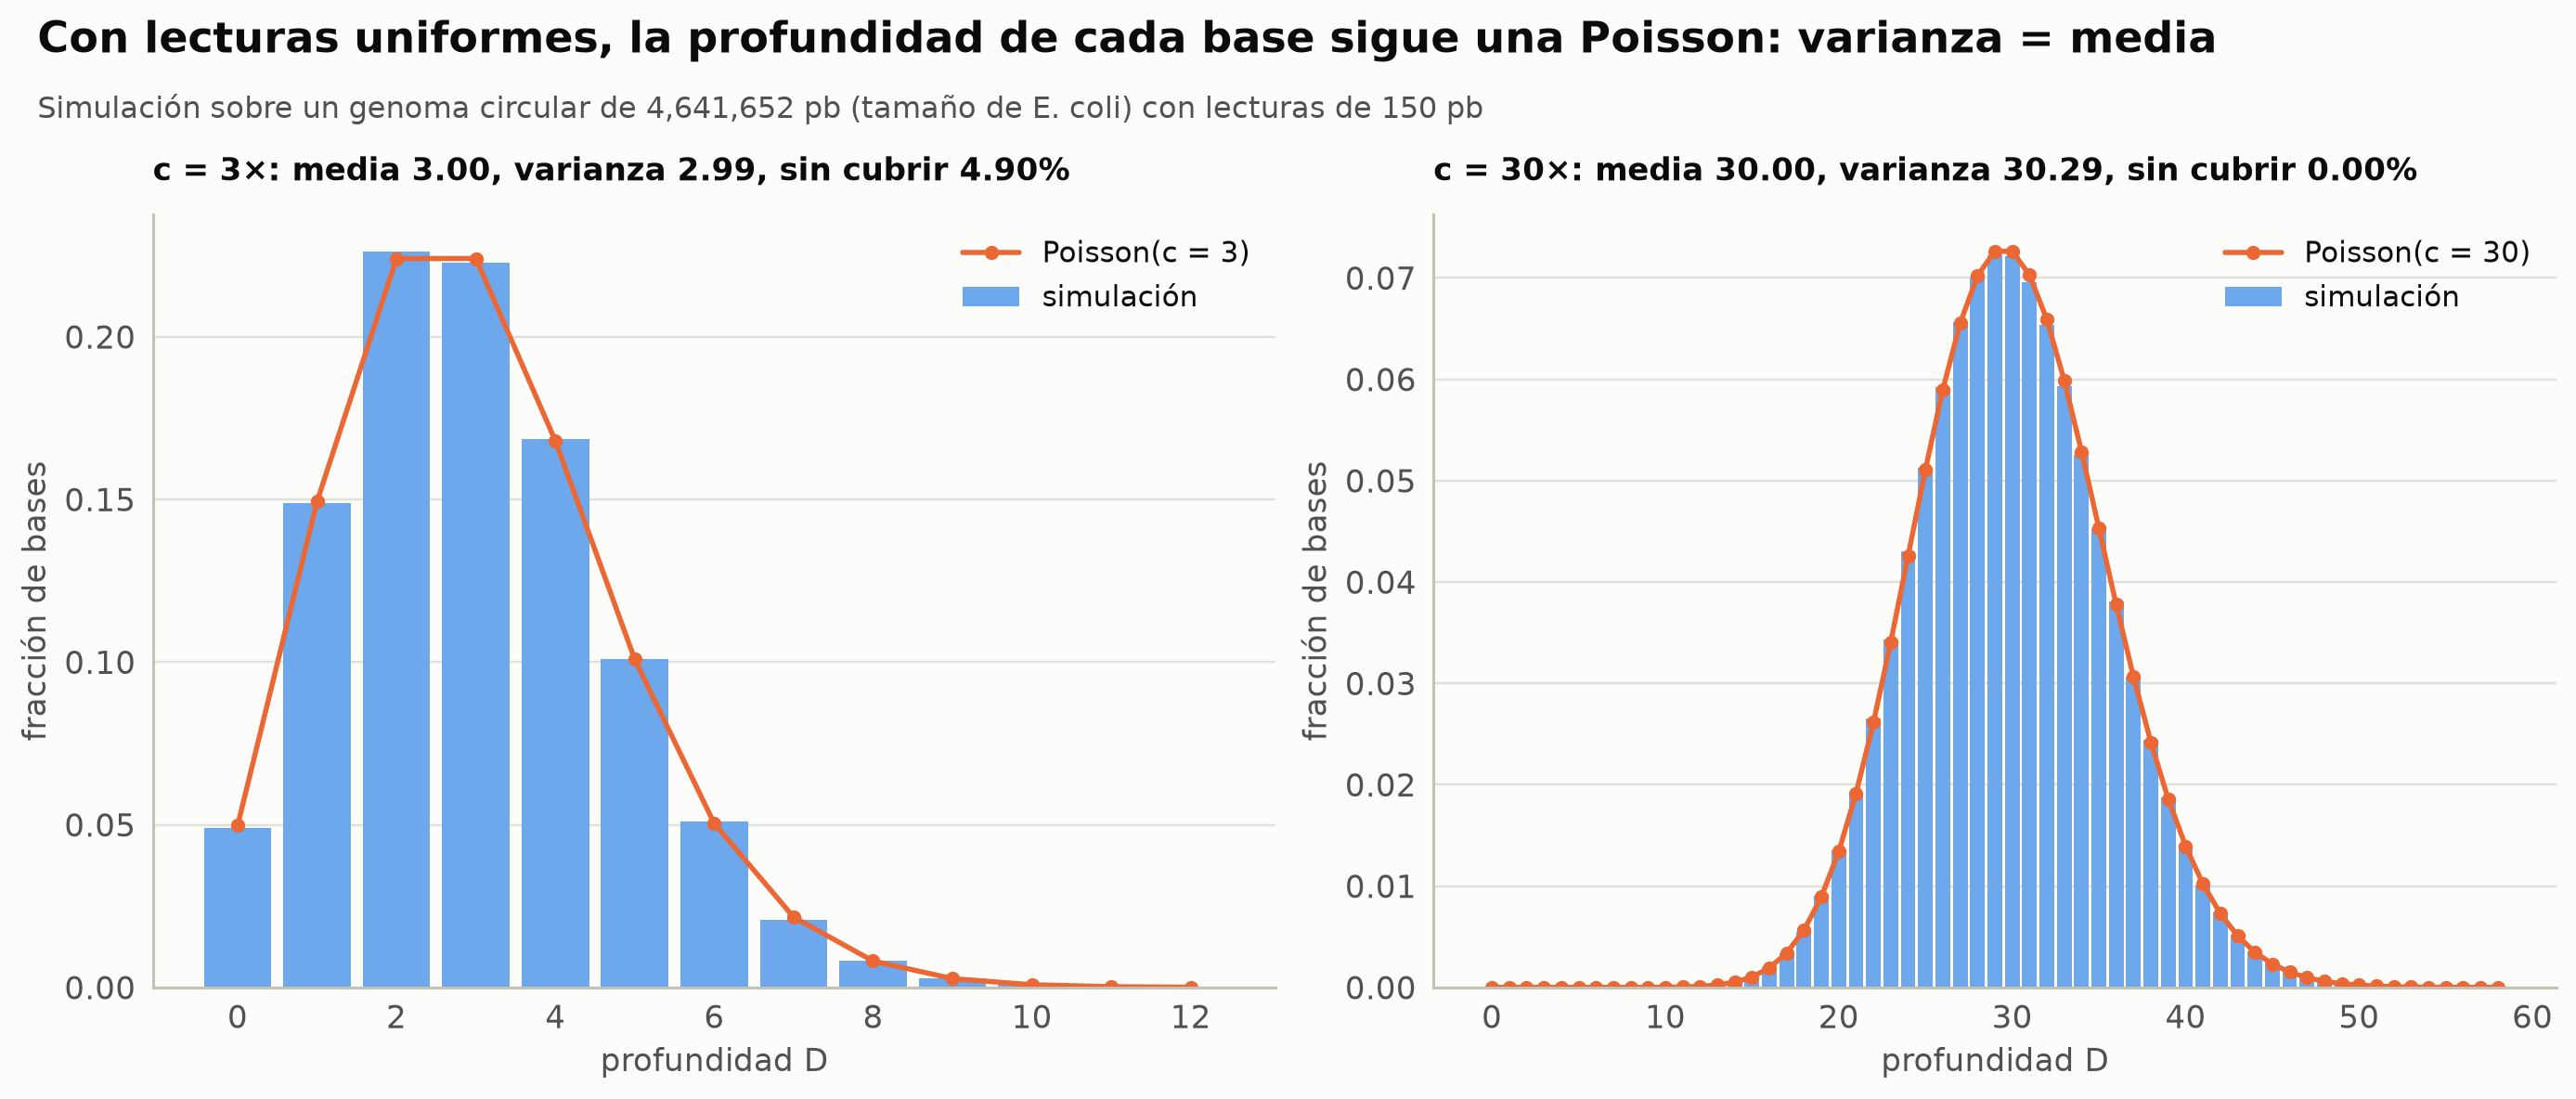

In [7]:
G_EC, L_RD = 4_641_652, 150
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
sim_uniform = {}
for ax, c in zip(axes, [3, 30]):
    d = depth_profile(simulate_starts(reads_needed(c, L_RD, G_EC), G_EC, rng), L_RD, G_EC)
    sim_uniform[c] = d
    k = np.arange(0, int(c + 5 * np.sqrt(c)) + 2)
    obs = np.bincount(d, minlength=k.max() + 1)[: k.max() + 1] / G_EC
    ax.bar(k, obs, width=0.85, color=ec.SEQ_BLUE[4], label="simulación")
    ax.plot(k, poisson.pmf(k, c), "o-", color=ec.ORANGE, ms=4, lw=1.8, label=f"Poisson(c = {c})")
    ax.set_xlabel("profundidad D"); ax.set_ylabel("fracción de bases")
    ax.set_title(f"c = {c}×: media {d.mean():.2f}, varianza {d.var():.2f}, sin cubrir {np.mean(d == 0):.2%}",
                 loc="left", fontsize=11)
    ax.legend(loc="upper right", frameon=False)
    print(f"c = {c:>2}: sin cubrir simulado = {np.mean(d == 0):.5f}   e^(−c) = {np.exp(-c):.5f}")
ec.fig_title(fig, "Con lecturas uniformes, la profundidad de cada base sigue una Poisson: varianza = media",
             f"Simulación sobre un genoma circular de {G_EC:,} pb (tamaño de E. coli) con lecturas de {L_RD} pb")
plt.show()

> 🔎 **Qué observamos.** Las barras (4.6 millones de bases simuladas) y los puntos de la Poisson prácticamente se
> superponen, y la **varianza es igual a la media**, la firma de la Poisson. La fracción sin cubrir a $3\times$
> coincide con $e^{-3} = 0.0498$. A $30\times$ ninguna base queda sin leer, y la gran mayoría tiene entre 20 y 40
> lecturas. Guarde este histograma en la memoria: en la sección 7 lo compararemos con lo que ocurre de verdad.

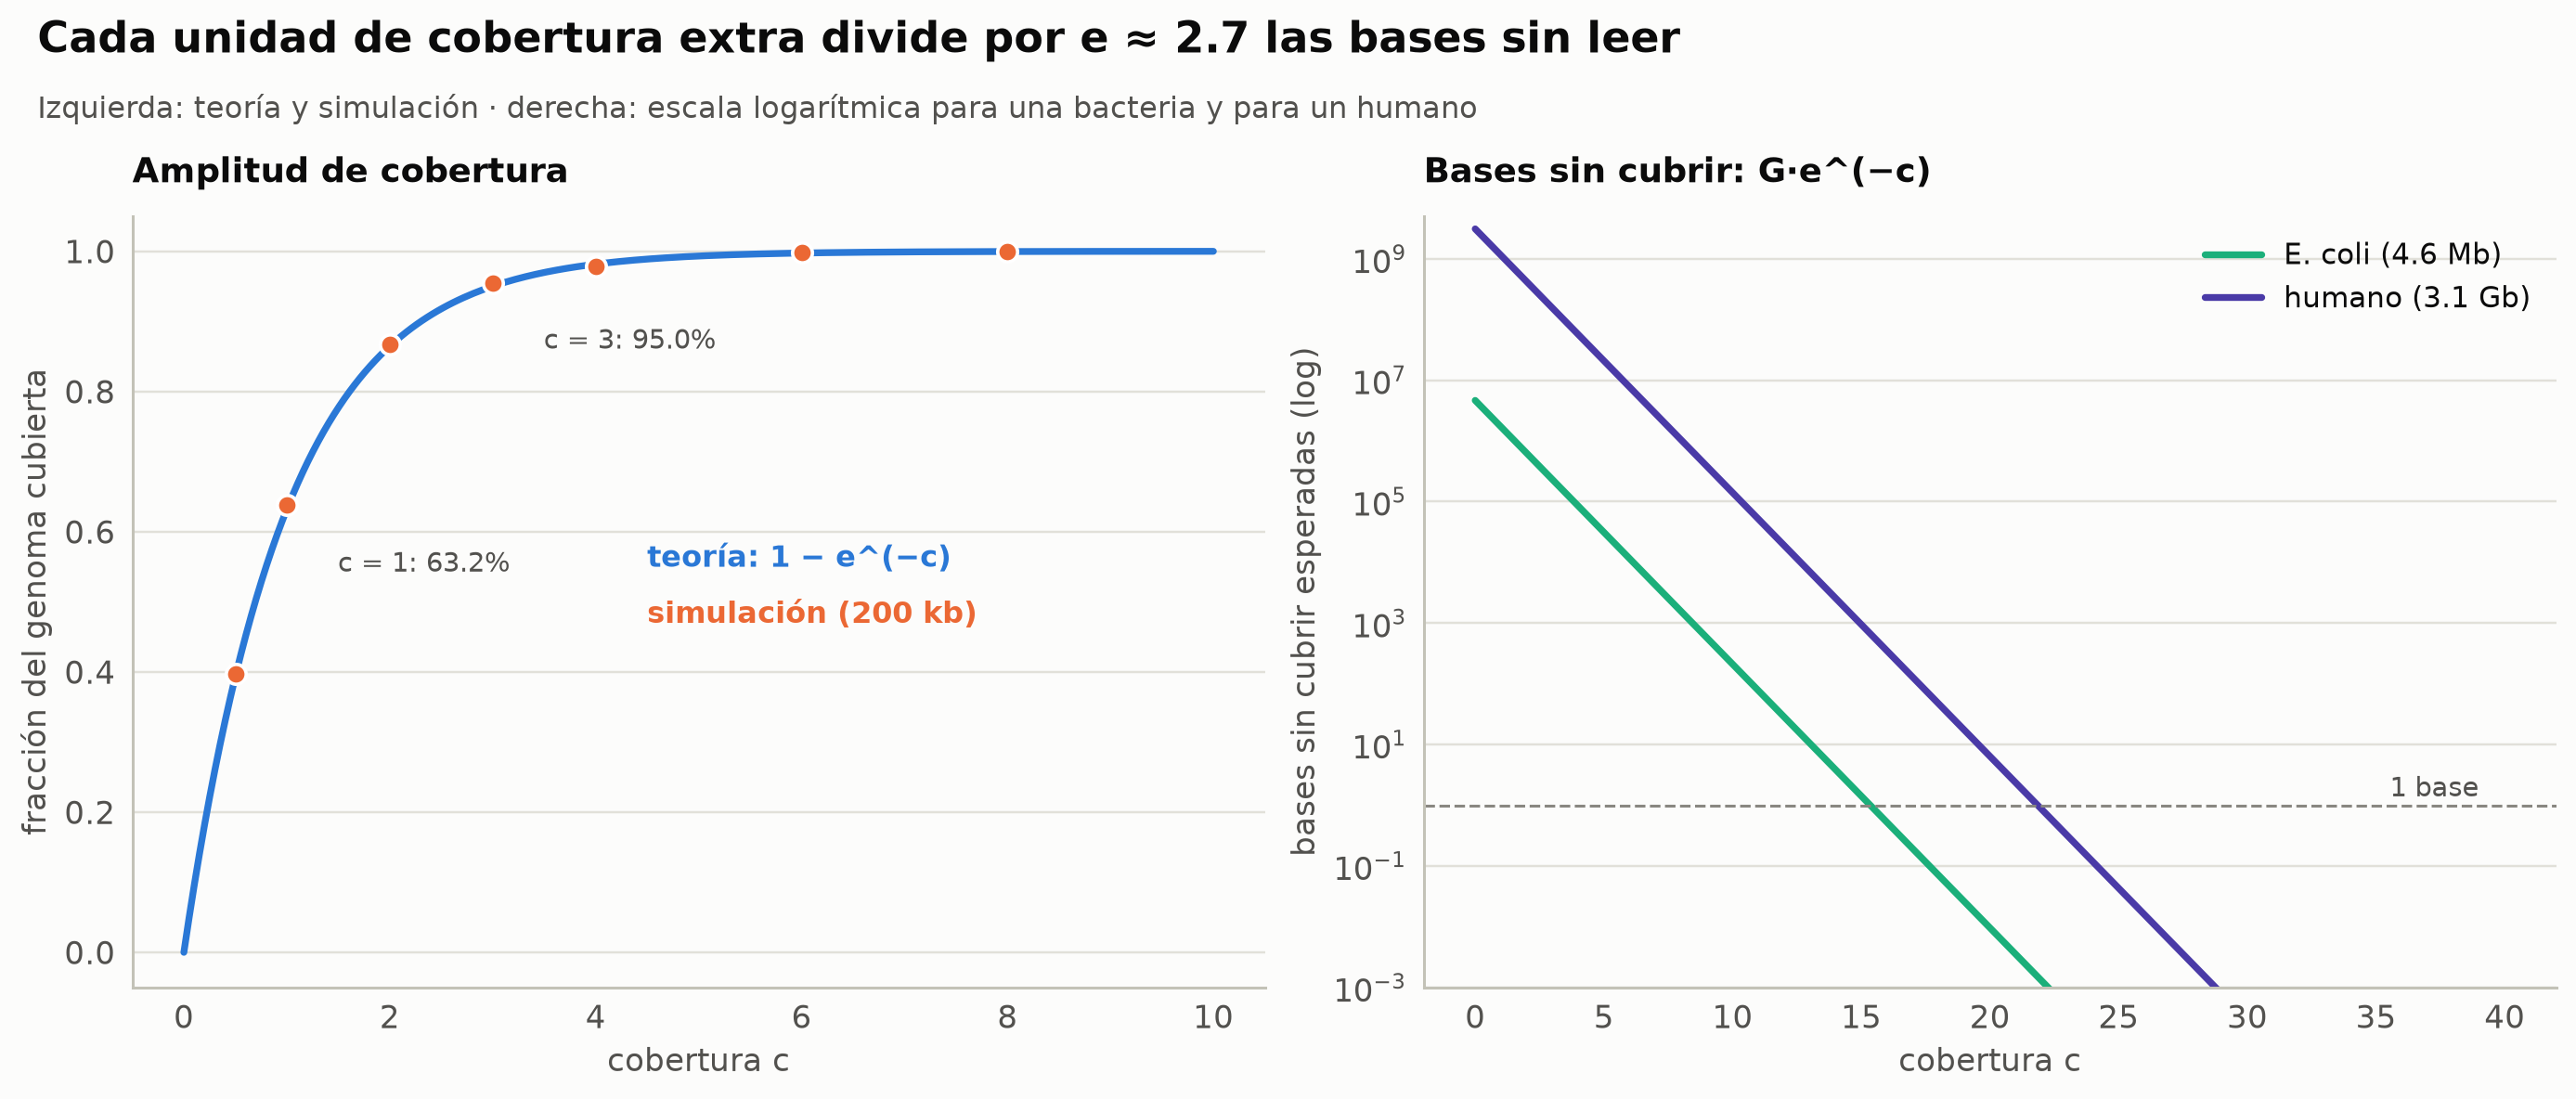

In [8]:
c_grid = np.linspace(0, 10, 200)
c_pts = [0.5, 1, 2, 3, 4, 6, 8]
frac_sim = [np.mean(depth_profile(simulate_starts(reads_needed(c, 150, 200_000), 200_000, rng), 150, 200_000) > 0)
            for c in c_pts]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].plot(c_grid, 1 - np.exp(-c_grid), color=ec.BLUE, lw=2.4)
axes[0].plot(c_pts, frac_sim, "o", color=ec.ORANGE, ms=7, mec="white", mew=1.2)
axes[0].text(4.5, 0.55, "teoría: 1 − e^(−c)", color=ec.BLUE, fontsize=10.5, fontweight="bold")
axes[0].text(4.5, 0.47, "simulación (200 kb)", color=ec.ORANGE, fontsize=10.5, fontweight="bold")
for c in (1, 3):
    axes[0].annotate(f"c = {c}: {1 - np.exp(-c):.1%}", (c, 1 - np.exp(-c)), xytext=(18, -22),
                     textcoords="offset points", fontsize=9.5, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
axes[0].set_xlabel("cobertura c"); axes[0].set_ylabel("fracción del genoma cubierta")
axes[0].set_title("Amplitud de cobertura", loc="left", fontsize=12)
c_log = np.linspace(0, 40, 300)
for G_, name, col in [(4.64e6, "E. coli (4.6 Mb)", ec.AQUA), (3.1e9, "humano (3.1 Gb)", ec.VIOLET)]:
    axes[1].semilogy(c_log, G_ * np.exp(-c_log), color=col, lw=2.4, label=name)
axes[1].legend(frameon=False, loc="upper right")
axes[1].axhline(1, color=ec.MUTED, lw=1, ls="--")
axes[1].text(39, 1.4, "1 base", ha="right", fontsize=9.5, color=ec.INK_2)
axes[1].set_ylim(1e-3, 5e9); axes[1].set_xlabel("cobertura c"); axes[1].set_ylabel("bases sin cubrir esperadas (log)")
axes[1].set_title("Bases sin cubrir: G·e^(−c)", loc="left", fontsize=12)
ec.fig_title(fig, "Cada unidad de cobertura extra divide por e ≈ 2.7 las bases sin leer",
             "Izquierda: teoría y simulación · derecha: escala logarítmica para una bacteria y para un humano")
plt.show()

> 🔎 **Qué observamos.** La curva de la izquierda crece rápido y luego se aplana: pasar de 0 a $3\times$ cubre el 95 %
> del genoma, pero cada 9 del 99.9…% siguiente exige más lecturas. A la derecha, en escala logarítmica, $G e^{-c}$ es
> una **recta**: cada $1\times$ adicional divide las bases faltantes entre $e$. Según la teoría pura, un humano quedaría
> completamente leído hacia $c \approx 22\times$. En la práctica, a $30\times$ siguen faltando millones de bases:
> regiones con GC extremo, repeticiones y zonas difíciles de mapear. La teoría es el **mejor caso posible**.

✅ **Compruebe su comprensión.** ¿Qué cobertura necesita para que la fracción sin cubrir sea menor que 1 en un
millón? (Respuesta: $e^{-c} < 10^{-6} \Rightarrow c > 6 \ln 10 \approx 13.8\times$.)

## 4. La teoría de Lander-Waterman: contigs y huecos

Saber que el 99.99 % de las bases está cubierto no basta para **ensamblar** un genoma. Un ensamblador une lecturas que
se **solapan**; si entre dos lecturas vecinas no hay solapamiento suficiente, la cadena se corta y tenemos dos
**contigs** separados por un **hueco** (*gap*). En 1988, Eric Lander y Michael Waterman respondieron a la pregunta
"¿cuántos contigs esperamos y de qué tamaño?" con un argumento de una elegancia notable. (Lo formularon para el mapeo
de clones, pero se aplica igual a las lecturas.)

### Paso 1: el solapamiento mínimo

En la práctica, dos lecturas sólo se reconocen como vecinas si comparten al menos $T$ bases (un solapamiento de 3
bases podría ser casualidad). Definimos:

$$
\theta = \frac{T}{L}, \qquad \sigma = 1 - \theta
$$

$\theta$ es la fracción de la lectura que debe solaparse. Dos lecturas consecutivas quedan **unidas** si la segunda
empieza a menos de $\sigma L = L - T$ bases de la primera.

### Paso 2: la distancia entre inicios consecutivos

Recorra el genoma de izquierda a derecha y anote dónde empieza cada lectura. Los inicios caen al azar con una densidad
de $\rho = N/G$ inicios por base, y los inicios de un proceso así (un **proceso de Poisson**) tienen una propiedad
clave: la distancia desde un inicio hasta el siguiente sigue una distribución **exponencial**,

$$
P(\text{distancia} > x) = e^{-\rho x} .
$$

Es la misma lógica de la sección anterior: que el siguiente inicio esté a más de $x$ bases equivale a que en esas $x$
posiciones no haya caído **ningún** inicio, y la probabilidad de "ningún suceso" en una Poisson de media $\rho x$ es
$e^{-\rho x}$.

### Paso 3: ¿cuándo termina un contig?

Una lectura es la **última de su contig** si la siguiente empieza a más de $\sigma L$ bases:

$$
P(\text{la lectura cierra un contig}) = e^{-\rho\,\sigma L} = e^{-\frac{N}{G} \sigma L} = e^{-c\sigma}
$$

Cada contig tiene exactamente una lectura que lo cierra. Así que, sumando sobre las $N$ lecturas:

$$
\boxed{\;\mathbb{E}[\text{contigs}] \;=\; N\,e^{-c\sigma} \;=\; N\,e^{-c(1-\theta)}\;}
$$

### Paso 4: lecturas y longitud de un contig

Cada lectura "pasa el testigo" a la siguiente con probabilidad $1 - e^{-c\sigma}$; el número de lecturas de un contig
es una variable **geométrica** con media

$$
\mathbb{E}[\text{lecturas por contig}] = \frac{1}{e^{-c\sigma}} = e^{c\sigma} .
$$

La longitud del contig es la primera lectura ($L$) más los pasos entre inicios consecutivos (cada uno menor que
$\sigma L$). Promediando esos pasos con la exponencial truncada, Lander y Waterman obtuvieron:

$$
\boxed{\;\mathbb{E}[\text{longitud del contig}] \;=\; L\left[\frac{e^{c\sigma} - 1}{c} + (1 - \sigma)\right]\;}
$$

### Paso 5: los huecos

Con $\theta = 0$ ($\sigma = 1$) en un genoma circular, cada contig va seguido de un hueco **real** (bases sin leer), así
que hay $N e^{-c}$ huecos. Su longitud media es la distancia media sobrante entre inicios, $1/\rho = G/N = L/c$.
Comprobemos que todo encaja:

$$
\underbrace{N e^{-c}}_{\text{huecos}} \times \underbrace{\frac{L}{c}}_{\text{longitud media}}
= \frac{NL}{c}\,e^{-c} = G\,e^{-c} \quad ✔
$$

¡Es el número de bases sin cubrir de la sección 3! Con $\theta > 0$ aparecen además **huecos aparentes**: lecturas
que sí se tocan, pero con un solapamiento demasiado corto para detectarlo. La fórmula $N e^{-c(1-\theta)}$ cuenta ambos.

| Símbolo | Significado |
|---|---|
| $T$ | solapamiento mínimo detectable entre dos lecturas (pb) |
| $\theta = T/L$ | fracción de solapamiento exigida |
| $\sigma = 1 - \theta$ | fracción "libre": la siguiente lectura debe empezar a menos de $\sigma L$ bases |
| $\rho = N/G$ | densidad de inicios de lectura por base |
| $N e^{-c\sigma}$ | número esperado de contigs (islas) |
| $e^{c\sigma}$ | número esperado de lecturas por contig |
| $L/c$ | longitud media de un hueco real ($\theta = 0$) |

### Ejemplo a mano: *E. coli* a $8\times$ con lecturas de 150 pb

* $N = cG/L = 8 \times 4\,641\,652 / 150 = 247\,555$ lecturas.
* Con $\theta = 0$: contigs $= 247\,555 \times e^{-8} = 247\,555 \times 0.000335 \approx \mathbf{83}$.
* Lecturas por contig: $e^{8} \approx 2\,981$. Longitud media: $150 \times (2\,980 / 8 + 0) \approx \mathbf{55.9}$ **kb**.
  Y $83 \times 55.9$ kb $\approx 4.64$ Mb: los contigs cubren el genoma ✔.
* Huecos: 83, de $L/c = 18.75$ pb de media: $83 \times 18.75 \approx 1\,560$ bases sin leer $= G e^{-8}$ ✔.
* Con $T = 30$ ($\theta = 0.2$): contigs $= 247\,555 \times e^{-6.4} \approx \mathbf{411}$. ¡Exigir 30 bases de
  solapamiento multiplica por cinco los contigs!

### Una sorpresa: el número de contigs sube y luego baja

Escribiendo $N = cG/L$, los contigs esperados son $\frac{G}{L}\,c\,e^{-c\sigma}$. Con pocas lecturas hay pocos
contigs (pocas islas sueltas); con muchas, todas se funden. En medio hay un máximo: derivando e igualando a cero,
$c^\ast = 1/\sigma$, con $\frac{G}{L\sigma e}$ contigs. Para *E. coli* con $\theta = 0$: a $1\times$, unos 11 400 contigs.

In [9]:
def lw_contigs(c, L, G, theta=0.0):
    """Número esperado de contigs (islas) de Lander-Waterman: N·e^(−c(1−θ))."""
    return c * G / L * np.exp(-c * (1 - theta))

def lw_contig_length(c, L, theta=0.0):
    """Longitud esperada de un contig (pb): L·[(e^(cσ) − 1)/c + (1 − σ)]."""
    s = 1 - theta
    return L * (np.expm1(c * s) / c + (1 - s))

def count_contigs(starts, L, G, theta=0.0):
    """Cuenta contigs en un genoma circular: se corta donde dos inicios consecutivos distan más de (1−θ)·L.
    Devuelve (número de contigs, longitudes de contig en pb)."""
    s = np.sort(starts)
    step = np.diff(np.r_[s, s[0] + G])            # distancia al siguiente inicio (dando la vuelta)
    cut = np.flatnonzero(step > (1 - theta) * L)  # lecturas que cierran un contig
    if len(cut) == 0:
        return 1, np.array([G])
    first = np.r_[cut[-1] + 1 - len(s), cut[:-1] + 1] % len(s)   # primera lectura de cada contig
    length = (s[cut] - s[first]) % G + L
    return len(cut), length

G_E = 4_641_652
N8 = reads_needed(8, 150, G_E)
print(f"N = {N8:,.0f} lecturas · contigs (θ=0) = {lw_contigs(8, 150, G_E):.1f} · (θ=0.2) = {lw_contigs(8, 150, G_E, 0.2):.1f}")
print(f"longitud media de contig (θ=0) = {lw_contig_length(8, 150):,.0f} pb")
n_sim, len_sim = count_contigs(simulate_starts(N8, G_E, rng), 150, G_E)
print(f"Una simulación del genoma completo: {n_sim} contigs, longitud media {len_sim.mean():,.0f} pb")

N = 247,555 lecturas · contigs (θ=0) = 83.0 · (θ=0.2) = 411.3
longitud media de contig (θ=0) = 55,874 pb
Una simulación del genoma completo: 76 contigs, longitud media 61,052 pb


### Planificar el ensamblaje de una bacteria (el ejemplo del libro)

Un hospital detecta un brote de *Klebsiella* y quiere ensamblar el genoma de uno de los aislados, de unos
$G = 5\times10^6$ pb, con lecturas de $L = 150$ pb. El ensamblador necesita al menos $T = 30$ pb de solapamiento, así
que $\theta = 0.2$ y $\sigma = 0.8$. ¿Qué cabe esperar a $1\times$, $5\times$ y $10\times$? Con $c = 5$, por ejemplo:
$N = 5 \times 5\times10^6/150 \approx 166\,667$ lecturas, bases sin cubrir $G e^{-5} \approx 33\,690$, y contigs
$N e^{-5 \times 0.8} = 166\,667 \times e^{-4} \approx 3\,053$. La celda completa la tabla (son las mismas cifras de la
tabla del ejemplo del libro, capítulo 6):

In [10]:
G_B, L_B, T_B = 5e6, 150, 30
theta_B = T_B / L_B                                  # σ = 1 − θ = 0.8
book_table = pd.DataFrame([{
    "c": c,
    "N (lecturas)": reads_needed(c, L_B, G_B),
    "bases sin cubrir G·e^(−c)": G_B * np.exp(-c),
    "contigs N·e^(−cσ)": lw_contigs(c, L_B, G_B, theta_B),
    "longitud media de contig (pb)": lw_contig_length(c, L_B, theta_B)} for c in (1, 5, 10)])
print(f"A 30×: contigs adicionales esperados N·e^(−24) = {lw_contigs(30, L_B, G_B, theta_B):.1e} → un único contig")
book_table.style.format({"N (lecturas)": "{:,.0f}", "bases sin cubrir G·e^(−c)": "{:,.0f}",
                         "contigs N·e^(−cσ)": "{:,.0f}", "longitud media de contig (pb)": "{:,.0f}"}).hide(axis="index")

A 30×: contigs adicionales esperados N·e^(−24) = 3.8e-05 → un único contig


c,N (lecturas),bases sin cubrir G·e^(−c),contigs N·e^(−cσ),longitud media de contig (pb)
1,"33,333","1,839,397","14,978",214
5,"166,667","33,690","3,053","1,638"
10,"333,333",227,112,"44,729"


> 🔎 **Qué observamos.** A $5\times$ tendríamos más de tres mil fragmentos; a $10\times$, alrededor de un centenar
> (de ~44.7 kb de media), y a $30\times$ la teoría predice $N e^{-24} \approx 4\times10^{-5}$ contigs **adicionales**: un
> único contig. Sin embargo, los ensamblajes reales de lecturas cortas a $30$–$50\times$ terminan en decenas o cientos
> de contigs. El modelo ignora dos cosas que veremos enseguida: las **repeticiones** (sección 6) y el **sesgo de
> cobertura** (sección 7).

> 🤔 **Antes de ejecutar, prediga:** si simulamos muchas veces un genoma de 300 kb con lecturas de 150 pb, ¿en qué
> cobertura cree que habrá **más** contigs cuando exigimos $\theta = 0.2$: en $1\times$, en $1.25\times$ o en $2\times$?

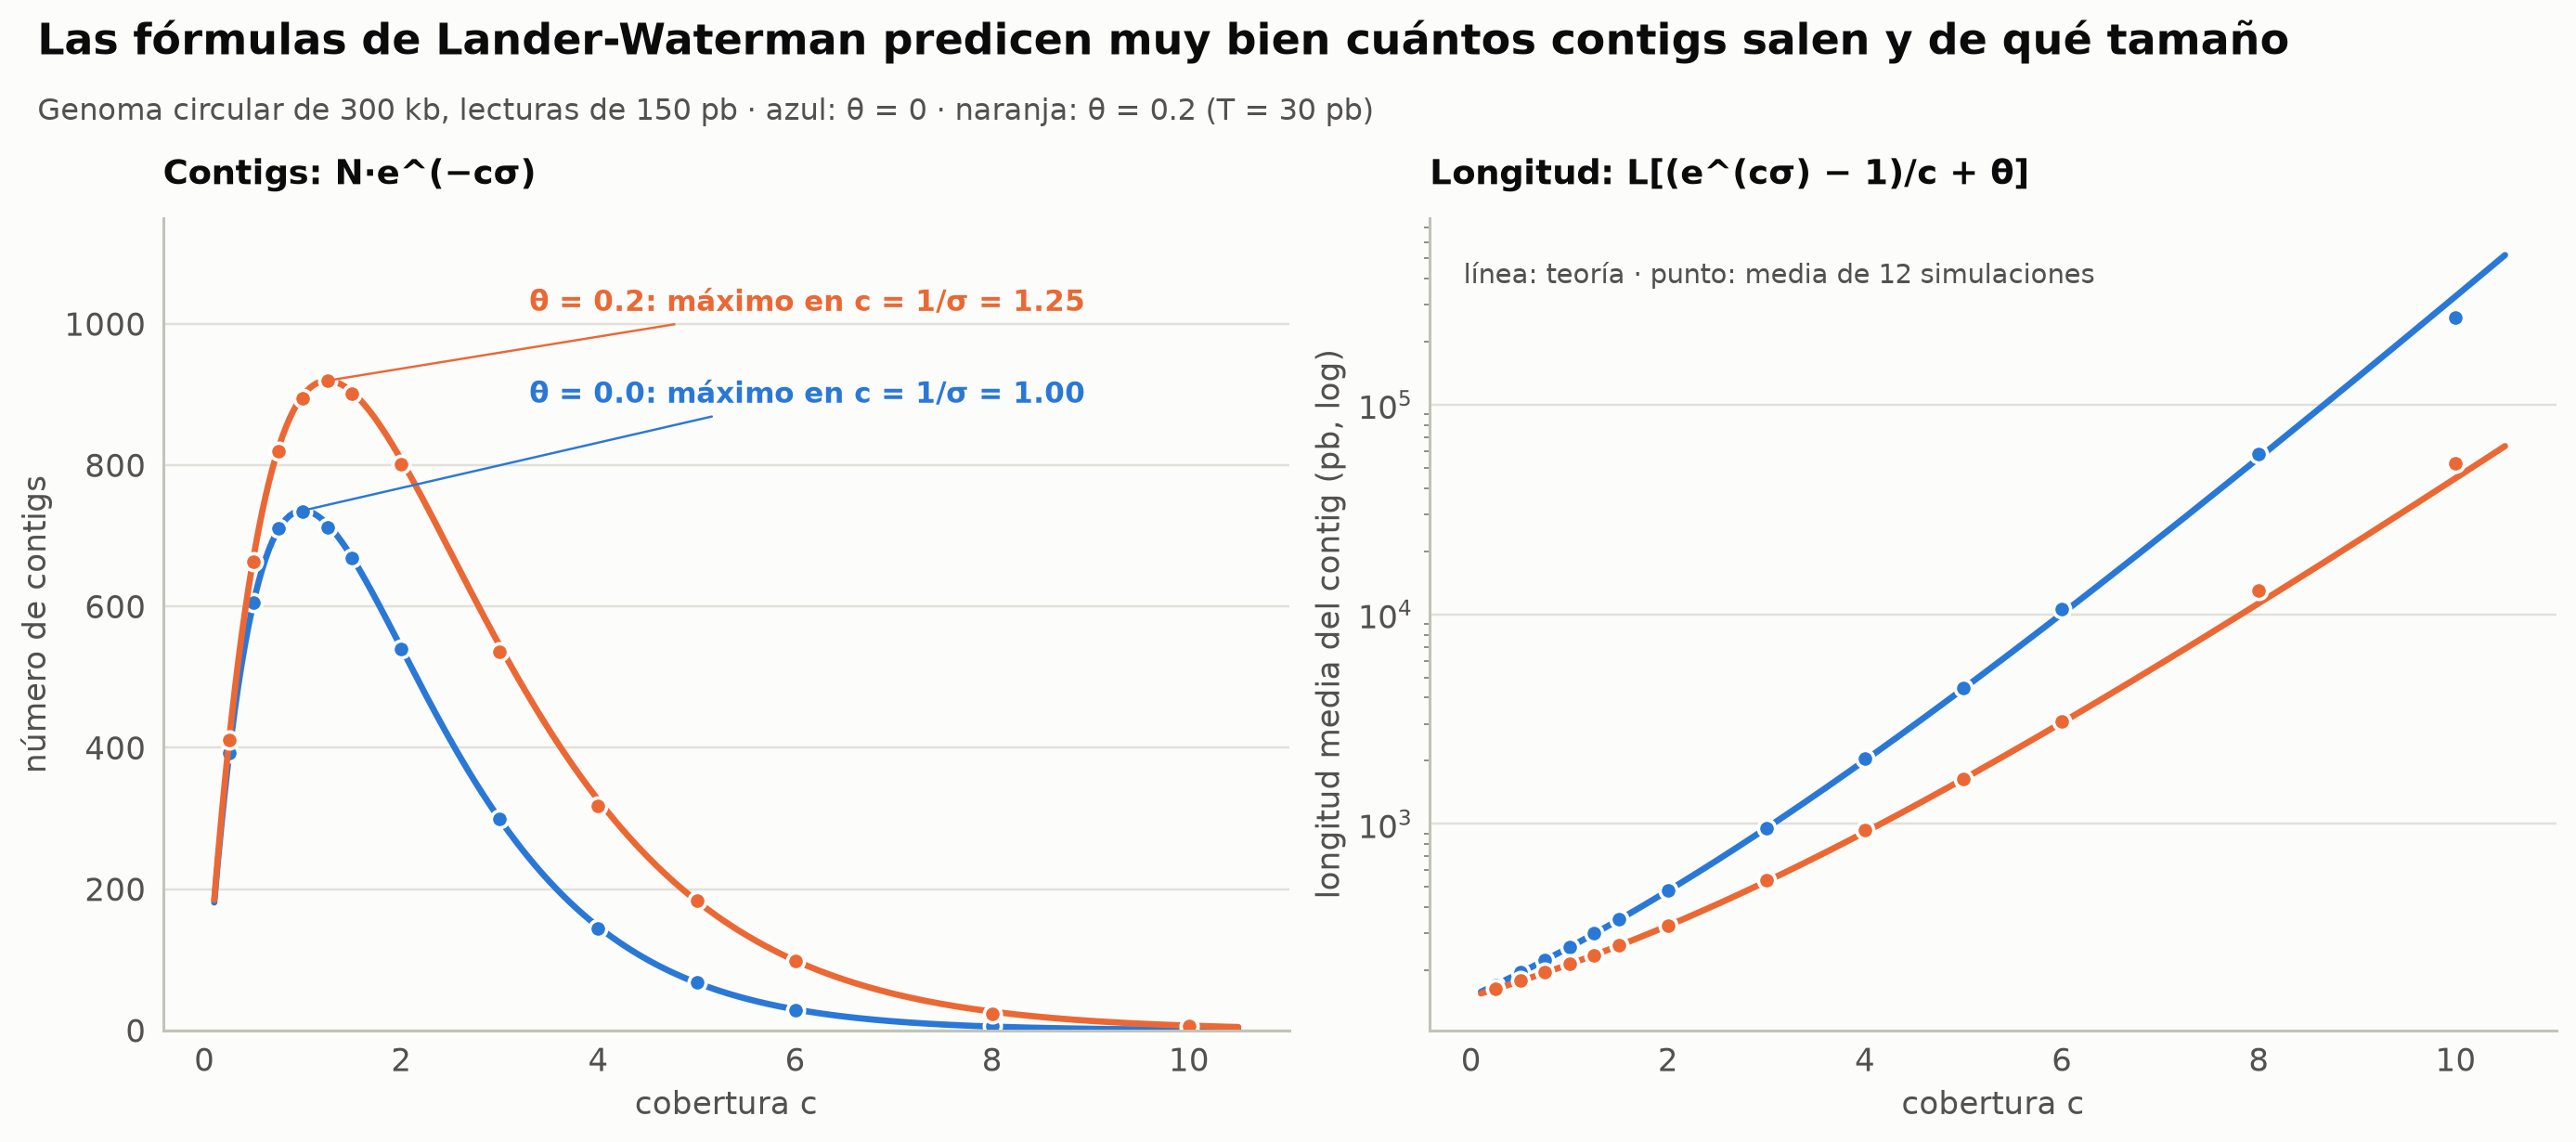

In [11]:
G_V, L_V, REPS = 300_000, 150, 12
c_check = np.array([0.25, 0.5, 0.75, 1, 1.25, 1.5, 2, 3, 4, 5, 6, 8, 10])
rows = []
for theta in (0.0, 0.2):
    for c in c_check:
        for rep in range(REPS):
            n_c, lens = count_contigs(simulate_starts(reads_needed(c, L_V, G_V), G_V, rng), L_V, G_V, theta)
            rows.append(dict(theta=theta, c=c, contigs=n_c, mean_len=lens.mean()))
lw_sim = pd.DataFrame(rows).groupby(["theta", "c"]).mean().reset_index()

c_fine = np.linspace(0.1, 10.5, 300)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for theta, col in [(0.0, ec.BLUE), (0.2, ec.ORANGE)]:
    sub = lw_sim[lw_sim.theta == theta]
    axes[0].plot(c_fine, lw_contigs(c_fine, L_V, G_V, theta), color=col, lw=2.2)
    axes[0].plot(sub.c, sub.contigs, "o", color=col, ms=6, mec="white", mew=1.2)
    axes[1].semilogy(c_fine, lw_contig_length(c_fine, L_V, theta), color=col, lw=2.2)
    axes[1].semilogy(sub.c, sub.mean_len, "o", color=col, ms=6, mec="white", mew=1.2)
    peak = 1 / (1 - theta)
    axes[0].annotate(f"θ = {theta}: máximo en c = 1/σ = {peak:.2f}", (peak, lw_contigs(peak, L_V, G_V, theta)),
                     xytext=(3.3, 1030 if theta else 900), textcoords="data", fontsize=10, color=col,
                     fontweight="bold", va="center", arrowprops=dict(arrowstyle="-", color=col, lw=0.8))
axes[0].set_xlabel("cobertura c"); axes[0].set_ylabel("número de contigs")
axes[0].set_title("Contigs: N·e^(−cσ)", loc="left", fontsize=12)
axes[0].set_ylim(0, lw_contigs(1.25, L_V, G_V, 0.2) * 1.25)
axes[1].set_xlabel("cobertura c"); axes[1].set_ylabel("longitud media del contig (pb, log)")
axes[1].set_title("Longitud: L[(e^(cσ) − 1)/c + θ]", loc="left", fontsize=12)
axes[1].text(0.03, 0.92, "línea: teoría · punto: media de 12 simulaciones", transform=axes[1].transAxes,
             fontsize=9.5, color=ec.INK_2)
ec.fig_title(fig, "Las fórmulas de Lander-Waterman predicen muy bien cuántos contigs salen y de qué tamaño",
             f"Genoma circular de {G_V // 1000} kb, lecturas de {L_V} pb · azul: θ = 0 · naranja: θ = 0.2 (T = 30 pb)")
plt.show()

> 🔎 **Qué observamos.** Los puntos simulados caen sobre las curvas teóricas en todo el rango. El número de contigs
> **sube** hasta $c = 1/\sigma$ (1 para $\theta = 0$; 1.25 para $\theta = 0.2$) y después **cae exponencialmente**. La
> longitud de los contigs crece de forma exponencial con $c$: a $10\times$ y $\theta = 0$ ya son de ~150 kb, la mitad
> del genoma simulado. Exigir solapamiento ($\theta = 0.2$) equivale a "perder" un 20 % de la cobertura: la curva
> naranja es la azul evaluada en $0.8\,c$.

![Al aumentar la cobertura, las islas de lecturas crecen y se funden: el número de contigs sube hasta c = 1 y luego cae, siguiendo la curva de Lander-Waterman](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-06-ngs/6.3_contigs_fusionan.gif)

*Al aumentar la cobertura, las islas de lecturas crecen y se funden: el número de contigs sube hasta c = 1 y luego cae, siguiendo la curva de Lander-Waterman*

In [12]:
G_A, L_A = 100_000, 1_000
c_frames = np.r_[np.linspace(0.05, 1, 16), np.linspace(1.1, 8, 34)]
N_max = int(reads_needed(c_frames[-1], L_A, G_A))
starts_all = simulate_starts(N_max, G_A, rng)           # las primeras n lecturas son la muestra de cada cuadro

fig = plt.figure(figsize=(12, 6.4))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
gs = fig.add_gridspec(2, 1, height_ratios=[0.8, 1.4], hspace=0.35)
ax_g, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
ax_g.set_xlim(0, G_A / 1000); ax_g.set_ylim(-1, 1); ax_g.set_yticks([]); ax_g.set_xlabel("posición (kb)")
ax_g.axhline(0, color=ec.BASELINE, lw=1)
cc = np.linspace(0.02, 8.2, 300)
ax_c.plot(cc, lw_contigs(cc, L_A, G_A), color=ec.BLUE, lw=2.2)
ax_c.text(3.2, lw_contigs(3.2, L_A, G_A) + 6, "teoría: N·e^(−c)", color=ec.BLUE, fontsize=10.5, fontweight="bold")
trail, = ax_c.plot([], [], "o", color=ec.ORANGE, ms=5, mec="white", mew=0.8)
ax_c.set_xlim(0, 8.2); ax_c.set_ylim(0, lw_contigs(1, L_A, G_A) * 1.35)
ax_c.set_xlabel("cobertura c"); ax_c.set_ylabel("número de contigs")
status = fig.text(0.01, 0.875, "", fontsize=11, color=ec.INK, va="top")
fig.text(0.01, 0.975, "Las islas de lecturas crecen y se funden: los contigs suben hasta c = 1 y luego caen",
         fontsize=15, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.93, f"Genoma circular de {G_A // 1000} kb, lecturas de {L_A:,} pb, θ = 0 · arriba: cada barra es un contig · "
         "abajo: puntos naranjas = simulación", fontsize=10.5, color=ec.INK_2, va="top")
bars, trail_x, trail_y = [], [], []

def update(f):
    global bars
    for b in bars:
        b.remove()
    c = c_frames[f]
    n = int(reads_needed(c, L_A, G_A))
    s = np.sort(starts_all[:n])
    step = np.diff(np.r_[s, s[0] + G_A])
    cut = np.flatnonzero(step > L_A)
    first = np.r_[cut[-1] + 1 - len(s), cut[:-1] + 1] % len(s) if len(cut) else np.array([0])
    bars = []
    ends = s[first] + (s[cut] - s[first]) % G_A + L_A if len(cut) else np.array([s[0] + G_A])
    for k, (a, e) in enumerate(zip(s[first], ends)):
        col = ec.CATEGORICAL[k % 2 * 2]                  # azul y aqua alternados para distinguir vecinos
        y0 = 0.1 if k % 2 else -0.5
        for x0, x1 in ([(a, e)] if e <= G_A else [(a, G_A), (0, e - G_A)]):
            bars.append(ax_g.add_patch(Rectangle((x0 / 1000, y0), (x1 - x0) / 1000, 0.4, fc=col, ec="none")))
    n_c = max(len(cut), 1)
    trail_x.append(c); trail_y.append(n_c)
    trail.set_data(trail_x[: f + 1], trail_y[: f + 1])
    status.set_text(f"c = {c:4.2f}×   ·   N = {n:>3} lecturas   ·   contigs simulados: {n_c:>3}   ·   "
                    f"teoría N·e^(−c) = {lw_contigs(c, L_A, G_A):5.1f}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(c_frames), interval=200, name="6.3_contigs_fusionan")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con pocas lecturas, cada una es su propio contig (barras cortas y dispersas) y el número de
> contigs crece casi en línea recta con $N$. Hacia $c = 1$ empiezan las fusiones: cada lectura nueva tiene tantas
> probabilidades de caer junto a una isla existente (uniéndose a ella, o **soldando** dos islas) como de crear una
> nueva. Desde ahí el número de contigs cae, y hacia $6$–$8\times$ quedan sólo unos pocos contigs grandes. Los puntos
> naranjas (una sola simulación, con su ruido) siguen a la curva teórica.

✅ **Compruebe su comprensión.** Para un genoma de 5 Mb secuenciado con lecturas de 100 pb, $\theta = 0$, ¿cuántos
contigs espera a $12\times$ y de qué longitud media? (Respuesta: $N = 12 \times 5\times10^6/100 = 6\times10^5$;
contigs $= 6\times10^5 \times e^{-12} \approx 3.7$; longitud $\approx 100 \times e^{12}/12 \approx 1.36$ Mb. En la
práctica, las **repeticiones** del genoma impiden llegar a tan pocos contigs, como veremos en la sección 6.)

## 5. 🎛️ Calculadora interactiva de Lander-Waterman

Ahora juegue usted. La figura siguiente usa el genoma de *E. coli* ($G = 4.64$ Mb) y $\theta = 0$. El **deslizador
superior** elige la longitud de lectura $L$ (desde las lecturas cortas de Illumina hasta las lecturas largas de
PacBio u Oxford Nanopore); el **inferior**, la cobertura $c$. Los puntos marcan el experimento elegido en los tres
paneles; **pase el cursor** sobre ellos para ver cuántas lecturas y gigabases hacen falta.

> 🤔 **Antes de explorar, prediga:** a la misma cobertura de $10\times$, ¿quién produce **menos** contigs, 309 000
> lecturas de 150 pb o 2 300 lecturas de 20 kb? ¿Y cuál deja **más bases** sin leer?

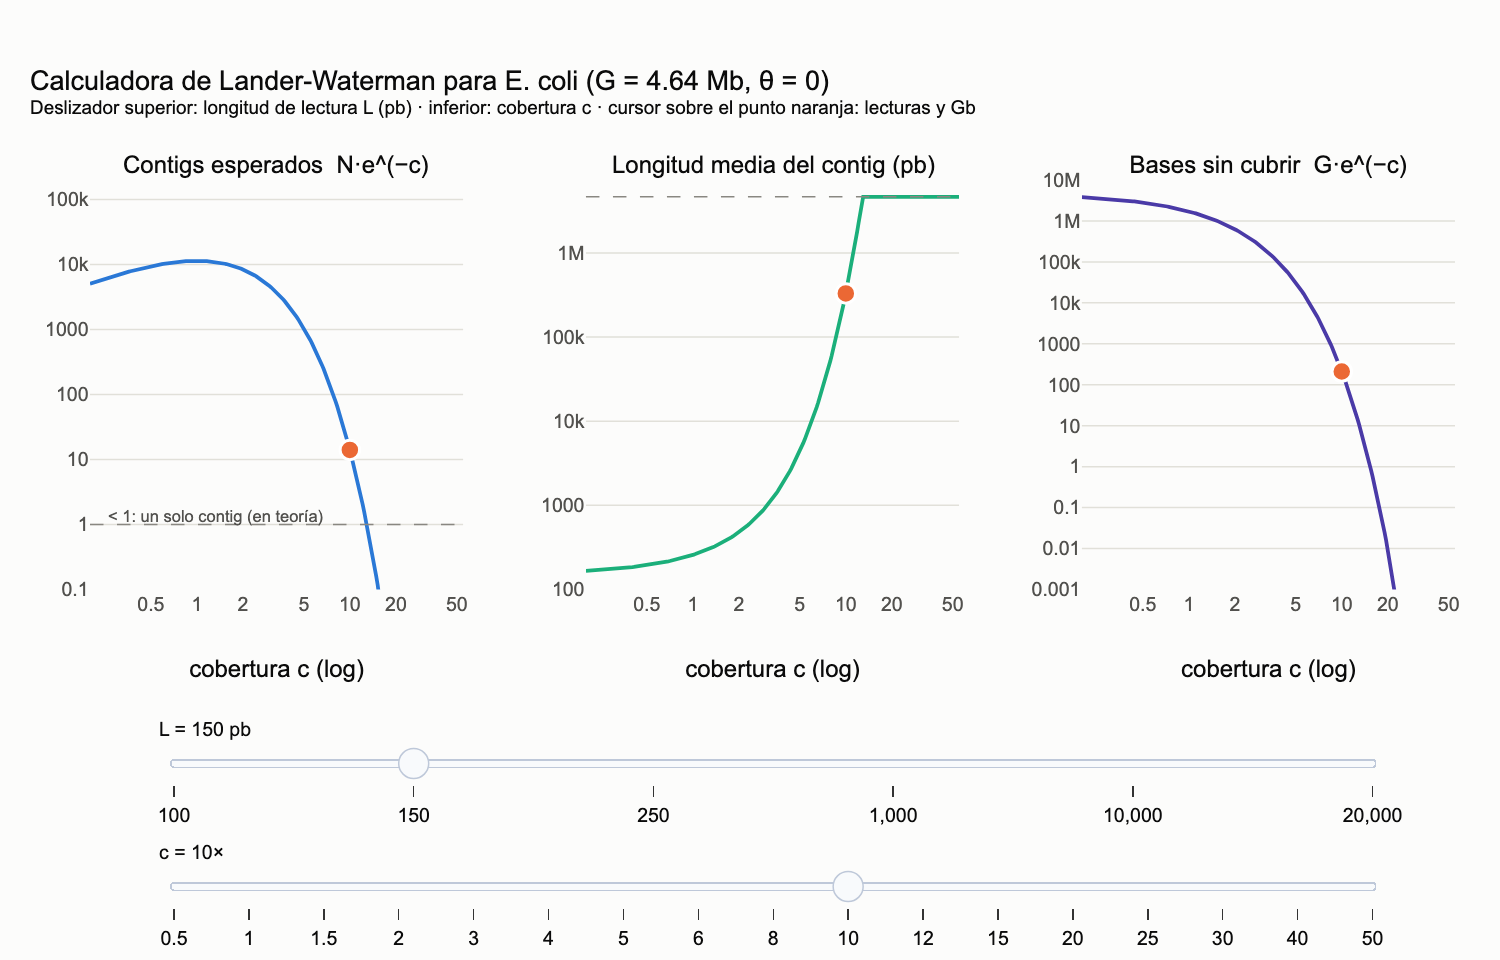

In [13]:
G_CALC = 4_641_652
L_OPTS = [100, 150, 250, 1_000, 10_000, 20_000]
C_OPTS = [0.5, 1, 1.5, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50]
L0, C0 = 150, 10
c_line = np.geomspace(0.2, 55, 250)

def lw_summary(c, L, G=G_CALC):
    n = c * G / L
    return dict(N=n, Gb=c * G / 1e9, contigs=lw_contigs(c, L, G), length=min(lw_contig_length(c, L), G),
                uncovered=G * np.exp(-c))

def hover(c, L):
    s = lw_summary(c, L)
    return (f"<b>L = {L:,} pb · c = {c}×</b><br>lecturas: {s['N']:,.0f} ({s['Gb']:.3f} Gb)"
            f"<br>contigs esperados: {s['contigs']:,.2f}<br>longitud media: {s['length']:,.0f} pb"
            f"<br>bases sin cubrir: {s['uncovered']:,.3g}")

fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.09,
                    subplot_titles=("Contigs esperados  N·e^(−c)", "Longitud media del contig (pb)",
                                    "Bases sin cubrir  G·e^(−c)"))
for L in L_OPTS:
    vis = L == L0
    fig.add_trace(go.Scatter(x=c_line, y=lw_contigs(c_line, L, G_CALC), line=dict(color=ec.BLUE, width=2.5),
                             visible=vis, showlegend=False,
                             hovertemplate=f"L = {L:,} pb<br>c = %{{x:.2f}}×<br>contigs = %{{y:,.2f}}<extra></extra>"),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=c_line, y=np.minimum(lw_contig_length(c_line, L), G_CALC),
                             line=dict(color=ec.AQUA, width=2.5), visible=vis, showlegend=False,
                             hovertemplate=f"L = {L:,} pb<br>c = %{{x:.2f}}×<br>longitud = %{{y:,.0f}} pb<extra></extra>"),
                  row=1, col=2)
    for col_i, key in [(1, "contigs"), (2, "length")]:
        fig.add_trace(go.Scatter(x=[C0], y=[lw_summary(C0, L)[key]], mode="markers", visible=vis, showlegend=False,
                                 marker=dict(size=13, color=ec.ORANGE, line=dict(color="white", width=2)),
                                 text=[hover(C0, L)], hovertemplate="%{text}<extra></extra>"),
                      row=1, col=col_i)
fig.add_trace(go.Scatter(x=c_line, y=G_CALC * np.exp(-c_line), line=dict(color=ec.VIOLET, width=2.5), showlegend=False,
                         hovertemplate="c = %{x:.2f}×<br>bases sin cubrir = %{y:,.3g}<extra></extra>"), row=1, col=3)
fig.add_trace(go.Scatter(x=[C0], y=[G_CALC * np.exp(-C0)], mode="markers", showlegend=False,
                         marker=dict(size=13, color=ec.ORANGE, line=dict(color="white", width=2)),
                         text=[hover(C0, L0)], hovertemplate="%{text}<extra></extra>"), row=1, col=3)

n_per = 4
marker_idx = [i * n_per + j for i in range(len(L_OPTS)) for j in (2, 3)] + [len(fig.data) - 1]
L_steps = [dict(method="restyle", label=f"{L:,}",
                args=[{"visible": [(i // n_per == k) if i < len(L_OPTS) * n_per else True
                                   for i in range(len(fig.data))]}])
           for k, L in enumerate(L_OPTS)]
c_steps = []
for c in C_OPTS:
    xs, ys, texts = [], [], []
    for L in L_OPTS:
        s = lw_summary(c, L)
        for key in ("contigs", "length"):
            xs.append([c]); ys.append([s[key]]); texts.append([hover(c, L)])
    xs.append([c]); ys.append([G_CALC * np.exp(-c)]); texts.append([f"c = {c}×<br>bases sin cubrir: {G_CALC * np.exp(-c):,.3g}"])
    c_steps.append(dict(method="restyle", label=str(c), args=[{"x": xs, "y": ys, "text": texts}, marker_idx]))

for col_i in (1, 2, 3):
    fig.update_xaxes(type="log", title_text="cobertura c (log)", tickvals=[0.5, 1, 2, 5, 10, 20, 50],
                     range=[np.log10(0.2), np.log10(55)], row=1, col=col_i)
fig.update_yaxes(type="log", dtick=1, range=[-1, 5.3], row=1, col=1)
fig.update_yaxes(type="log", dtick=1, range=[2, np.log10(G_CALC) + 0.2], row=1, col=2)
fig.update_yaxes(type="log", dtick=1, range=[-3, 7], row=1, col=3)
fig.add_hline(y=1, line=dict(color=ec.MUTED, dash="dash", width=1), row=1, col=1)
fig.add_annotation(x=np.log10(0.25), y=0.12, xref="x", yref="y", text="< 1: un solo contig (en teoría)", showarrow=False,
                   xanchor="left", font=dict(size=11, color=ec.INK_2))
fig.add_hline(y=G_CALC, line=dict(color=ec.MUTED, dash="dash", width=1), row=1, col=2)
fig.update_layout(
    title=dict(text="Calculadora de Lander-Waterman para E. coli (G = 4.64 Mb, θ = 0)<br>"
                    "<sup>Deslizador superior: longitud de lectura L (pb) · inferior: cobertura c · cursor sobre el punto naranja: lecturas y Gb</sup>"),
    height=640, margin=dict(t=120, b=240, l=60, r=30),
    sliders=[dict(active=L_OPTS.index(L0), steps=L_steps, currentvalue=dict(prefix="L = ", suffix=" pb"),
                  x=0.05, len=0.9, y=-0.26, pad=dict(t=10)),
             dict(active=C_OPTS.index(C0), steps=c_steps, currentvalue=dict(prefix="c = ", suffix="×"),
                  x=0.05, len=0.9, y=-0.56, pad=dict(t=10))])
fig.show()

> 🔎 **Qué observamos.** Con $L = 150$ y $c = 10\times$ la teoría promete ~14 contigs de ~330 kb. Suba $L$ a 20 000
> sin mover $c$: la curva de contigs baja más de cien veces, porque con la misma cobertura hay **muchas menos**
> lecturas, y cada contig necesita, en promedio, el mismo número $e^{c}$ de lecturas. En cambio, el panel de bases sin
> cubrir **no cambia**: $G e^{-c}$ sólo depende de la cobertura. La longitud de lectura decide cuántos cortes hay; la
> cobertura, cuántas bases faltan.

## 6. Lecturas largas y repeticiones: el límite que Lander-Waterman no ve

Lander-Waterman supone que **toda** pareja de lecturas que se solapan puede unirse sin ambigüedad. Eso es falso cuando
el genoma contiene **repeticiones**: dos copias casi idénticas de una misma secuencia (operones de ARN ribosomal,
transposones, secuencias de inserción IS). Si una lectura cae por completo dentro de una repetición, el ensamblador no
sabe a cuál de las copias pertenece, ni qué hay a continuación, y el contig se corta. Da igual la cobertura: con
lecturas cortas, **la estructura del genoma pone un piso** al número de contigs.

La solución es que la lectura sea **más larga que la repetición**: así la lectura "puentea" la repetición y ancla sus
dos extremos en secuencia única. Contemos las repeticiones reales del genoma de *E. coli* K-12.

> 📦 **Datos.** `NC_000913.3.fasta.gz`: el genoma de referencia de *E. coli* K-12 MG1655 (RefSeq). Se lee de `../data`;
> si no está, se descarga del repositorio del curso y, como último recurso, del NCBI.

In [14]:
ACC = "NC_000913.3"
fasta = course_bytes(f"{ACC}.fasta.gz",
                     f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={ACC}&rettype=fasta&retmode=text")
if fasta[:2] == b"\x1f\x8b":                  # copia del curso comprimida (la del NCBI llega como texto)
    fasta = gzip.decompress(fasta)
genome = "".join(fasta.decode().split("\n")[1:]).upper()
G_ECOLI = len(genome)
print(f"E. coli K-12 MG1655: {G_ECOLI:,} pb · GC = {(genome.count('G') + genome.count('C')) / G_ECOLI:.1%}")

E. coli K-12 MG1655: 4,641,652 pb · GC = 50.8%


Para encontrar repeticiones **exactas** de longitud $\geq k$ usamos un *hash* rodante: convertimos cada ventana de $k$
bases en un número de 64 bits (como una huella digital) y buscamos huellas repetidas, en la misma hebra o en la hebra
complementaria. Una ventana repetida indica que esa posición forma parte de una repetición de al menos $k$ bases; los
tramos consecutivos de ventanas repetidas son las **copias** de cada repetición. Todo con NumPy, sin bucles por
posición (tarda unos segundos).

In [15]:
def repeat_copies(seq, ks, pad=20_000):
    """Para cada k, cuenta los tramos del genoma circular que forman parte de una repetición exacta ≥ k pb
    (en cualquiera de las dos hebras) y devuelve también la longitud de cada tramo."""
    lut = np.zeros(256, np.uint64)
    lut[np.frombuffer(b"ACGT", np.uint8)] = np.arange(1, 5, dtype=np.uint64)
    fwd = lut[np.frombuffer(seq.encode(), np.uint8)]
    rev = (np.uint64(5) - fwd)[::-1] % np.uint64(5)          # complementaria inversa: A↔T (1↔4), C↔G (2↔3)
    G = len(seq)
    B = np.uint64(1_000_003)                                  # base del polinomio (impar: tiene inverso mód 2^64)
    with np.errstate(over="ignore"):
        pw = np.cumprod(np.r_[np.uint64(1), np.full(G + pad, B, np.uint64)])[: G + pad]
        ipw = np.cumprod(np.r_[np.uint64(1), np.full(G - 1, np.uint64(pow(int(B), -1, 2**64)), np.uint64)])
        H = [np.r_[np.uint64(0), np.cumsum(np.r_[x, x[:pad]] * pw)] for x in (fwd, rev)]
    out = {}
    for k in ks:
        with np.errstate(over="ignore"):
            h = np.concatenate([(Hs[k:k + G] - Hs[:G]) * ipw for Hs in H])   # huella de cada ventana
        _, inv, cnt = np.unique(h, return_inverse=True, return_counts=True)
        rep = cnt[inv[:G]] > 1                               # ventana de la hebra + que aparece más de una vez
        edges = np.diff(np.r_[0, rep.astype(np.int8), 0])
        run_len = np.flatnonzero(edges == -1) - np.flatnonzero(edges == 1)
        out[k] = run_len + k - 1                             # longitud de cada copia de repetición
    return out

K_LIST = [100, 150, 300, 500, 1_000, 2_000, 3_000, 5_000]
t0 = time.time()
reps = repeat_copies(genome, K_LIST)
rep_table = pd.DataFrame({"k (pb)": K_LIST, "copias de repetición ≥ k": [len(reps[k]) for k in K_LIST],
                          "pb en repeticiones": [int(reps[k].sum()) for k in K_LIST]})
longest = max(reps[k].max() for k in K_LIST if len(reps[k]))
print(f"({time.time() - t0:.1f} s) · repetición exacta más larga: {longest:,} pb")
rep_table

(8.1 s) · repetición exacta más larga: 3,186 pb


,k (pb),copias de repetición ≥ k,pb en repeticiones
0,100,212,109590
1,150,158,102878
2,300,89,88351
3,500,68,80533
4,1000,44,63618
5,2000,3,8871
6,3000,2,6054
7,5000,0,0


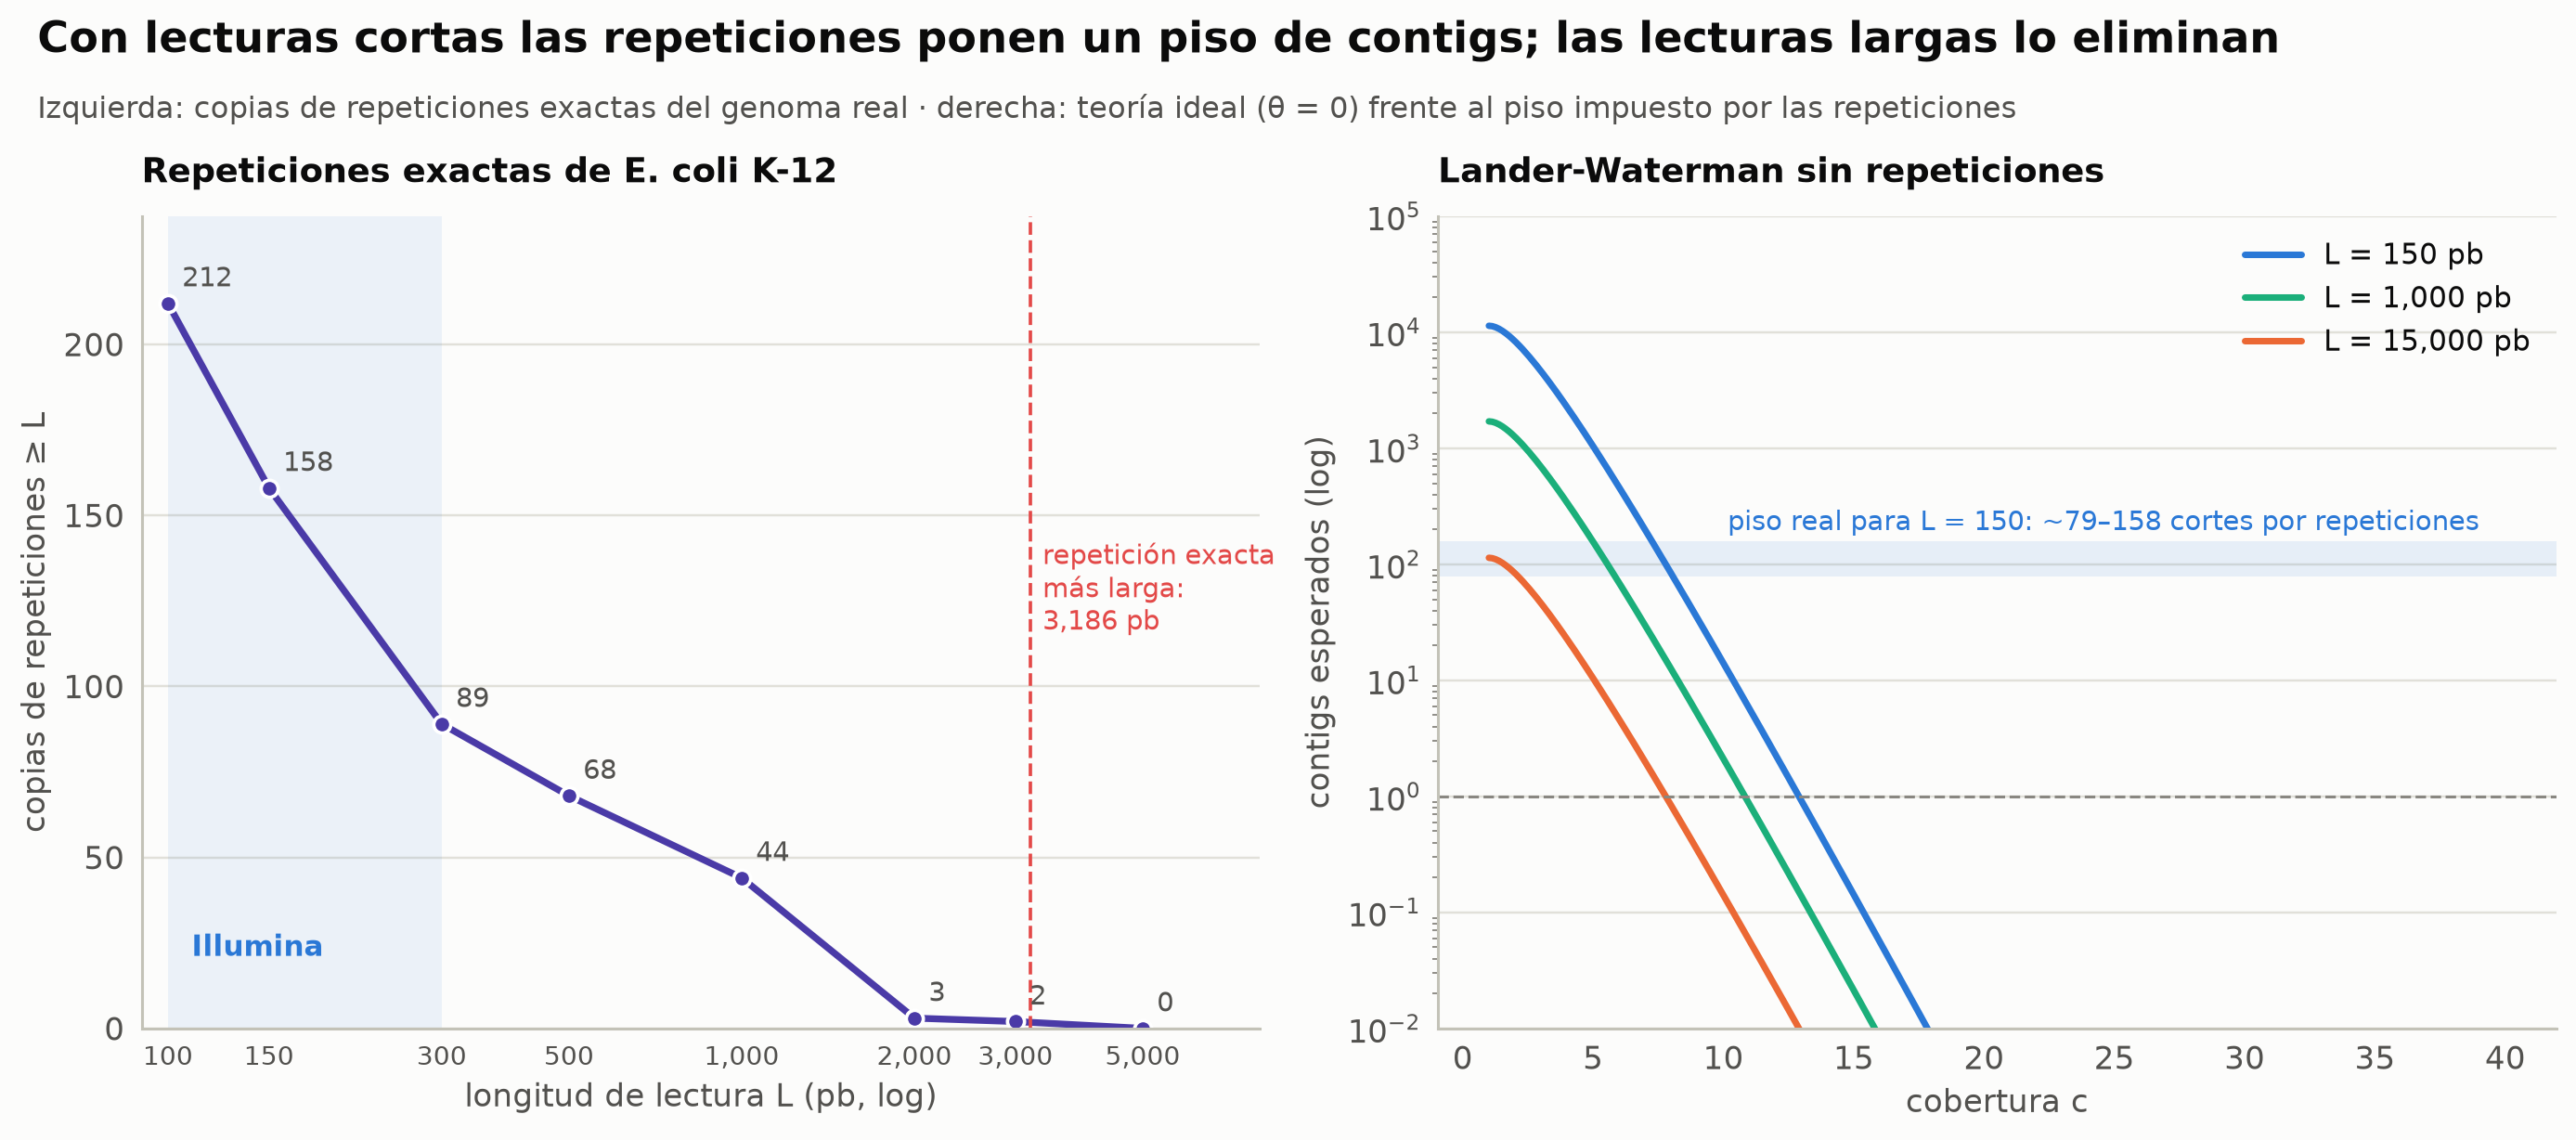

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
n_rep = [len(reps[k]) for k in K_LIST]
axes[0].plot(K_LIST, n_rep, "o-", color=ec.VIOLET, lw=2.4, ms=6, mec="white", mew=1.2)
for k, n in zip(K_LIST, n_rep):
    axes[0].annotate(str(n), (k, n), xytext=(5, 6), textcoords="offset points", ha="left", fontsize=9.5,
                     color=ec.INK_2)
axes[0].axvspan(100, 300, color=ec.BLUE, alpha=0.08); axes[0].text(110, max(n_rep) * 0.1, "Illumina", color=ec.BLUE,
                                                                     fontsize=10, fontweight="bold")
axes[0].axvline(longest, color=ec.RED, lw=1.2, ls="--")
axes[0].text(longest * 1.05, max(n_rep) * 0.55, f"repetición exacta\nmás larga:\n{longest:,} pb", color=ec.RED,
             fontsize=9.5)
axes[0].set_xscale("log"); axes[0].set_xlim(90, 8000); axes[0].set_ylim(0, max(n_rep) * 1.12)
axes[0].set_xticks(K_LIST, [f"{k:,}" for k in K_LIST], fontsize=9); axes[0].minorticks_off()
axes[0].set_xlabel("longitud de lectura L (pb, log)"); axes[0].set_ylabel("copias de repeticiones ≥ L")
axes[0].set_title("Repeticiones exactas de E. coli K-12", loc="left", fontsize=12)

c_r = np.linspace(1, 40, 300)
for L, col in [(150, ec.BLUE), (1_000, ec.AQUA), (15_000, ec.ORANGE)]:
    axes[1].semilogy(c_r, np.maximum(lw_contigs(c_r, L, G_ECOLI), 1e-3), color=col, lw=2.3, label=f"L = {L:,} pb")
floor = len(reps[150])
axes[1].axhspan(floor / 2, floor, color=ec.BLUE, alpha=0.10)
axes[1].text(39, floor * 1.25, f"piso real para L = 150: ~{floor // 2}–{floor} cortes por repeticiones", ha="right",
             fontsize=9.5, color=ec.BLUE)
axes[1].axhline(1, color=ec.MUTED, lw=1, ls="--")
axes[1].set_ylim(1e-2, 1e5); axes[1].set_xlabel("cobertura c"); axes[1].set_ylabel("contigs esperados (log)")
axes[1].set_title("Lander-Waterman sin repeticiones", loc="left", fontsize=12)
axes[1].legend(frameon=False, loc="upper right")
ec.fig_title(fig, "Con lecturas cortas las repeticiones ponen un piso de contigs; las lecturas largas lo eliminan",
             "Izquierda: copias de repeticiones exactas del genoma real · derecha: teoría ideal (θ = 0) frente al piso impuesto por las repeticiones")
plt.show()

> 🔎 **Qué observamos.** Con lecturas de 100–150 pb, el genoma de *E. coli* tiene del orden de **150 copias** de
> repeticiones exactas más largas que la lectura (operones *rrn*, elementos IS, genes duplicados). Aunque la teoría
> ideal prometa un solo contig a $40\times$, un ensamblaje real con lecturas cortas queda fragmentado en decenas o
> cientos de contigs, y **ninguna cobertura adicional lo arregla**. Con lecturas de más de unos pocos kilobases, en
> cambio, ya no quedan repeticiones exactas que la lectura no pueda cruzar: por eso hoy los genomas bacterianos se
> "cierran" en un solo contig circular con lecturas largas (PacBio HiFi, Oxford Nanopore), a menudo con sólo
> $30$–$50\times$. (Contamos sólo repeticiones **exactas**; las casi idénticas también confunden al ensamblador, así
> que el piso real es algo más alto. Lo retomaremos en la lección de ensamblaje.)

## 7. El mundo real: sesgo por GC y sobredispersión

Todo lo anterior supone que cada posición del genoma tiene **la misma** probabilidad de ser el inicio de una lectura.
En un experimento real no es así:

* **Sesgo por GC.** La amplificación por PCR y la hibridación en la celda de flujo funcionan peor con fragmentos muy
  ricos en AT o muy ricos en GC. Benjamini y Speed (2012) mostraron que la tasa de lecturas depende sobre todo del
  **contenido GC del fragmento completo** (no sólo de la lectura), con una curva en forma de campana: máxima en valores
  intermedios y baja en los extremos.
* **Duplicados de PCR.** Algunos fragmentos se amplifican más que otros y se leen varias veces (sección 11).
* **Mapeabilidad.** En las repeticiones, las lecturas no se pueden asignar con seguridad y se descartan.

Todos estos efectos hacen lo mismo: la **tasa** de lecturas deja de ser constante y varía de un lugar a otro. Una
Poisson cuya media cambia de región en región produce **más varianza** que una Poisson simple: es la
**sobredispersión**.

Vamos a simularlo sobre el genoma real de *E. coli*. Cada lectura sale del extremo de un fragmento de 300 pb, y la
probabilidad de que un fragmento se secuencie depende de su contenido GC según una campana centrada en 50 %
(una curva **ilustrativa**, de forma parecida a las publicadas por Benjamini y Speed):

$$
w(\text{gc}) = \exp\!\left[-\frac{1}{2}\left(\frac{\text{gc} - 0.50}{0.07}\right)^{2}\right]
$$

In [17]:
FRAG, L_RD, C_REAL = 300, 150, 30
gc_bin = np.frombuffer(genome.encode(), np.uint8)
is_gc = ((gc_bin == ord("G")) | (gc_bin == ord("C"))).astype(np.int32)
csum = np.r_[0, np.cumsum(np.r_[is_gc, is_gc[:FRAG]])]
frag_gc = (csum[FRAG:FRAG + G_ECOLI] - csum[:G_ECOLI]) / FRAG           # GC de cada fragmento (por su inicio)

def gc_bias(gc, center=0.50, width=0.07):
    return np.exp(-0.5 * ((gc - center) / width) ** 2)

N_REAL = int(reads_needed(C_REAL, L_RD, G_ECOLI))
d_unif = depth_profile(simulate_starts(N_REAL, G_ECOLI, rng), L_RD, G_ECOLI)
d_gc = depth_profile(simulate_starts(N_REAL, G_ECOLI, rng, weights=gc_bias(frag_gc)), L_RD, G_ECOLI)
for name, d in [("uniforme", d_unif), ("con sesgo GC", d_gc)]:
    print(f"{name:>13}: media {d.mean():6.2f} · varianza {d.var():7.2f} · bases con D = 0: {np.sum(d == 0):>7,}"
          f" · con D < 10: {np.mean(d < 10):.2%}")

WIN = 1_000
n_win = G_ECOLI // WIN
win_gc = is_gc[: n_win * WIN].reshape(n_win, WIN).mean(1)
win_unif = d_unif[: n_win * WIN].reshape(n_win, WIN).mean(1)
win_gcd = d_gc[: n_win * WIN].reshape(n_win, WIN).mean(1)

     uniforme: media  30.00 · varianza   29.91 · bases con D = 0:       0 · con D < 10: 0.00%
 con sesgo GC: media  30.00 · varianza  108.79 · bases con D = 0:  24,637 · con D < 10: 5.15%


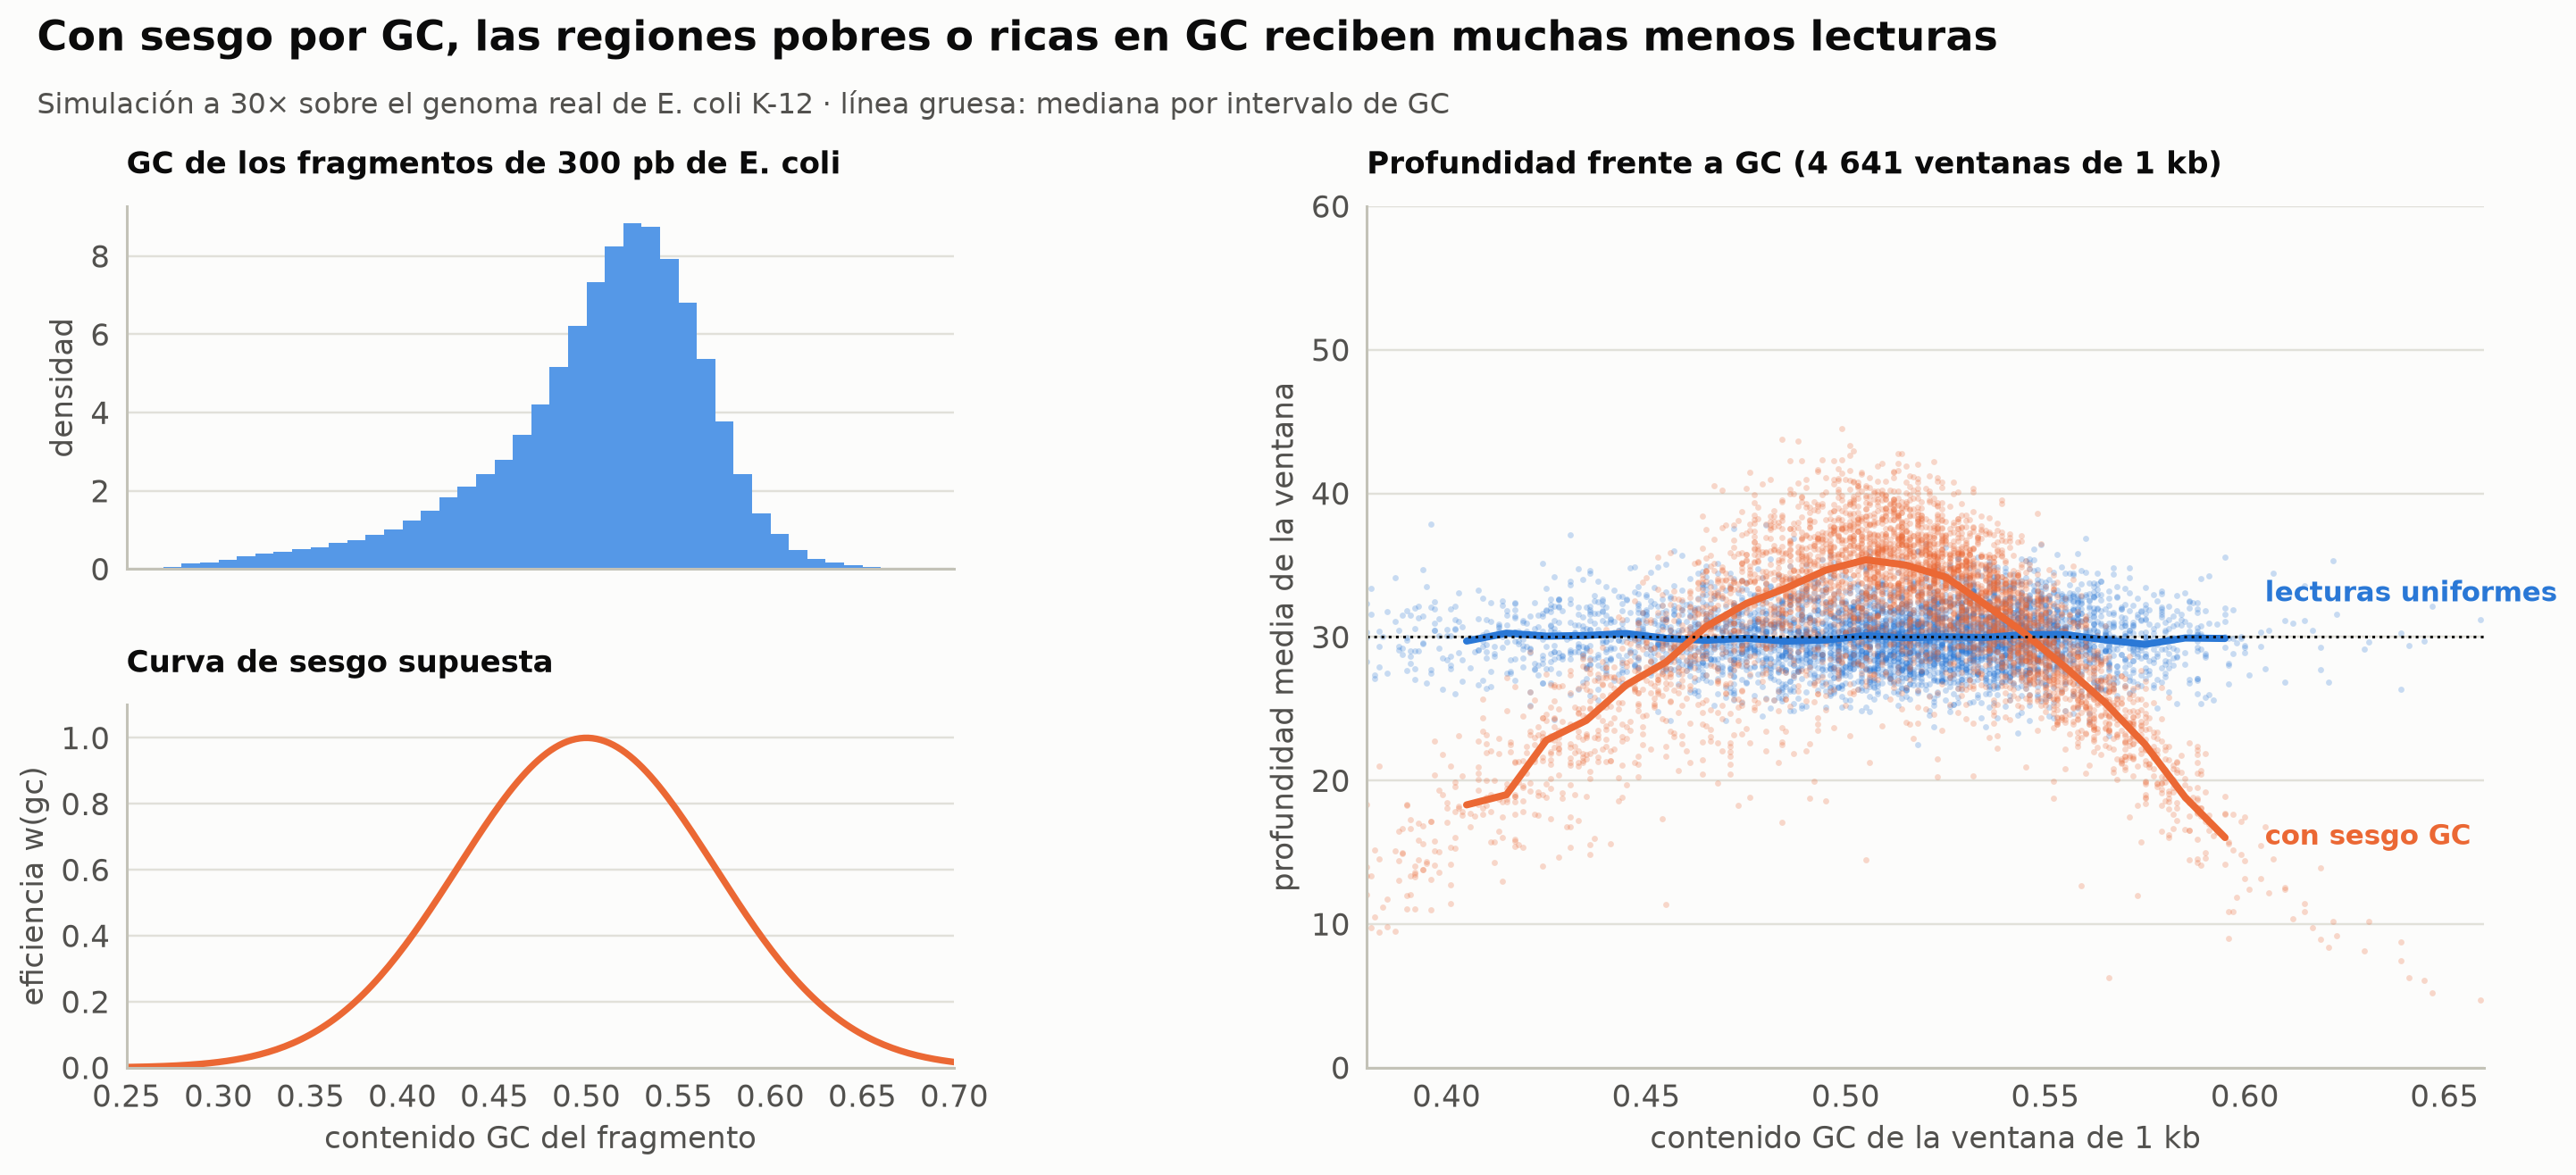

In [18]:
fig = plt.figure(figsize=(13, 5.2))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.35], height_ratios=[1, 1], hspace=0.12, wspace=0.22)
ax_h, ax_w, ax_s = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[:, 1])
gx = np.linspace(0.25, 0.70, 200)
ax_h.hist(frag_gc, bins=np.arange(0.25, 0.70, 0.01), color=ec.SEQ_BLUE[5], density=True)
ax_h.set_ylabel("densidad"); ax_h.set_xlim(0.25, 0.70); ax_h.tick_params(labelbottom=False)
ax_h.set_title("GC de los fragmentos de 300 pb de E. coli", loc="left", fontsize=11)
ax_w.plot(gx, gc_bias(gx), color=ec.ORANGE, lw=2.4)
ax_w.set_xlim(0.25, 0.70); ax_w.set_ylim(0, 1.1); ax_w.set_xlabel("contenido GC del fragmento")
ax_w.set_ylabel("eficiencia w(gc)")
ax_w.set_title("Curva de sesgo supuesta", loc="left", fontsize=11)
bins = np.arange(0.40, 0.62, 0.01)
a_is_unif = lambda lab: lab.startswith("lecturas")
for wv, col, lab in [(win_unif, ec.BLUE, "lecturas uniformes"), (win_gcd, ec.ORANGE, "con sesgo GC")]:
    ax_s.scatter(win_gc, wv, s=5, color=col, alpha=0.25, lw=0)
    idx = np.digitize(win_gc, bins)
    med = [np.median(wv[idx == i]) if np.sum(idx == i) > 20 else np.nan for i in range(1, len(bins))]
    ax_s.plot((bins[:-1] + bins[1:]) / 2, med, color=col, lw=2.6)
    ax_s.text(0.605, 33 if a_is_unif(lab) else med[-2], lab, color=col, fontsize=10, fontweight="bold", va="center")
ax_s.axhline(C_REAL, color=ec.INK, lw=1, ls=":")
ax_s.set_xlim(0.38, 0.66); ax_s.set_ylim(0, 60)
ax_s.set_xlabel("contenido GC de la ventana de 1 kb"); ax_s.set_ylabel("profundidad media de la ventana")
ax_s.set_title("Profundidad frente a GC (4 641 ventanas de 1 kb)", loc="left", fontsize=11)
ec.fig_title(fig, "Con sesgo por GC, las regiones pobres o ricas en GC reciben muchas menos lecturas",
             "Simulación a 30× sobre el genoma real de E. coli K-12 · línea gruesa: mediana por intervalo de GC")
plt.show()

> 🔎 **Qué observamos.** El GC de los fragmentos de *E. coli* va de ~35 % a ~60 %, así que la curva de sesgo afecta a
> una parte importante del genoma. Con lecturas uniformes (azul), la profundidad de las ventanas es plana: no depende
> del GC. Con sesgo (naranja), dibuja un **arco**: las ventanas de GC intermedio reciben más de 30× y las de GC
> extremo bajan a 10× o menos, aunque la cobertura media sea la misma. Así se ven los gráficos de "cobertura frente a
> GC" que producen herramientas de control de calidad como Picard (`CollectGcBiasMetrics`) o Qualimap.

### De la Poisson a la binomial negativa

Si la tasa de lecturas cambia de un lugar a otro, podemos pensar la profundidad en dos pasos:

1. cada región tiene su propia tasa $\lambda$, que varía alrededor de la media $\mu$ según una distribución **Gamma**;
2. dada esa tasa, la profundidad es Poisson($\lambda$).

Esa mezcla "Poisson con media Gamma" tiene nombre propio: la distribución **binomial negativa** (NB). Su media sigue
siendo $\mu$, pero su varianza tiene un término extra:

$$
\boxed{\;\operatorname{Var}(D) = \mu + \varphi\,\mu^{2}\;}
\qquad\qquad
P(D = k) = \frac{\Gamma(k + r)}{k!\,\Gamma(r)}\left(\frac{r}{r+\mu}\right)^{r}\left(\frac{\mu}{r+\mu}\right)^{k},
\quad r = \frac{1}{\varphi}
$$

| Símbolo | Significado |
|---|---|
| $\mu$ | profundidad media (la cobertura $c$) |
| $\varphi$ | **dispersión**: cuánto varía la tasa entre regiones ($\varphi = 0$ es la Poisson) |
| $r = 1/\varphi$ | parámetro de "tamaño" de la NB (el `n` de `scipy.stats.nbinom`) |
| $\Gamma(\cdot)$ | función gamma, la generalización del factorial: $\Gamma(k+1) = k!$ |

**Dos escrituras de la misma distribución.** El libro (capítulo 6) escribe la mezcla con la cobertura $c$ y el
parámetro de forma $r$: la tasa local sigue $\lambda \sim \operatorname{Gamma}(r,\ c/r)$ (forma $r$, escala $c/r$) y
$\operatorname{Var}(D) = c + c^{2}/r$. Aquí usamos $\mu$ y $\varphi$ porque es la notación de DESeq2 y edgeR, que
veremos en RNA-seq. La traducción es directa:

$$
\mu = c, \qquad \varphi = \frac{1}{r}
\qquad\Longrightarrow\qquad
\mu + \varphi\mu^{2} = c + \frac{c^{2}}{r}.
$$

Así, $r = 10$ es $\varphi = 0.1$ (la varianza a $30\times$ es $30 + 90 = 120$, cuatro veces la de la Poisson) y
$r = 5$ es $\varphi = 0.2$. Un $r$ grande significa un genoma homogéneo; $r \to \infty$ ($\varphi \to 0$) recupera la
Poisson.

**Ajuste por momentos.** Basta igualar la media y la varianza observadas: $\hat\mu = \bar D$ y
$\hat\varphi = (s^2 - \bar D)/\bar D^{2}$. Si $s^2 \le \bar D$ no hay sobredispersión y nos quedamos con la Poisson.

### Ejemplo a mano: $\mu = 30$, $\varphi = 0.1$

* Varianza: $30 + 0.1 \times 900 = 120$, desviación estándar $\sqrt{120} \approx 11$, frente a $\sqrt{30} \approx 5.5$
  de la Poisson: el doble de dispersión.
* Fracción de bases con $D < 10$: Poisson, $7 \times 10^{-6}$; NB, $0.009$, **más de mil veces** más.
* En un genoma humano ($3.1\times10^{9}$ pb) eso son ~22 000 bases frente a **~28 millones** de bases por debajo de
  10×. Ése es el motivo por el que los informes de secuenciación dan, además de la cobertura media, el porcentaje del
  genoma "≥ 10×" o "≥ 20×".

La binomial negativa es también el modelo estándar de los conteos de RNA-seq (DESeq2, edgeR), así que volverá a
aparecer en el curso.

uniforme    : μ = 30.00, φ = 0.0000
con sesgo GC: μ = 30.00, φ = 0.0875  (Var = 108.8; predicho μ + φμ² = 108.8)
comprobación: media de nbinom(n = 11.42, p = 0.276) = 30.00


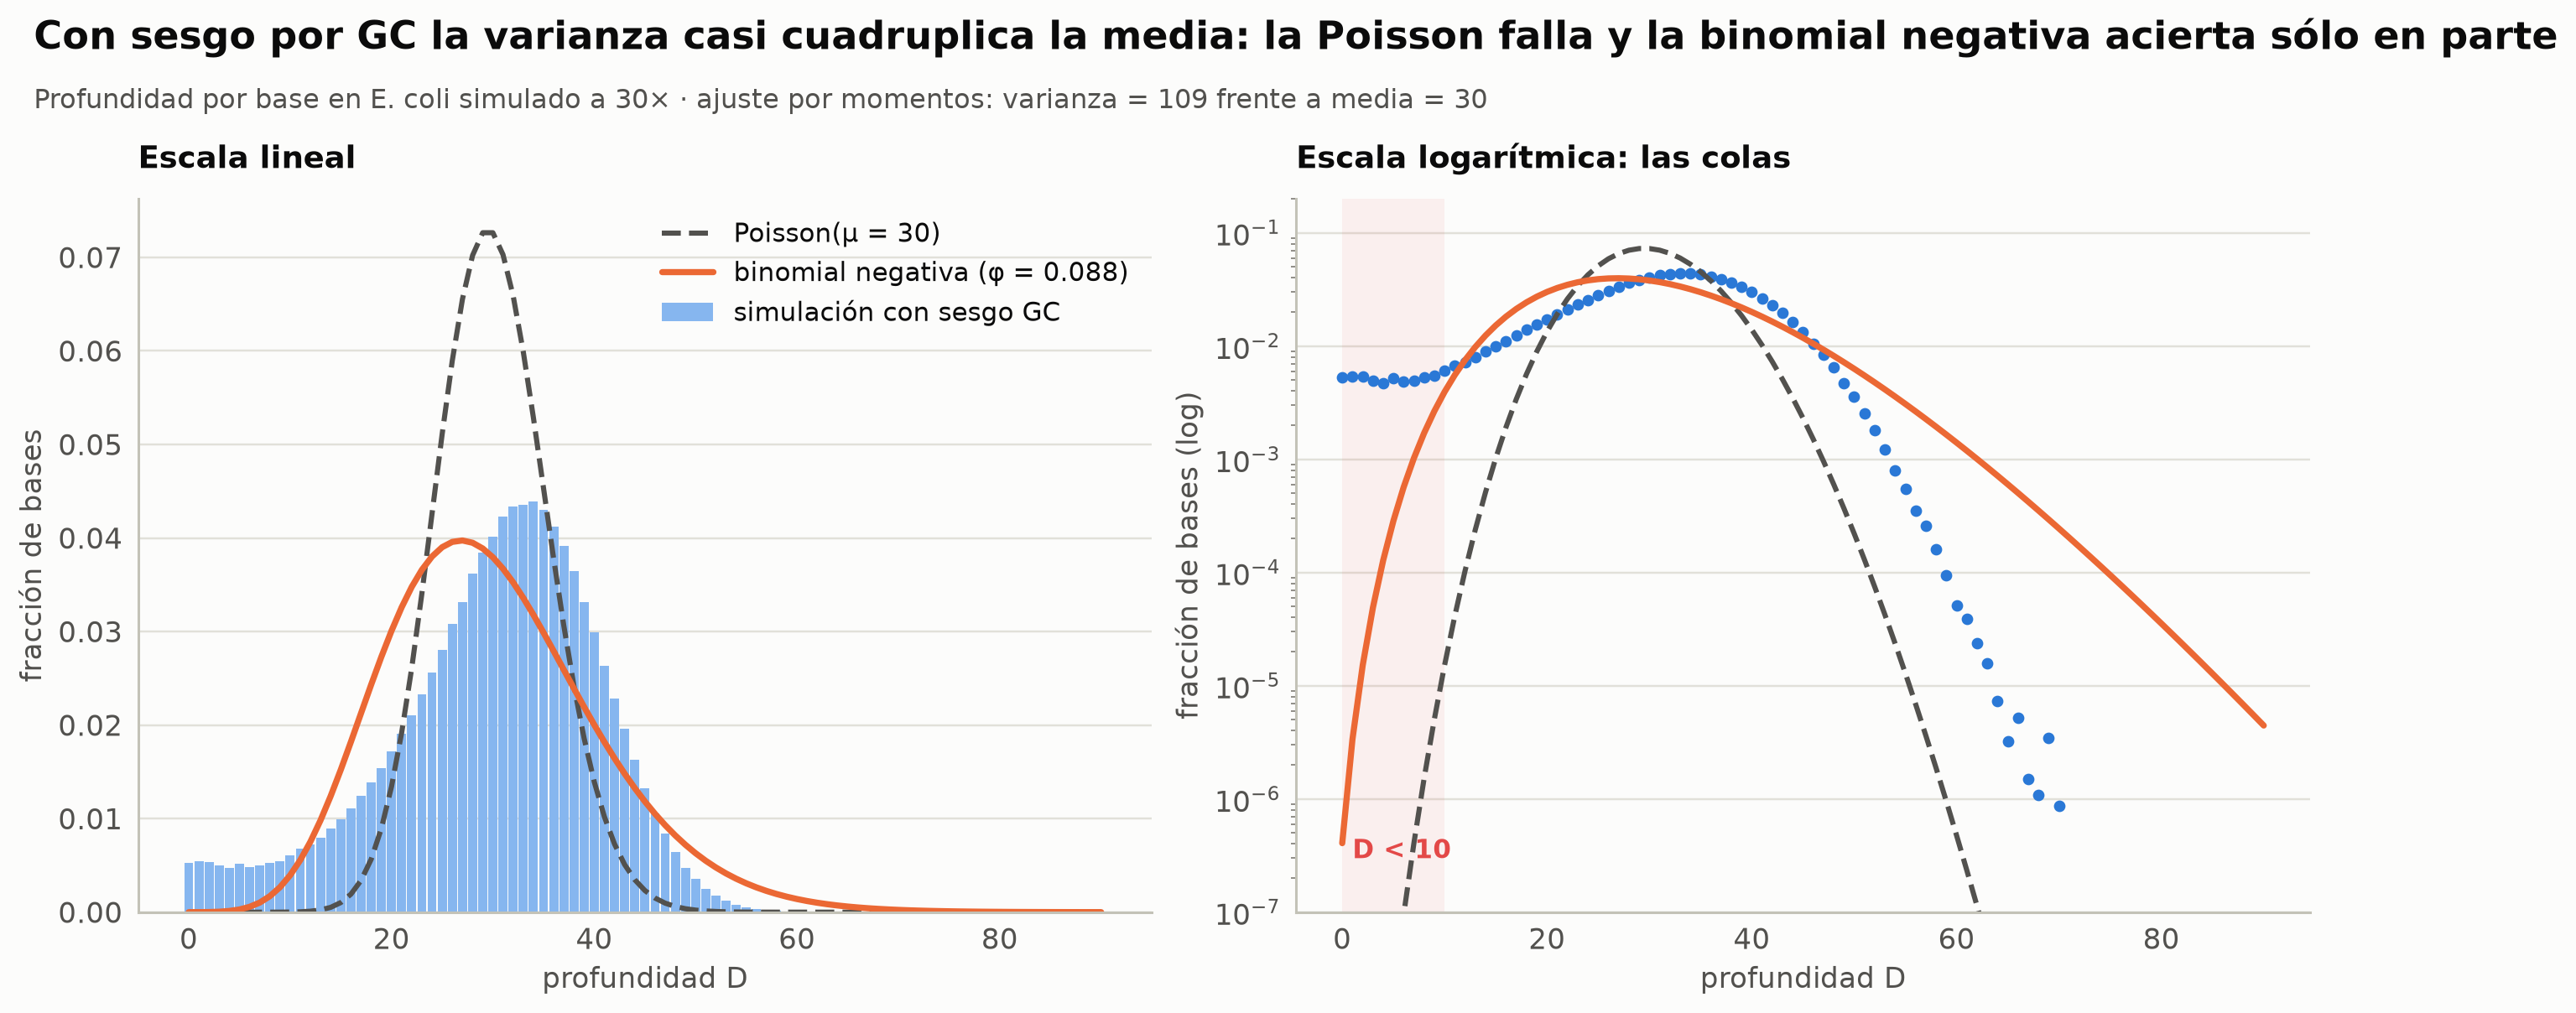

In [19]:
def fit_nb(d):
    """Ajuste por momentos: devuelve (μ, φ). φ = 0 significa Poisson."""
    m, v = d.mean(), d.var()
    return m, max((v - m) / m**2, 0.0)

def nb_pmf(k, mu, phi):
    """Binomial negativa con media μ y dispersión φ (Var = μ + φμ²)."""
    if phi <= 0:
        return poisson.pmf(k, mu)
    r = 1 / phi
    return nbinom.pmf(k, r, r / (r + mu))

mu_u, phi_u = fit_nb(d_unif)
mu_g, phi_g = fit_nb(d_gc)
print(f"uniforme    : μ = {mu_u:.2f}, φ = {phi_u:.4f}")
print(f"con sesgo GC: μ = {mu_g:.2f}, φ = {phi_g:.4f}  (Var = {d_gc.var():.1f}; predicho μ + φμ² = {mu_g + phi_g * mu_g**2:.1f})")
r_ = 1 / phi_g
print(f"comprobación: media de nbinom(n = {r_:.2f}, p = {r_ / (r_ + mu_g):.3f}) = {nbinom.mean(r_, r_ / (r_ + mu_g)):.2f}")

k = np.arange(0, 91)
obs = np.bincount(d_gc, minlength=91)[:91] / G_ECOLI
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))
axes[0].bar(k, obs, width=0.9, color=ec.SEQ_BLUE[3], label="simulación con sesgo GC")
axes[0].plot(k, poisson.pmf(k, mu_g), color=ec.INK_2, lw=2, ls="--", label=f"Poisson(μ = {mu_g:.0f})")
axes[0].plot(k, nb_pmf(k, mu_g, phi_g), color=ec.ORANGE, lw=2.4, label=f"binomial negativa (φ = {phi_g:.3f})")
axes[0].set_xlabel("profundidad D"); axes[0].set_ylabel("fracción de bases")
axes[0].legend(frameon=False, loc="upper right"); axes[0].set_title("Escala lineal", loc="left", fontsize=12)
axes[1].semilogy(k, np.maximum(obs, 1e-9), "o", color=ec.SEQ_BLUE[7], ms=3.5, label="simulación")
axes[1].semilogy(k, poisson.pmf(k, mu_g), color=ec.INK_2, lw=2, ls="--", label="Poisson")
axes[1].semilogy(k, nb_pmf(k, mu_g, phi_g), color=ec.ORANGE, lw=2.4, label="binomial negativa")
axes[1].set_ylim(1e-7, 0.2); axes[1].set_xlabel("profundidad D"); axes[1].set_ylabel("fracción de bases (log)")
axes[1].axvspan(0, 10, color=ec.RED, alpha=0.07)
axes[1].text(1, 3e-7, "D < 10", color=ec.RED, fontsize=10, fontweight="bold")
axes[1].set_title("Escala logarítmica: las colas", loc="left", fontsize=12)
ec.fig_title(fig, "Con sesgo por GC la varianza casi cuadruplica la media: la Poisson falla y la binomial negativa acierta sólo en parte",
             f"Profundidad por base en E. coli simulado a {C_REAL}× · ajuste por momentos: varianza = {d_gc.var():.0f} frente a media = {mu_g:.0f}")
plt.show()

> 🔎 **Qué observamos.** Con sesgo, la varianza (~109) es casi cuatro veces la media (30): el histograma es mucho más
> ancho que la Poisson. En escala logarítmica se ve lo importante: en la **cola izquierda** (bases con poca
> profundidad, las peligrosas para detectar variantes) la simulación tiene ~0.5 % de bases en **cada** valor de 0 a 10,
> miles de veces más de lo que predice la Poisson. La binomial negativa, con un único parámetro extra, reproduce bien
> la anchura central y mejora la cola izquierda en varios órdenes de magnitud, pero no es perfecta: las regiones muy
> pobres en GC casi no reciben lecturas (un exceso de ceros) y la cola derecha es más corta de lo que supone la NB. El
> sesgo real no tiene forma de Gamma; aun así, la NB es un modelo de trabajo mucho más honesto que la Poisson.

¿Se puede corregir el sesgo? Si conocemos la curva $w(\text{gc})$, sí: se estima la profundidad típica de cada nivel
de GC y se divide la profundidad observada entre ella. Así trabajan las correcciones de GC de herramientas de número
de copias (CNV) y de ChIP-seq. Estimamos la curva **a partir de los propios datos** (la mediana por intervalo de GC),
sin usar la $w$ verdadera.

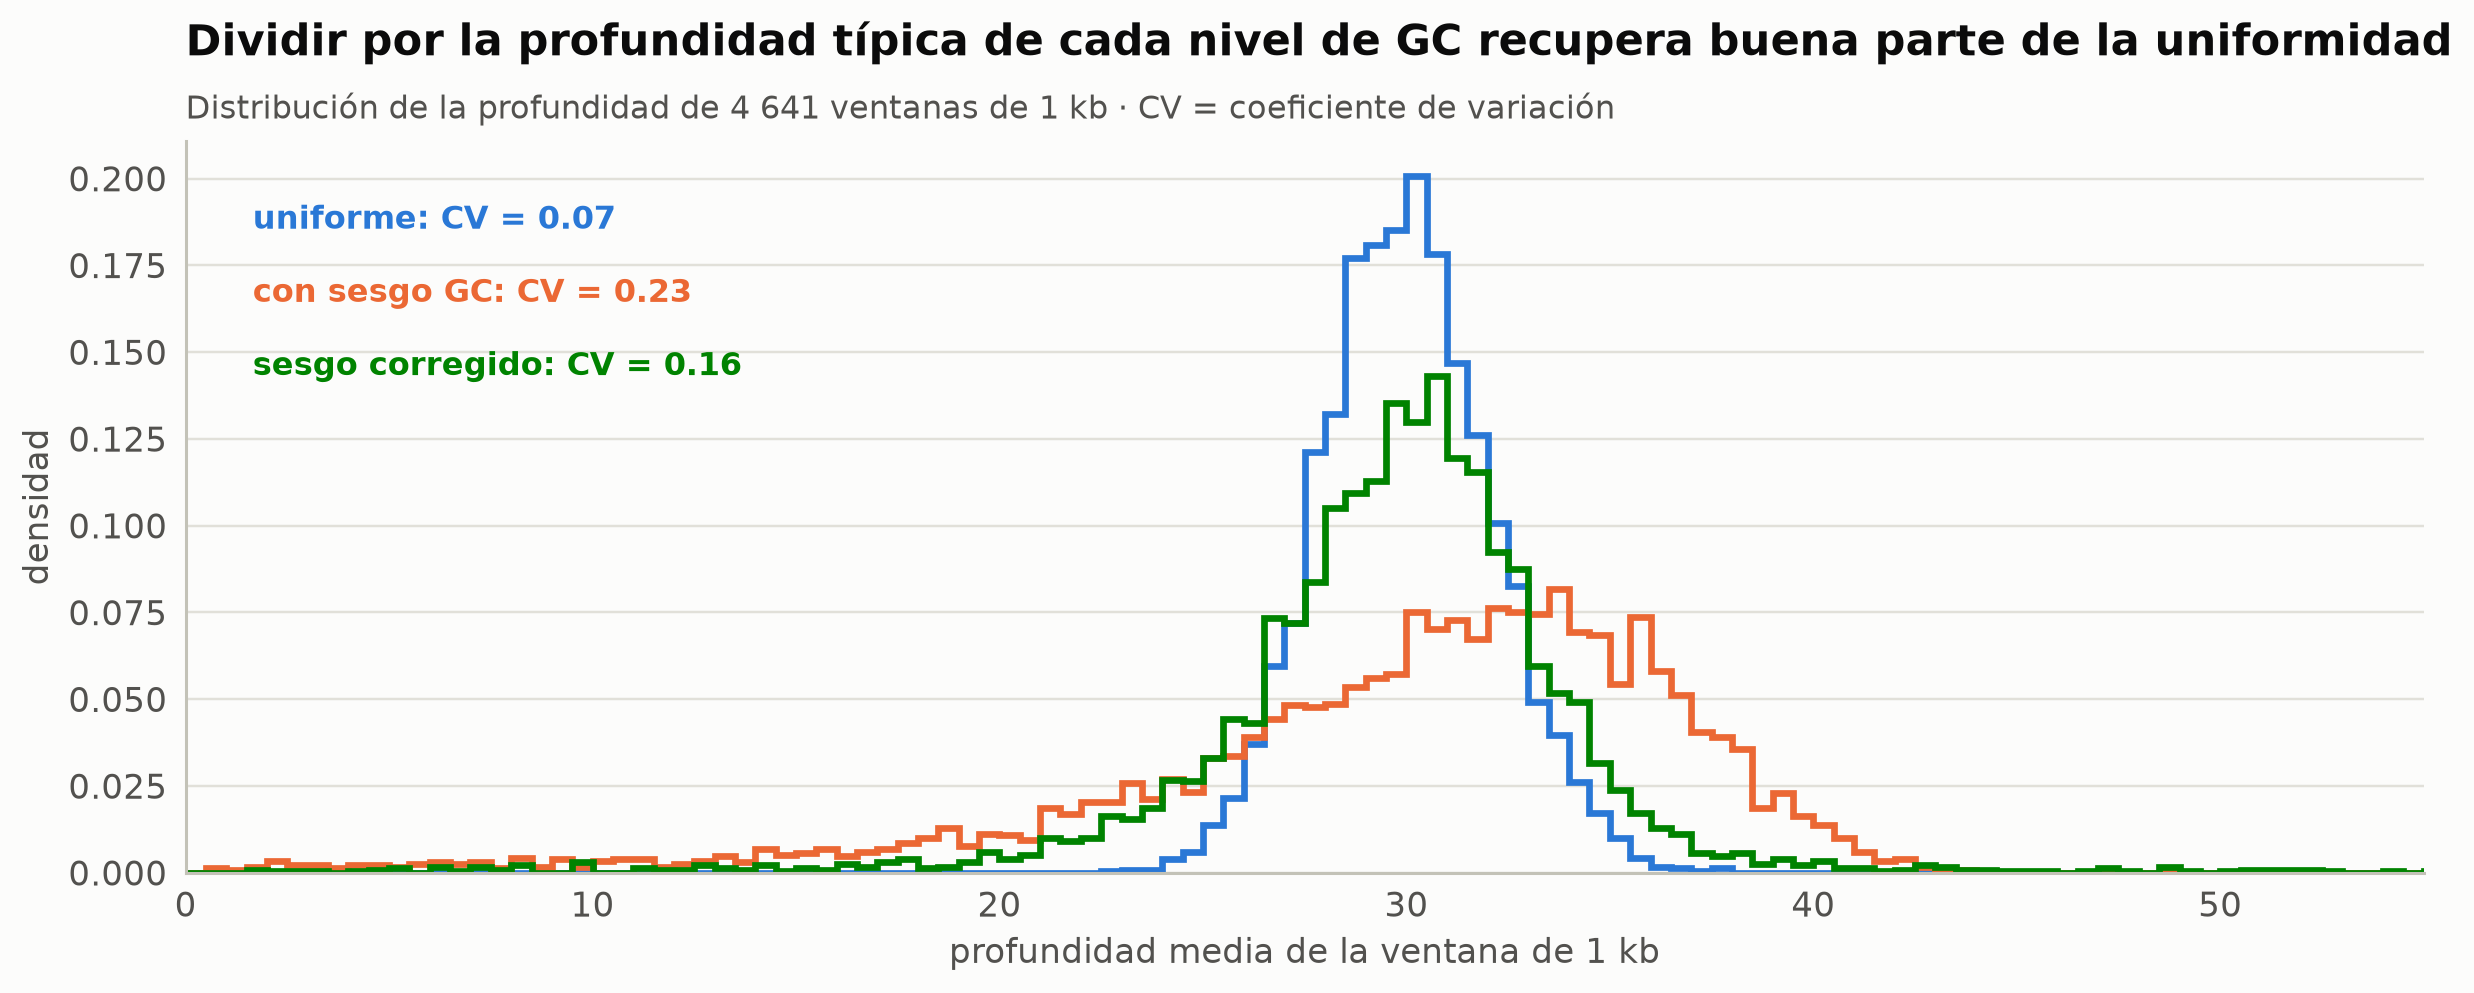

In [20]:
gc_edges = np.quantile(win_gc, np.linspace(0, 1, 26))
gidx = np.clip(np.digitize(win_gc, gc_edges[1:-1]), 0, 24)
expected = np.array([np.median(win_gcd[gidx == i]) for i in range(25)])[gidx]   # profundidad típica de su GC
win_corr = win_gcd / expected * win_gcd.mean()

fig, ax = plt.subplots(figsize=(11, 4.4))
hb = np.linspace(0, 60, 121)
for i, (wv, col, lab) in enumerate([(win_unif, ec.BLUE, "uniforme"), (win_gcd, ec.ORANGE, "con sesgo GC"),
                                    (win_corr, ec.GREEN, "sesgo corregido")]):
    ax.hist(wv, bins=hb, histtype="step", linewidth=2.2, color=col, density=True)
    ax.text(0.03, 0.88 - 0.1 * i, f"{lab}: CV = {wv.std() / wv.mean():.2f}", transform=ax.transAxes,
            color=col, fontsize=10.5, fontweight="bold")
ax.set_xlim(0, 55)
ax.set_xlabel("profundidad media de la ventana de 1 kb"); ax.set_ylabel("densidad")
ec.title(ax, "Dividir por la profundidad típica de cada nivel de GC recupera buena parte de la uniformidad",
         "Distribución de la profundidad de 4 641 ventanas de 1 kb · CV = coeficiente de variación")
plt.show()

> 🔎 **Qué observamos.** Las ventanas con sesgo tienen un coeficiente de variación tres veces mayor que las uniformes.
> Tras la corrección, la distribución verde se estrecha y se centra de nuevo en 30, aunque no llega a la azul: el GC
> medio de una ventana de 1 kb no refleja del todo el GC de cada fragmento de 300 pb que hay dentro (Benjamini y Speed
> insisten precisamente en modelar el sesgo **a escala del fragmento**). Cuidado: la corrección **arregla la
> estimación** de la profundidad relativa (útil para detectar deleciones o duplicaciones), pero **no crea lecturas**
> donde no las hubo. Las bases con 2 lecturas siguen teniendo 2 lecturas: para detectar variantes allí hay que
> secuenciar más o mejorar la química (por ejemplo, bibliotecas sin PCR).

✅ **Compruebe su comprensión.** En un experimento, la profundidad tiene media 40 y varianza 200. ¿Cuánto vale
$\varphi$? ¿Qué desviación estándar tendría una Poisson con esa media? (Respuesta: $\hat\varphi = (200 - 40)/1600 = 0.1$;
Poisson: $\sqrt{40} \approx 6.3$ frente a $\sqrt{200} \approx 14.1$ observada.)

### ¿Cuánto genoma queda sin leer cuando hay sesgo?

Con la Poisson, cada $1\times$ adicional divide la fracción sin leer por $e \approx 2.72$. Con sobredispersión la
historia cambia: hay regiones "difíciles" cuya tasa $\lambda$ es tan baja que secuenciar más apenas las toca. Basta
poner $k = 0$ en la binomial negativa (con la notación del libro):

$$
\boxed{\;P(D = 0) = \left(\frac{r}{r + c}\right)^{r} = \left(1 + \frac{c}{r}\right)^{-r}\;}
\qquad\text{frente a}\qquad P(D = 0) = e^{-c}\ \text{(Poisson)}
$$

**Ejemplo a mano** ($c = 30$, $r = 10$): $(1 + 3)^{-10} = 4^{-10} \approx 9.5\times10^{-7}$, frente a
$e^{-30} \approx 9.4\times10^{-14}$: diez millones de veces más bases sin ninguna lectura. En un genoma humano,
$3.1\times10^{9} \times 9.5\times10^{-7} \approx 3\,000$ bases, en vez de ninguna. Para $c \gg r$ la fórmula se
comporta como $(c/r)^{-r}$: una **potencia** de $c$, no una exponencial. Duplicar la cobertura sólo divide lo que
falta por $2^{r}$, sin importar cuánto hayamos secuenciado ya.

c = 10: Poisson e^(−c) = 4.54e-05 · NB r = 10: 9.77e-04 · NB r = 5: 4.12e-03
c = 30: Poisson e^(−c) = 9.36e-14 · NB r = 10: 9.54e-07 · NB r = 5: 5.95e-05


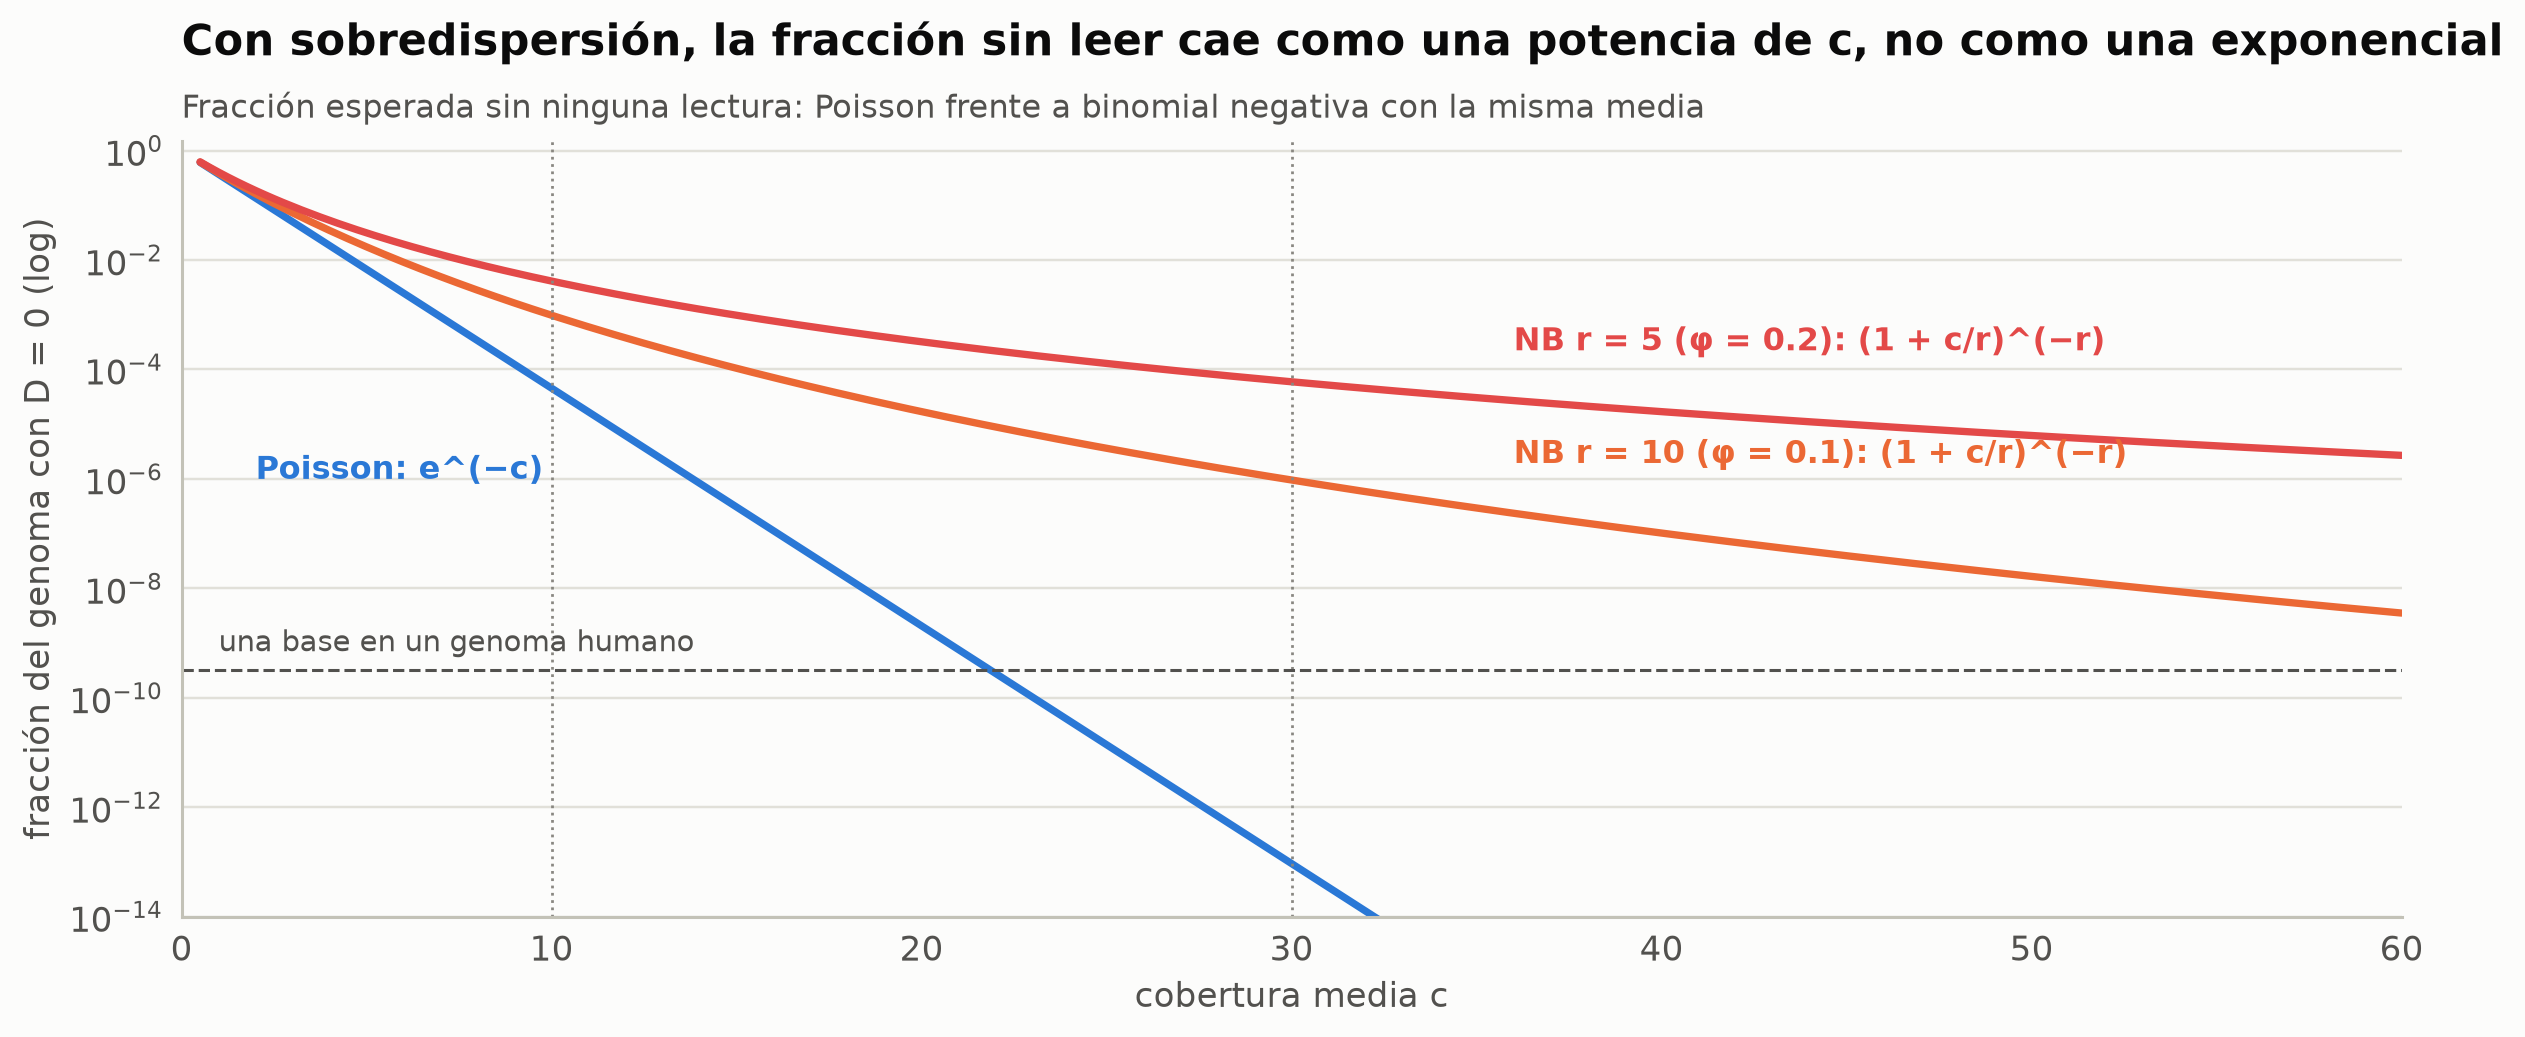

In [21]:
c_grid = np.linspace(0.5, 60, 240)
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.semilogy(c_grid, np.exp(-c_grid), color=ec.BLUE, lw=2.4)
ax.text(2, 1e-6, "Poisson: e^(−c)", color=ec.BLUE, fontsize=10.5, fontweight="bold", ha="left")
for r_nb, col in [(10, ec.ORANGE), (5, ec.RED)]:
    u = (1 + c_grid / r_nb) ** (-r_nb)
    ax.semilogy(c_grid, u, color=col, lw=2.4)
    ax.text(36, (1 + 36 / r_nb) ** (-r_nb) * 6, f"NB r = {r_nb} (φ = {1 / r_nb:g}): (1 + c/r)^(−r)", color=col,
            fontsize=10.5, fontweight="bold", va="bottom")
for c_mark in (10, 30):
    ax.axvline(c_mark, color=ec.MUTED, lw=0.9, ls=":")
    print(f"c = {c_mark}: Poisson e^(−c) = {np.exp(-c_mark):.2e} · NB r = 10: {(1 + c_mark / 10) ** -10:.2e}"
          f" · NB r = 5: {(1 + c_mark / 5) ** -5:.2e}")
ax.axhline(1 / 3.1e9, color=ec.INK_2, lw=1, ls="--")
ax.text(1, 1 / 3.1e9 * 2.2, "una base en un genoma humano", fontsize=9.5, color=ec.INK_2)
ax.set_xlim(0, 60); ax.set_ylim(1e-14, 1.5)
ax.set_xlabel("cobertura media c"); ax.set_ylabel("fracción del genoma con D = 0 (log)")
ec.title(ax, "Con sobredispersión, la fracción sin leer cae como una potencia de c, no como una exponencial",
         "Fracción esperada sin ninguna lectura: Poisson frente a binomial negativa con la misma media")
plt.show()

> 🔎 **Qué observamos.** En escala logarítmica la Poisson es una recta que cae sin freno: a $30\times$ ya está muy por
> debajo de "una base en un genoma humano". Las curvas de la binomial negativa se **aplanan**: con $r = 5$, incluso a
> $60\times$ quedan unas 8 000 bases humanas sin ninguna lectura. Ésa es la respuesta cuantitativa a "¿por qué no
> secuenciamos más y ya está?": contra el sesgo, más lecturas rinden cada vez menos; hace falta cambiar la química
> (bibliotecas sin PCR, lecturas largas) o aceptar esos huecos.

## 8. 🎛️ Poisson frente a binomial negativa

Explore cómo la dispersión $\varphi$ cambia la distribución de la profundidad cuando la cobertura media es $30\times$.
El deslizador mueve $\varphi$ desde 0 (Poisson pura) hasta 0.5 (datos muy irregulares, como los de algunas
bibliotecas de ADN amplificado a partir de muy poco material). El título de la figura indica qué fracción de un
genoma humano quedaría por debajo de 10× y de 20×.

> 🤔 **Antes de explorar, prediga:** ¿con qué $\varphi$ cree que la **moda** (el valor más frecuente) deja de estar
> cerca de 30?

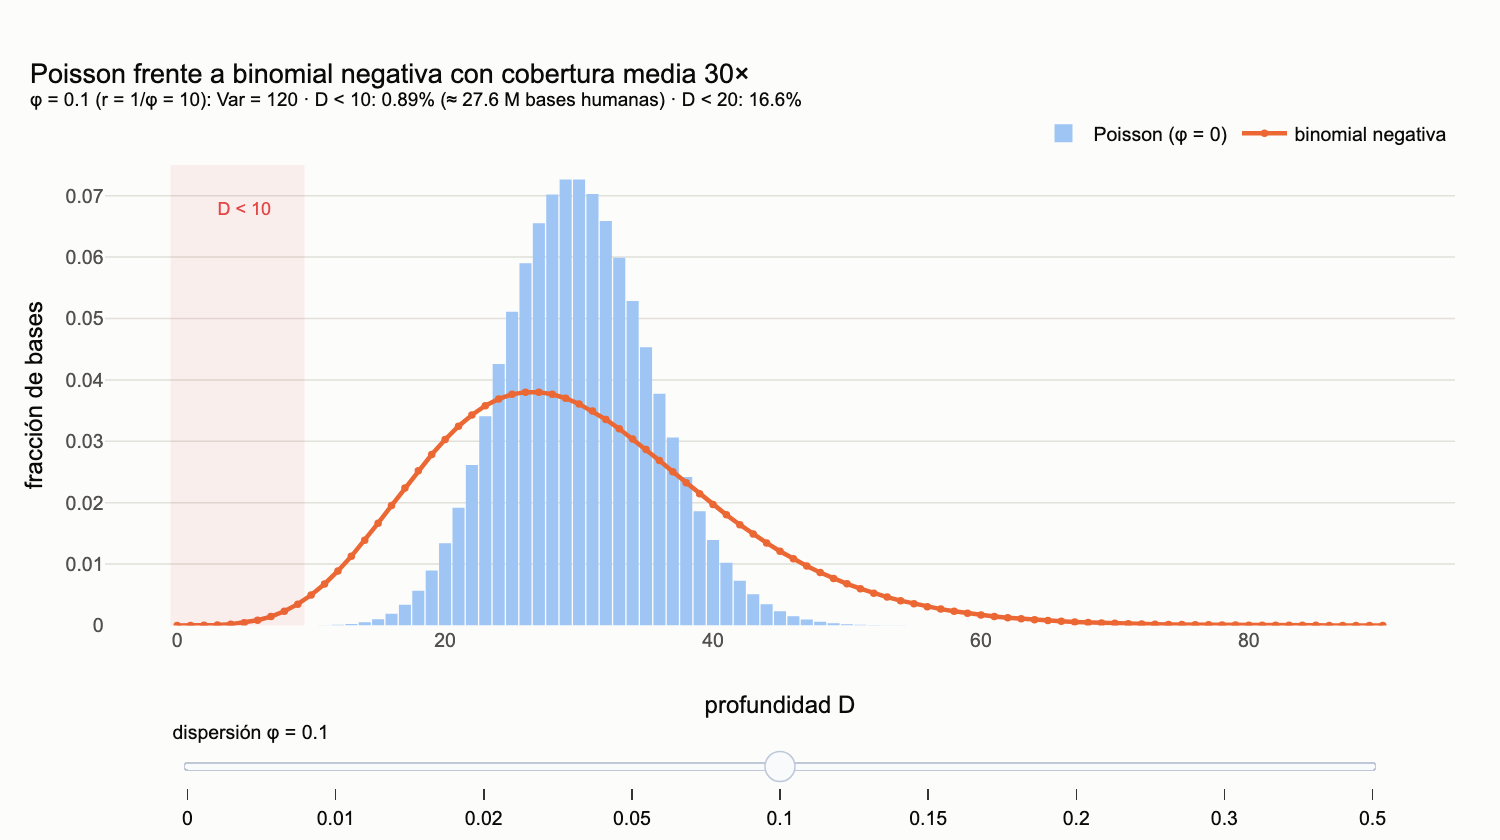

In [22]:
MU = 30
PHIS = [0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
kk = np.arange(0, 91)
pois = poisson.pmf(kk, MU)

def phi_text(phi):
    below10 = nb_pmf(np.arange(10), MU, phi).sum()
    below20 = nb_pmf(np.arange(20), MU, phi).sum()
    r_txt = f" (r = 1/φ = {1 / phi:g})" if phi > 0 else " (Poisson)"
    return (f"φ = {phi}{r_txt}: Var = {MU + phi * MU**2:.0f} · D < 10: {below10:.2%} (≈ {below10 * 3.1e9 / 1e6:,.1f} M bases humanas)"
            f" · D < 20: {below20:.1%}")

def phi_hover(phi):
    p = nb_pmf(kk, MU, phi)
    return [f"D = {k}<br>binomial negativa: {q:.4f}<br>Poisson: {pp:.4f}<br>P(D ≤ {k}) NB = {c:.3%}"
            for k, q, pp, c in zip(kk, p, pois, np.cumsum(p))]

fig = go.Figure()
fig.add_trace(go.Bar(x=kk, y=pois, name="Poisson (φ = 0)", marker_color=ec.SEQ_BLUE[2],
                     hovertemplate="D = %{x}<br>Poisson: %{y:.4f}<extra></extra>"))
phi0 = 0.1
fig.add_trace(go.Scatter(x=kk, y=nb_pmf(kk, MU, phi0), name="binomial negativa", mode="lines+markers",
                         line=dict(color=ec.ORANGE, width=3), marker=dict(size=5),
                         text=phi_hover(phi0), hovertemplate="%{text}<extra></extra>"))
fig.add_vrect(x0=-0.5, x1=9.5, fillcolor=ec.RED, opacity=0.08, line_width=0)
fig.add_annotation(x=5, y=0.068, text="D < 10", showarrow=False, font=dict(color=ec.RED, size=12))
title_of = lambda phi: ("Poisson frente a binomial negativa con cobertura media 30×<br><sup>" + phi_text(phi) + "</sup>")
steps = [dict(method="update", label=str(phi),
              args=[{"y": [nb_pmf(kk, MU, phi)], "text": [phi_hover(phi)]},
                    {"title.text": title_of(phi)}, [1]])
         for phi in PHIS]
fig.update_layout(title=dict(text=title_of(phi0)), height=560, margin=dict(t=110, b=130, l=70, r=30),
                  xaxis_title="profundidad D", yaxis_title="fracción de bases", yaxis_range=[0, 0.075], bargap=0.1,
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"),
                  sliders=[dict(active=PHIS.index(phi0), steps=steps, currentvalue=dict(prefix="dispersión φ = "),
                                x=0.05, len=0.9, y=-0.16, pad=dict(t=10))])
fig.show()

> 🔎 **Qué observamos.** Con $\varphi = 0.01$ la binomial negativa casi no se distingue de la Poisson. A partir de
> $\varphi \approx 0.05$ la curva se ensancha y la cola izquierda engorda: con $\varphi = 0.1$, casi el 1 % del genoma
> queda por debajo de 10×; con $\varphi = 0.5$ la moda se desplaza muy por debajo de 30 y más del 20 % del genoma queda
> por debajo de 10×, **con la misma cobertura media**. Dos experimentos "a 30×" pueden ser muy distintos: por eso los
> centros de secuenciación informan la uniformidad, no sólo la media.

## 9. ¿Cuánta profundidad necesito? La ecuación de diseño

### La situación

Un laboratorio de genética clínica ofrece la secuenciación del genoma completo para diagnosticar enfermedades raras.
Su protocolo validado exige **al menos 10 lecturas** en una posición para emitir un genotipo, y el informe promete
que eso se cumple en el **99 %** del genoma. Cuando el laboratorio encarga la corrida, la pregunta es muy concreta:
**¿cuántos × hay que pedir?**

La respuesta ingenua, "10×, porque queremos 10 lecturas", falla por lo que ya sabemos: la cobertura es un
**promedio**. Con $c = 10$, la profundidad es Poisson(10) y cerca de la **mitad** de las posiciones queda por debajo
de 10. Lo que hay que controlar no es la media sino la **cola izquierda** de la distribución: la fracción de
posiciones con pocas lecturas debe ser menor que un 1 %. Y como la sección 7 mostró que los datos reales son
sobredispersos, esa cola es más gruesa que la de la Poisson.

### Ejemplo a mano: ¿bastan 15×? ¿Y 20×?

Con la Poisson, la fracción de posiciones con menos de 10 lecturas es la suma de los diez primeros términos:

$$
P(D \le 9 \mid c) = e^{-c} \sum_{j=0}^{9} \frac{c^{j}}{j!}
$$

* **$c = 20$:** los términos $20^j/j!$ valen $1,\ 20,\ 200,\ 1\,333,\ 6\,667,\ 26\,667,\ 88\,889,\ 253\,968,\
  634\,921,\ 1\,410\,935$; suman $\approx 2\,423\,600$. Multiplicado por $e^{-20} \approx 2.06\times10^{-9}$ da
  $P(D \le 9) \approx 0.005$: un **0.5 %** del genoma por debajo de 10 lecturas. ✔ Cumple.
* **$c = 15$:** la misma cuenta da $P(D \le 9) \approx 0.070$: un **7 %**. ✘ No cumple.

La respuesta de la Poisson está, pues, entre 15× y 20×. Pero si los datos son sobredispersos (binomial negativa con
$r = 10$, es decir, $\varphi = 0.1$), a $20\times$ la fracción por debajo de 10 lecturas es del **6.5 %**: el mismo
experimento que la Poisson aprobaba **no cumple**.

### La ecuación

Llamemos $k$ a la profundidad mínima exigida y $\alpha$ a la fracción del genoma que toleramos por debajo de ella.
Buscamos el **menor** $c$ tal que

$$
\boxed{\;P(D \geq k \mid c) \;=\; 1 - F(k - 1 \mid c) \;\geq\; 1 - \alpha\;}
$$

donde $F$ es la función de distribución acumulada del modelo elegido: Poisson($c$) o binomial negativa de media $c$ y
forma $r$. No hay fórmula cerrada, pero como $P(D \ge k \mid c)$ crece con $c$, basta buscar numéricamente el punto
de cruce (el método de Brent, `scipy.optimize.brentq`, lo encuentra en microsegundos).

| Símbolo | Significado | Ejemplo clínico |
|---|---|---|
| $D$ | profundidad (aleatoria) en una posición | — |
| $k$ | profundidad mínima necesaria para llamar un genotipo | 10 lecturas |
| $\alpha$ | fracción tolerada del genoma por debajo de $k$ | 0.01 (1 %) |
| $F(\cdot \mid c)$ | función de distribución acumulada de $D$ con cobertura media $c$ | Poisson o NB |
| $r$ | forma de la binomial negativa ($r = 1/\varphi$; $r \to \infty$ es Poisson) | 10 o 5 |
| $c$ | cobertura media que hay que pedir (la incógnita) | ? |

> 🤔 **Antes de ejecutar, prediga:** si la Poisson pide ~19× para tener 10 lecturas en el 99 % del genoma, ¿cuánto
> pedirá una binomial negativa con $r = 5$: 25×, 35× o 45×?

In [23]:
from scipy.optimize import brentq

def coverage_needed(k, alpha=0.01, r=None):
    """Menor c con P(D ≥ k | c) ≥ 1 − α. r = None: Poisson; r: binomial negativa de media c y forma r
    (en scipy, nbinom(n = r, p = r/(r + c))). Es la función cobertura_necesaria del libro."""
    def excess(c):
        sf = poisson.sf(k - 1, c) if r is None else nbinom.sf(k - 1, r, r / (r + c))
        return sf - (1 - alpha)
    root = brentq(excess, k / 10, 50 * k, xtol=1e-10)
    return np.ceil(root * 100) / 100          # el menor c en pasos de 0.01× que cumple la condición

MODELS = [("Poisson", None), ("NB r = 10 (φ = 0.1)", 10), ("NB r = 5 (φ = 0.2)", 5)]
design = pd.DataFrame({name: [coverage_needed(k, 0.01, r) for k in (10, 20)] for name, r in MODELS},
                      index=["k = 10 lecturas", "k = 20 lecturas"])
design["NB r = 5 / Poisson"] = design["NB r = 5 (φ = 0.2)"] / design["Poisson"]
print("Cobertura media necesaria para que el 99 % del genoma tenga al menos k lecturas:")
print(design.round(2).to_string())

# Comprobación en el sentido contrario: a 30×, ¿qué fracción queda por debajo de 10 lecturas?
print(f"\nA 30×: P(D < 10) Poisson = {poisson.cdf(9, 30):.2e} · NB r = 10 = {nbinom.cdf(9, 10, 10 / 40):.4f}")
print(f"Ejemplo a mano: P(D ≤ 9) Poisson a 15× = {poisson.cdf(9, 15):.3f}, a 20× = {poisson.cdf(9, 20):.4f};"
      f" NB r = 10 a 20× = {nbinom.cdf(9, 10, 10 / 30):.3f}")

Cobertura media necesaria para que el 99 % del genoma tenga al menos k lecturas:
                 Poisson  NB r = 10 (φ = 0.1)  NB r = 5 (φ = 0.2)  NB r = 5 / Poisson
k = 10 lecturas    18.79                29.38               44.06                2.34
k = 20 lecturas    31.85                53.90               83.31                2.62

A 30×: P(D < 10) Poisson = 7.12e-06 · NB r = 10 = 0.0089
Ejemplo a mano: P(D ≤ 9) Poisson a 15× = 0.070, a 20× = 0.0050; NB r = 10 a 20× = 0.065


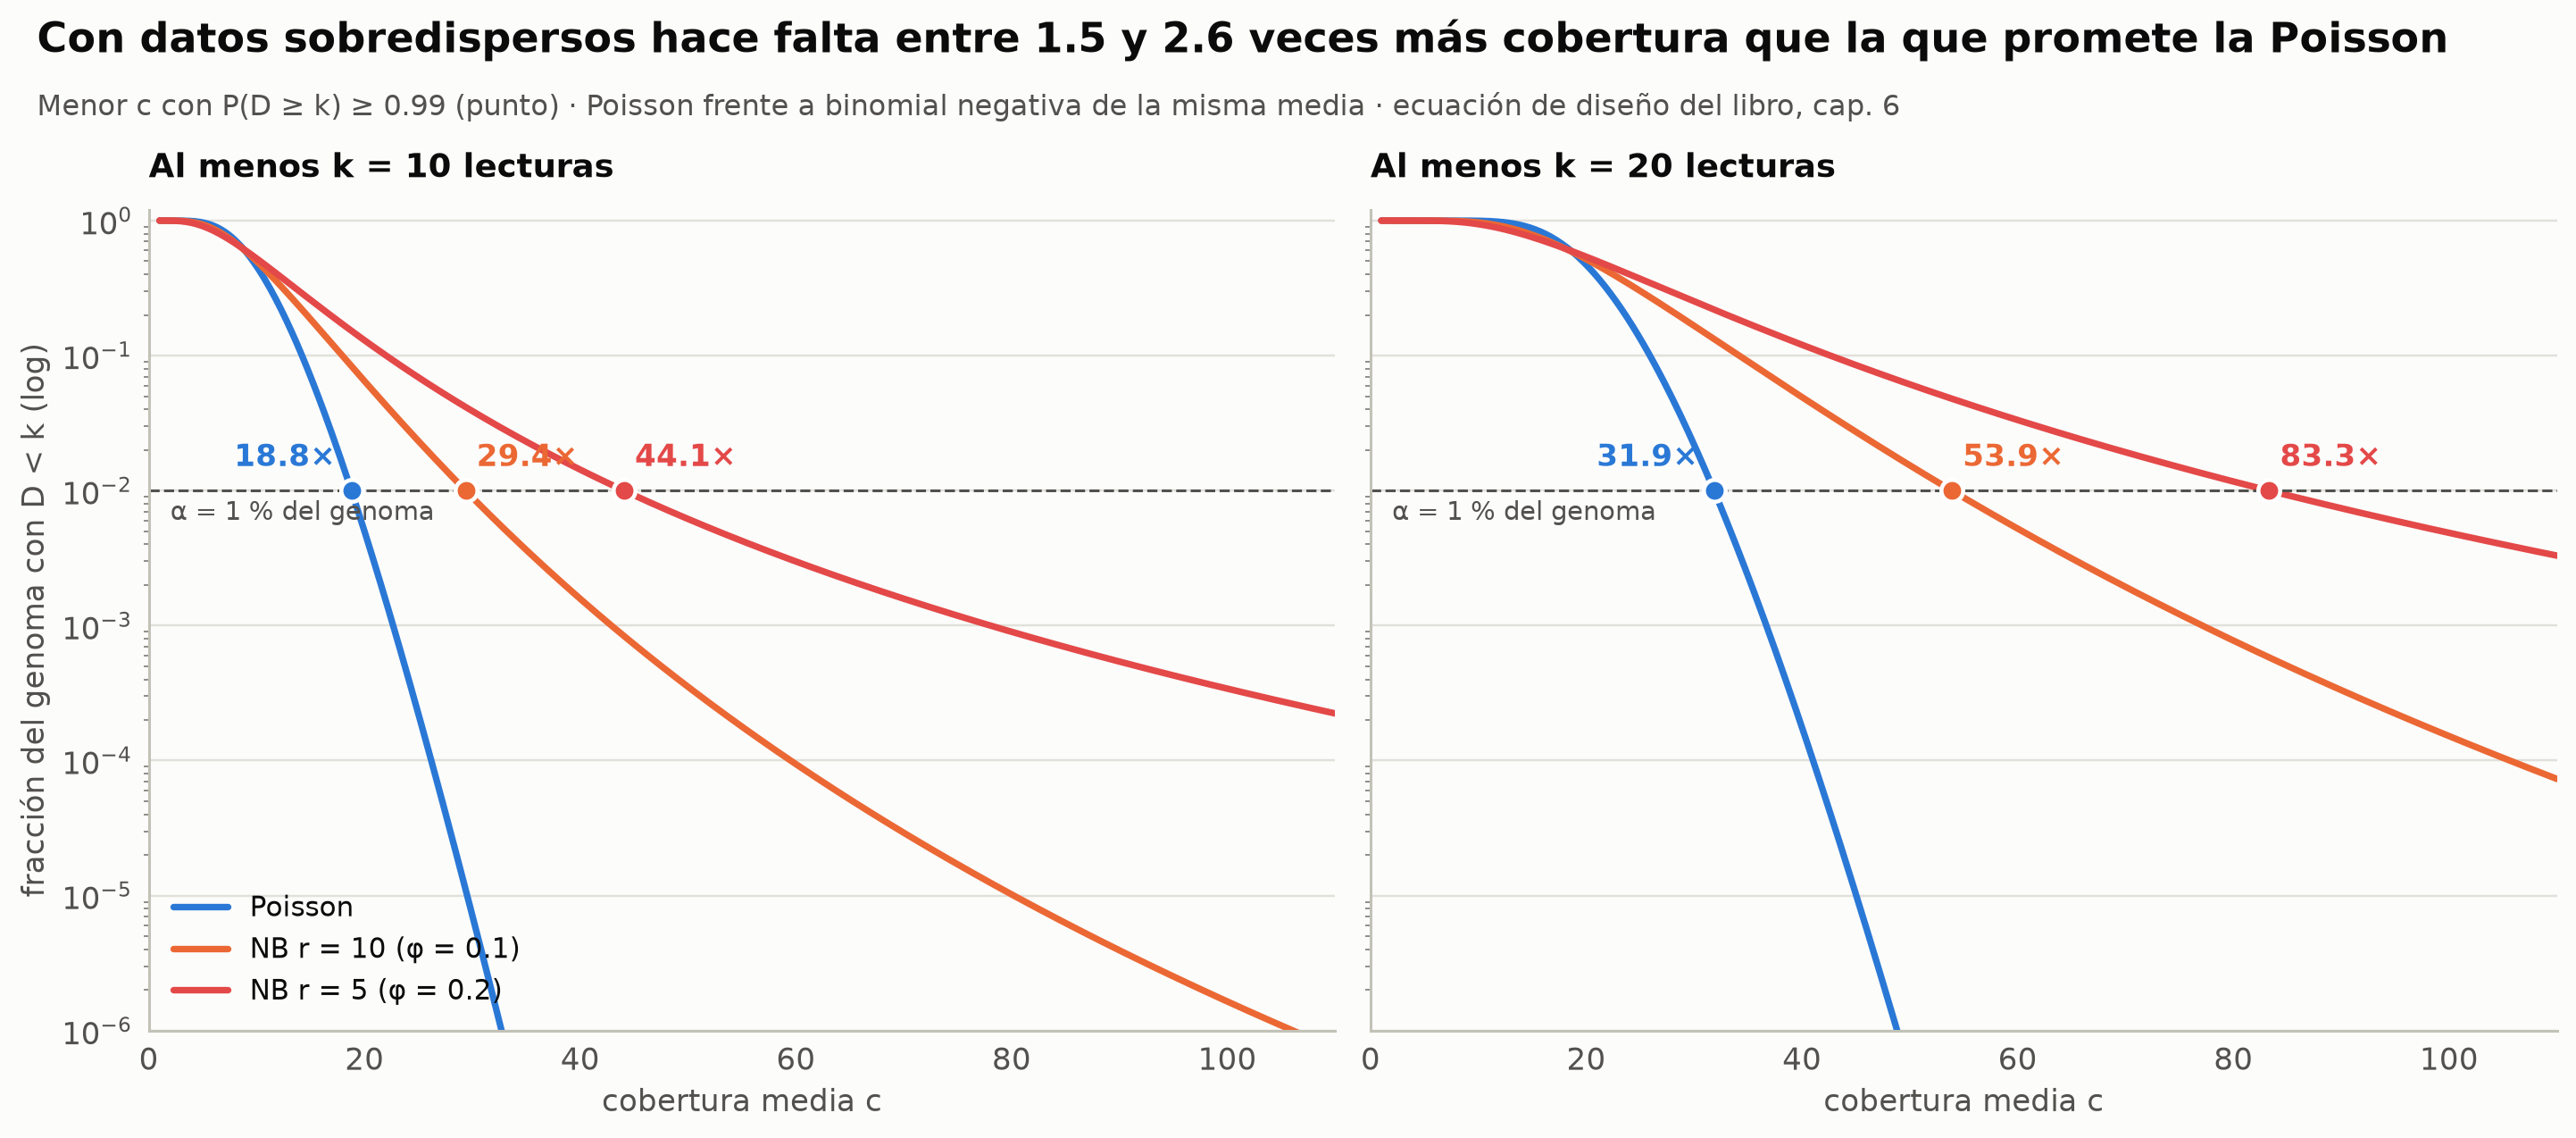

In [24]:
def frac_below(k, c, r=None):
    """P(D < k | c): fracción del genoma con menos de k lecturas."""
    return poisson.cdf(k - 1, c) if r is None else nbinom.cdf(k - 1, r, r / (r + c))

MODEL_COLORS = [ec.BLUE, ec.ORANGE, ec.RED]
c_des = np.linspace(1, 110, 437)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True)
for ax, k in zip(axes, (10, 20)):
    for (name, r), col in zip(MODELS, MODEL_COLORS):
        ax.semilogy(c_des, frac_below(k, c_des, r), color=col, lw=2.4, label=name)
        c_req = coverage_needed(k, 0.01, r)
        ax.plot(c_req, 0.01, "o", color=col, ms=8, mec="white", mew=1.5, zorder=5)
        left = r is None                                   # la etiqueta de la Poisson va a la izquierda del punto
        ax.annotate(f"{c_req:.1f}×", (c_req, 0.01), xytext=(-6 if left else 4, 9), textcoords="offset points",
                    color=col, fontsize=11, fontweight="bold", ha="right" if left else "left")
    ax.axhline(0.01, color=ec.INK_2, lw=1, ls="--")
    ax.text(2, 0.0085, "α = 1 % del genoma", ha="left", va="top", fontsize=9.5, color=ec.INK_2)
    ax.set_xlim(0, 110); ax.set_ylim(1e-6, 1.2)
    ax.set_xlabel("cobertura media c")
    ax.set_title(f"Al menos k = {k} lecturas", loc="left", fontsize=12)
axes[0].set_ylabel("fracción del genoma con D < k (log)")
axes[0].legend(frameon=False, loc="lower left")
ec.fig_title(fig, "Con datos sobredispersos hace falta entre 1.5 y 2.6 veces más cobertura que la que promete la Poisson",
             "Menor c con P(D ≥ k) ≥ 0.99 (punto) · Poisson frente a binomial negativa de la misma media · ecuación de diseño del libro, cap. 6")
plt.show()

> 🔎 **Qué observamos.** Las tres curvas bajan al aumentar la cobertura, pero a ritmos muy distintos. La Poisson cruza
> el umbral del 1 % a **18.8×** (para $k = 10$); con $r = 10$ hace falta **29.4×** y con $r = 5$, **44.1×**. Para
> $k = 20$ los valores suben a **31.9×, 53.9× y 83.3×**. El modelo ideal subestima la profundidad necesaria en un
> factor de 1.5 a 2.6. Fíjese en que la cifra "estándar" de **30×** para genomas humanos coincide casi exactamente con
> lo que pide un modelo realista ($r = 10$) para tener unas diez lecturas en el 99 % del genoma: no es una
> costumbre arbitraria, es la solución de esta ecuación.

Ahora explore usted. La figura interactiva siguiente resuelve la ecuación para distintos valores de $k$ y traduce cada
punto a términos que importan al encargar una corrida: cuántas megabases de un genoma humano quedarían por debajo del
umbral, cuántas kilobases de una bacteria de 5 Mb (un aislado de un brote) y cuántas gigabases útiles habría que
secuenciar para un genoma humano.

> 🤔 **Antes de explorar, prediga:** si el laboratorio de vigilancia de un brote exige **20** lecturas antes de afirmar
> que dos aislados difieren en un SNP, ¿cuánto sube la cobertura necesaria respecto a $k = 10$ con la binomial negativa
> $r = 10$: un 30 %, un 80 % o el triple?

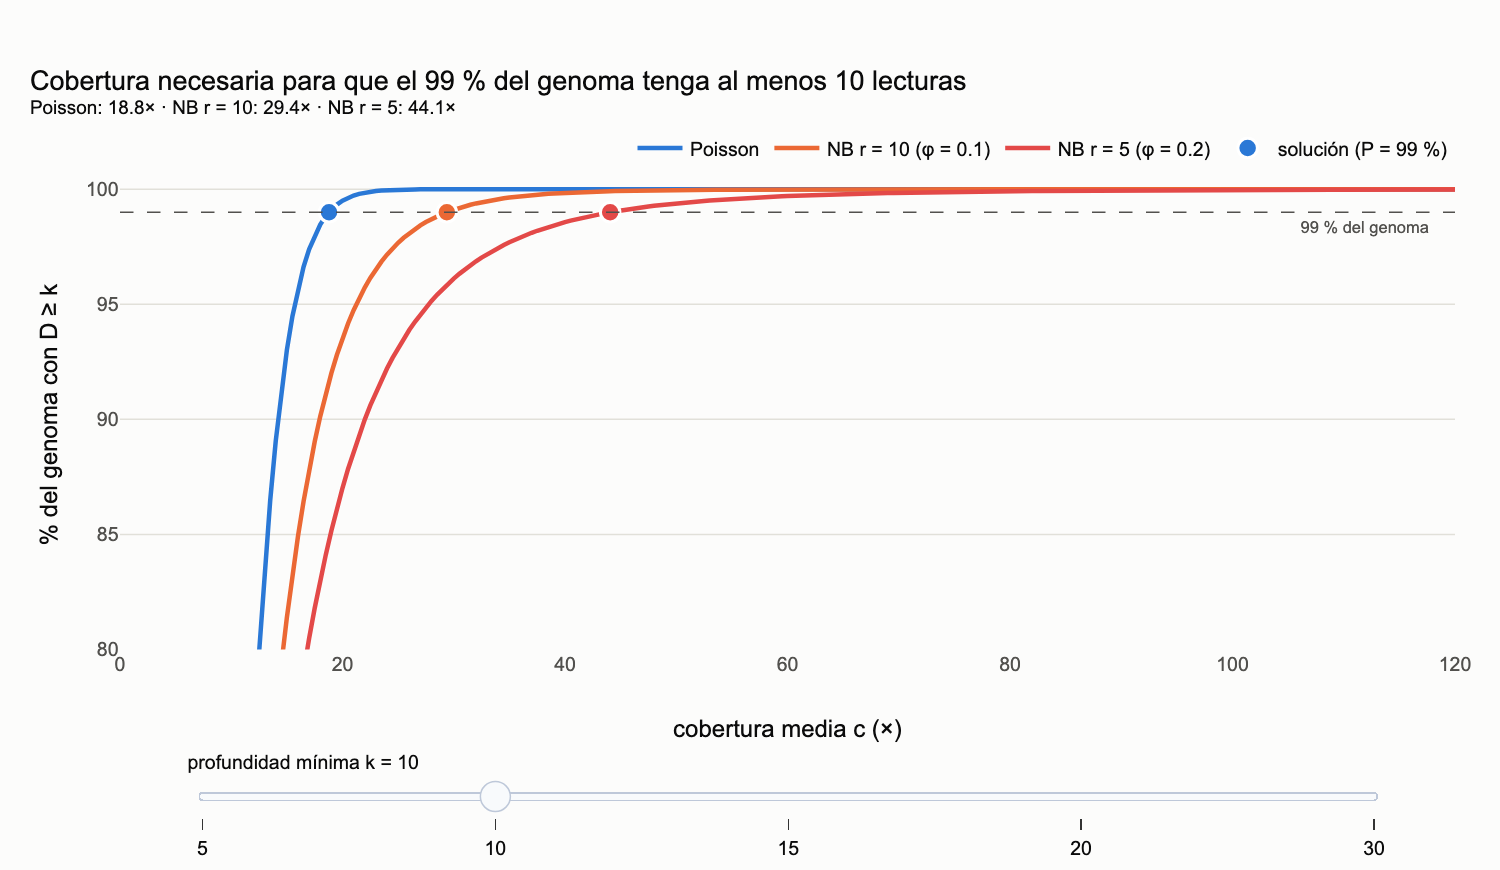

In [25]:
K_OPTS = [5, 10, 15, 20, 30]
c_int = np.round(np.arange(1, 120.5, 0.5), 1)
G_HUMAN, G_BACT = 3.1e9, 5e6

def design_traces(k):
    """y, textos de hover y punto de diseño de cada modelo para una profundidad mínima k."""
    ys, texts, px_, py_, ptxt = [], [], [], [], []
    for name, r in MODELS:
        below = frac_below(k, c_int, r)
        ys.append(100 * (1 - below))
        texts.append([f"<b>{name}</b> · c = {c:g}×<br>P(D ≥ {k}) = {100 * (1 - b):.2f} % del genoma"
                      f"<br>por debajo de {k} lecturas: {100 * b:.2g} %"
                      f"<br>→ humano: {b * G_HUMAN / 1e6:,.3g} Mb · bacteria de 5 Mb: {b * G_BACT / 1e3:,.3g} kb"
                      f"<br>Gb útiles para un genoma humano: {c * G_HUMAN / 1e9:,.0f}"
                      for c, b in zip(c_int, below)])
        c_req = coverage_needed(k, 0.01, r)
        px_.append(c_req); py_.append(99)
        ptxt.append(f"<b>{name}</b><br>mínimo para el 99 % con ≥ {k} lecturas: <b>{c_req:.1f}×</b>"
                    f"<br>humano: {c_req * G_HUMAN / 1e9:,.0f} Gb útiles · bacteria: {c_req * G_BACT / 1e6:,.2f} Mb útiles")
    return ys, texts, px_, py_, ptxt

def design_title(k):
    sol = " · ".join(f"{name.split(' (')[0]}: {coverage_needed(k, 0.01, r):.1f}×" for name, r in MODELS)
    return f"Cobertura necesaria para que el 99 % del genoma tenga al menos {k} lecturas<br><sup>{sol}</sup>"

k0 = 10
ys, texts, px_, py_, ptxt = design_traces(k0)
fig = go.Figure()
for i, ((name, r), col) in enumerate(zip(MODELS, MODEL_COLORS)):
    fig.add_trace(go.Scatter(x=c_int, y=ys[i], mode="lines", name=name, line=dict(color=col, width=3),
                             text=texts[i], hovertemplate="%{text}<extra></extra>"))
fig.add_trace(go.Scatter(x=px_, y=py_, mode="markers", name="solución (P = 99 %)", text=ptxt,
                         marker=dict(color=MODEL_COLORS, size=13, line=dict(color="white", width=2)),
                         hovertemplate="%{text}<extra></extra>"))
fig.add_hline(y=99, line=dict(color=ec.INK_2, dash="dash", width=1))
fig.add_annotation(x=118, y=99, text="99 % del genoma", showarrow=False, yshift=-10, xanchor="right",
                   font=dict(color=ec.INK_2, size=11))
steps = []
for k in K_OPTS:
    y_k, t_k, px_k, py_k, pt_k = design_traces(k)
    steps.append(dict(method="update", label=str(k),
                      args=[{"y": y_k + [py_k], "x": [c_int] * 3 + [px_k], "text": t_k + [pt_k]},
                            {"title.text": design_title(k)}, [0, 1, 2, 3]]))
fig.update_layout(title=dict(text=design_title(k0)), height=580, margin=dict(t=120, b=140, l=80, r=30),
                  xaxis_title="cobertura media c (×)", yaxis_title="% del genoma con D ≥ k",
                  xaxis_range=[0, 120], yaxis_range=[80, 100.4], hovermode="closest",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"),
                  sliders=[dict(active=K_OPTS.index(k0), steps=steps, currentvalue=dict(prefix="profundidad mínima k = "),
                                x=0.05, len=0.9, y=-0.17, pad=dict(t=10))])
fig.show()

> 🔎 **Qué observamos.** Al mover $k$ de 10 a 20, la cobertura necesaria sube de 18.8× a 31.9× con la Poisson (un
> 70 %) y de 29.4× a 53.9× con $r = 10$ (un 83 %): exigir el doble de lecturas **no** duplica el costo en la Poisson,
> porque la distribución se estrecha relativamente al crecer $c$, pero con sobredispersión el término $c^2/r$ de la
> varianza crece más deprisa y el costo se acerca al doble. Pase el cursor por la curva naranja en 30×: queda un ~0.9 %
> del genoma por debajo de 10 lecturas, ~28 Mb de un genoma humano (más de la mitad del cromosoma 21). En una
> bacteria de 5 Mb, ese mismo 0.9 % son ~45 kb, suficientes para esconder un gen de resistencia a antibióticos. Por eso los
> laboratorios informan siempre el **porcentaje del genoma ≥ 10×** o **≥ 20×**, no sólo la media, y planifican con la
> **cobertura efectiva** (tras descartar duplicados, lecturas de baja calidad y lecturas que no mapean), que puede
> quedarse en 22× útiles en un experimento anunciado como 30×.

✅ **Compruebe su comprensión.** Un colega propone diseñar un exoma con la Poisson "porque es lo que dice la teoría".
Usando la tabla de arriba, ¿cuánta cobertura le faltaría si la captura produce una dispersión como la de $r = 5$ y
necesita 20 lecturas en el 99 % de la región? (Respuesta: la Poisson pide 31.9×, la binomial negativa 83.3×: le
faltaría más del doble. Con la captura de exomas, que es muy irregular, $r$ suele ser aún menor.)

## 10. ¿Cuánta profundidad para ver un heterocigoto?

Hasta ahora preguntábamos si una base fue **leída**. Para el análisis de variantes (Módulo 9) la pregunta es más
exigente: ¿podemos **distinguir los dos alelos**? En una posición heterocigota, la mitad de las moléculas de ADN lleva
el alelo de referencia y la otra mitad el alternativo. Cada lectura "elige" una molécula al azar, como una moneda. Con
$d$ lecturas encima, el número de lecturas con el alelo alternativo es binomial:

$$
X \mid d \;\sim\; \operatorname{Binomial}(d,\ 0.5),
\qquad
\text{sensibilidad}(d) = P(X \geq k \mid d) = \sum_{j=k}^{d} \binom{d}{j} 0.5^{d}
$$

Un programa de llamado de variantes exige ver al menos $k$ lecturas con el alelo alternativo (con una sola podría ser
un error de secuenciación). Y como la profundidad $d$ también es aleatoria, la sensibilidad a una cobertura media $c$
promedia sobre la distribución de la profundidad:

$$
S(c) = \sum_{d=0}^{\infty} P(D = d)\; P(X \geq k \mid d)
$$

| Símbolo | Significado |
|---|---|
| $d$ | profundidad en la posición heterocigota |
| $X$ | lecturas que muestran el alelo alternativo |
| $k$ | mínimo de lecturas alternativas que exige el programa |
| $\binom{d}{j}$ | combinaciones de $d$ en $j$ |
| $S(c)$ | probabilidad de detectar el heterocigoto a cobertura media $c$ |

### Ejemplo a mano: $d = 10$, $k = 3$

Fallamos si vemos 0, 1 o 2 lecturas alternativas:

$$
P(X \le 2) = \frac{\binom{10}{0} + \binom{10}{1} + \binom{10}{2}}{2^{10}} = \frac{1 + 10 + 45}{1024} = 0.0547
\quad\Longrightarrow\quad \text{sensibilidad} = 0.945
$$

Con $d = 20$: $P(X \le 2) = (1 + 20 + 190)/2^{20} = 0.0002$, sensibilidad $0.9998$. Doblar la profundidad reduce el
fallo 270 veces.

d = 10, k = 3: 0.9453   ·   d = 20, k = 3: 0.99980


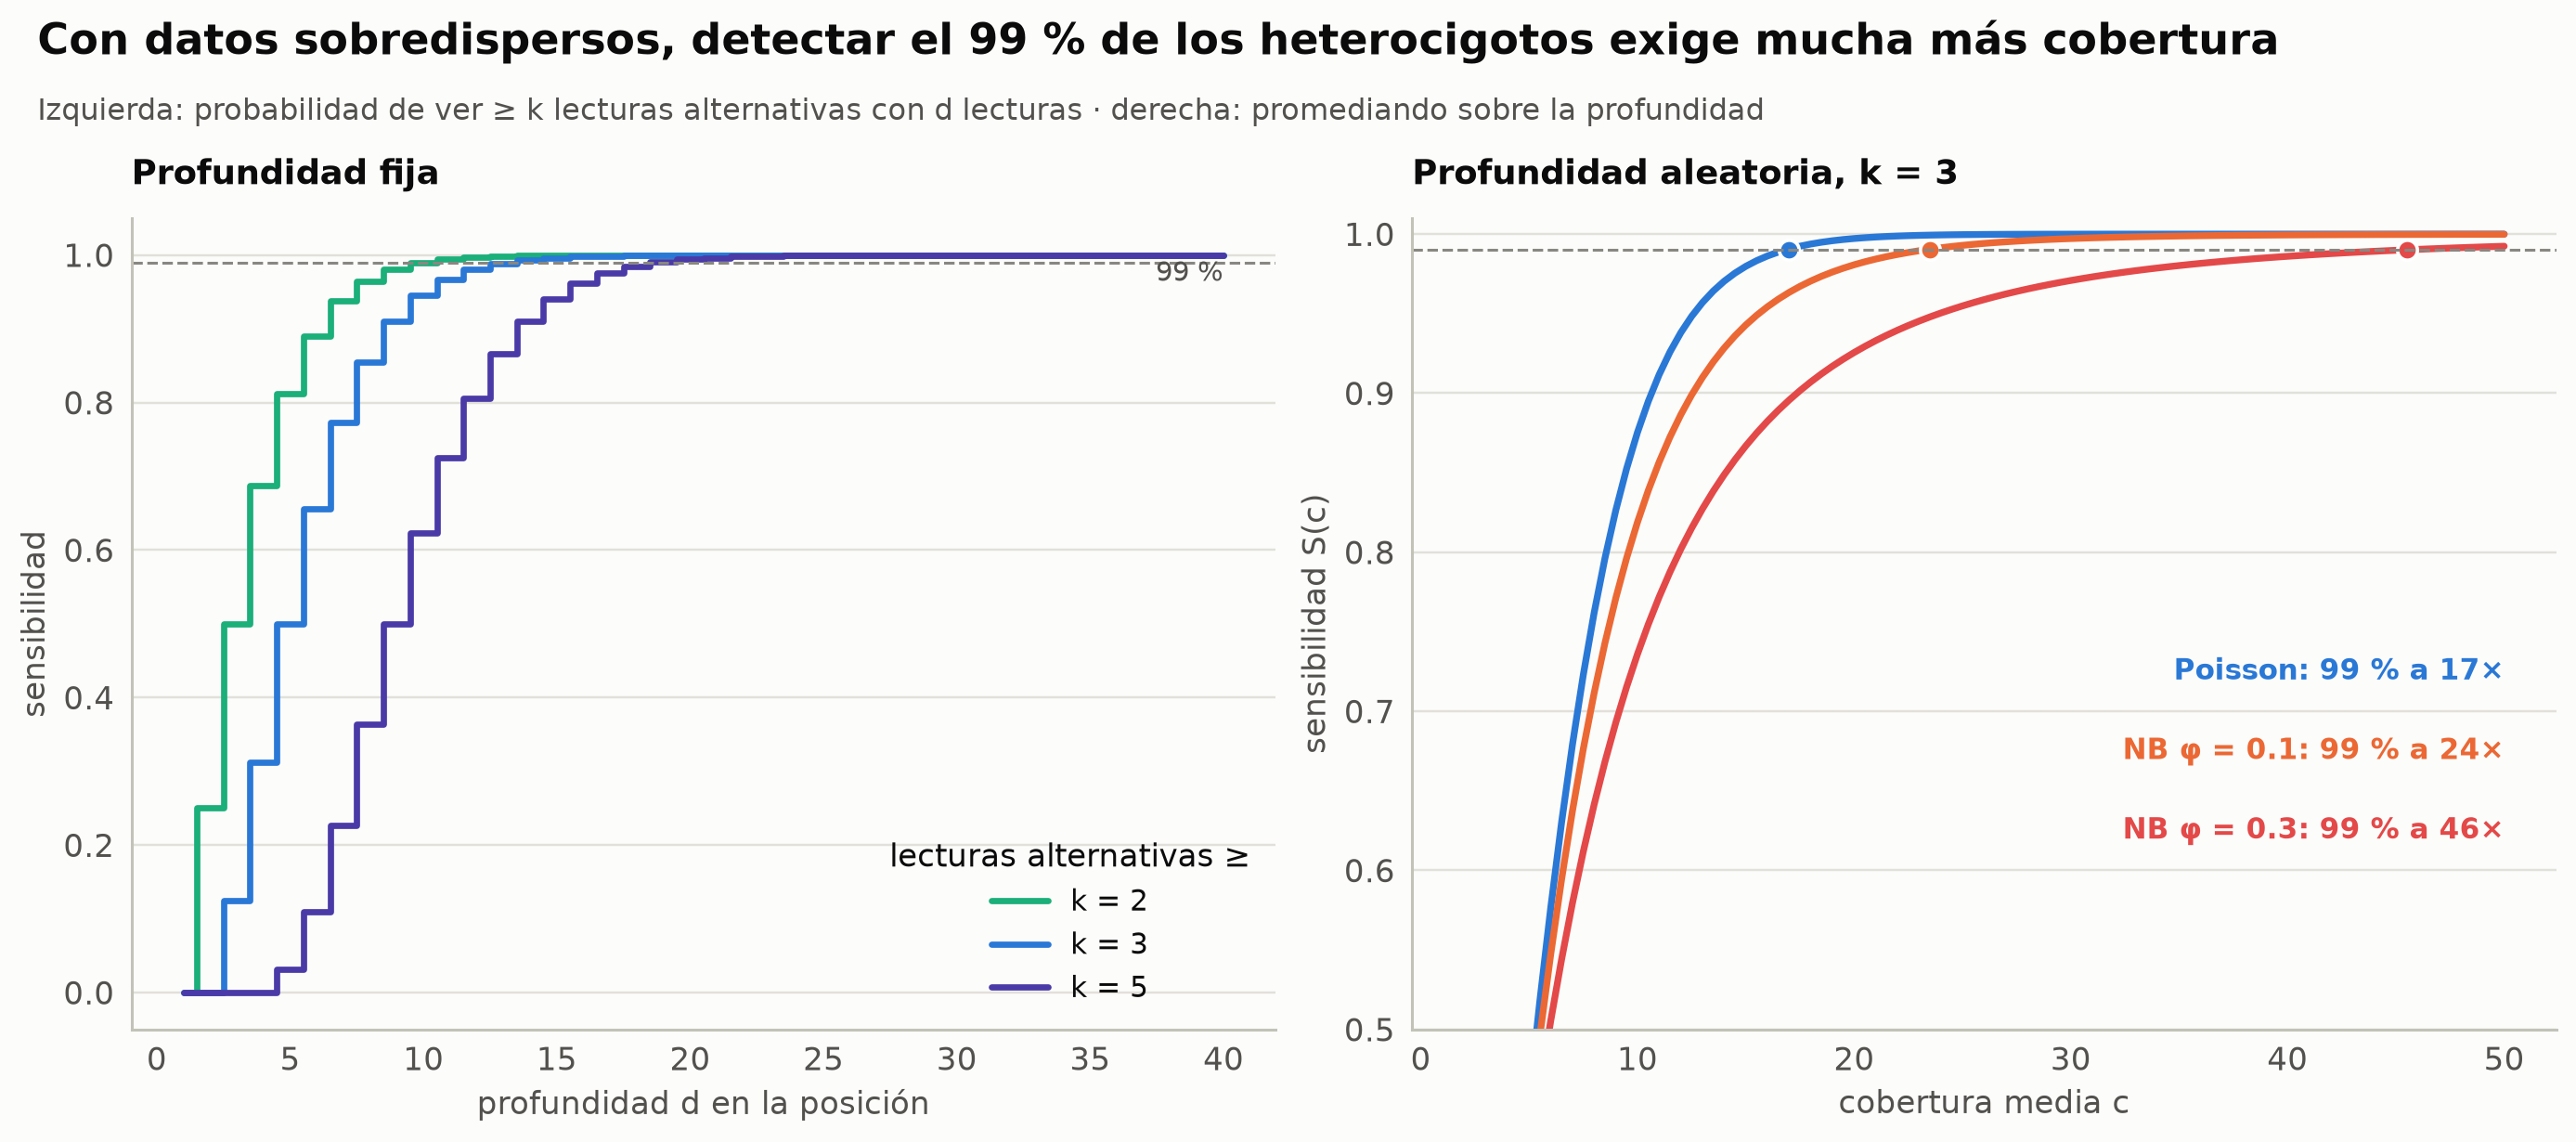

{'Poisson': '17×', 'NB φ = 0.1': '24×', 'NB φ = 0.3': '46×'}


In [26]:
def het_sensitivity_fixed(d, k):
    """P(al menos k lecturas alternativas | profundidad d) en un heterocigoto."""
    return binom.sf(k - 1, d, 0.5)

def het_sensitivity(c, k, phi=0.0):
    """Sensibilidad promediada sobre la profundidad D ~ Poisson(c) o binomial negativa(c, φ)."""
    d = np.arange(int(c + 30 * np.sqrt(c + phi * c**2)) + 50)      # suficiente para cubrir toda la distribución
    return float(np.sum(nb_pmf(d, c, phi) * het_sensitivity_fixed(d, k)))

print(f"d = 10, k = 3: {het_sensitivity_fixed(10, 3):.4f}   ·   d = 20, k = 3: {het_sensitivity_fixed(20, 3):.5f}")

d_ax = np.arange(1, 41)
c_ax = np.linspace(2, 50, 97)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for k_min, col in [(2, ec.AQUA), (3, ec.BLUE), (5, ec.VIOLET)]:
    axes[0].step(d_ax, het_sensitivity_fixed(d_ax, k_min), where="mid", color=col, lw=2.2, label=f"k = {k_min}")
axes[0].axhline(0.99, color=ec.MUTED, lw=1, ls="--"); axes[0].text(40, 0.965, "99 %", ha="right", fontsize=9.5, color=ec.INK_2)
axes[0].set_xlabel("profundidad d en la posición"); axes[0].set_ylabel("sensibilidad")
axes[0].set_title("Profundidad fija", loc="left", fontsize=12)
axes[0].legend(frameon=False, loc="lower right", title="lecturas alternativas ≥")
needed = {}
for i, (phi, col, lab) in enumerate([(0, ec.BLUE, "Poisson"), (0.1, ec.ORANGE, "NB φ = 0.1"), (0.3, ec.RED, "NB φ = 0.3")]):
    s = np.array([het_sensitivity(c, 3, phi) for c in c_ax])
    axes[1].plot(c_ax, s, color=col, lw=2.4)
    c99 = c_ax[np.argmax(s >= 0.99)] if (s >= 0.99).any() else np.nan
    needed[lab] = c99
    axes[1].text(50, 0.72 - 0.05 * i, f"{lab}: 99 % a {c99:.0f}×" if np.isfinite(c99) else f"{lab}: < 99 % a 50×",
                 color=col, fontsize=10, fontweight="bold", ha="right")
    if np.isfinite(c99):
        axes[1].plot(c99, 0.99, "o", color=col, ms=7, mec="white", mew=1.2)
axes[1].axhline(0.99, color=ec.MUTED, lw=1, ls="--")
axes[1].set_ylim(0.5, 1.01); axes[1].set_xlabel("cobertura media c"); axes[1].set_ylabel("sensibilidad S(c)")
axes[1].set_title("Profundidad aleatoria, k = 3", loc="left", fontsize=12)
ec.fig_title(fig, "Con datos sobredispersos, detectar el 99 % de los heterocigotos exige mucha más cobertura",
             "Izquierda: probabilidad de ver ≥ k lecturas alternativas con d lecturas · derecha: promediando sobre la profundidad")
plt.show()
print({k: f"{v:.0f}×" for k, v in needed.items()})

> 🔎 **Qué observamos.** Con profundidad fija, la sensibilidad sube en escalones (y con pequeños dientes de sierra,
> porque la binomial es discreta) y supera el 99 % a partir de $d = 14$ para $k = 3$. Pero una cobertura **media** de
> 14× no basta: muchas posiciones tendrán menos. Con profundidad Poisson hacen falta ~17×; con sobredispersión
> moderada ($\varphi = 0.1$), ~24×, y con $\varphi = 0.3$, ~46×: casi el triple que con la Poisson. De ahí
> sale la cifra estándar de **30×** para genomas humanos: con datos reales, algo sobredispersos, es lo que garantiza
> encontrar casi todos los heterocigotos. Es un argumento **complementario** al de la sección 9: allí pedíamos
> $k = 10$ lecturas en el 99 % del genoma (≈ 29× con $r = 10$); aquí, ver el alelo alternativo al menos 3 veces en el
> 99 % de los heterocigotos (≈ 24× con $\varphi = 0.1$). Ambos caminos llevan a la misma región de 25–30×.

¿Y por qué no pedir $k = 1$? Porque también hay **errores de secuenciación**. Si cada base tiene una probabilidad
$\varepsilon$ de error, la probabilidad de ver por azar $k$ lecturas con **la misma** base errónea es pequeña… pero se
multiplica por miles de millones de posiciones.

In [27]:
eps, d_fp = 0.01, 30
for k_min in (1, 2, 3, 5):
    p_fp = binom.sf(k_min - 1, d_fp, eps / 3)          # errores hacia una base concreta
    print(f"k = {k_min}: P(falso positivo por posición) = {p_fp:.2e} → en 3.1e9 posiciones ≈ {p_fp * 3.1e9:,.0f}")

k = 1: P(falso positivo por posición) = 9.53e-02 → en 3.1e9 posiciones ≈ 295,472,506
k = 2: P(falso positivo por posición) = 4.54e-03 → en 3.1e9 posiciones ≈ 14,081,787
k = 3: P(falso positivo por posición) = 1.41e-04 → en 3.1e9 posiciones ≈ 435,749
k = 5: P(falso positivo por posición) = 5.47e-08 → en 3.1e9 posiciones ≈ 170


> 🔎 **Qué observamos.** Con un 1 % de errores y 30×, exigir una sola lectura alternativa produciría ~300 millones de
> falsos positivos en un genoma humano; con $k = 3$, todavía cientos de miles. Por eso los programas reales (GATK,
> DeepVariant, bcftools) no cuentan lecturas sin más: usan la **calidad de cada base** y modelos de verosimilitud del
> genotipo. Ése es el tema del **Módulo 9**; aquí nos basta con entender que la profundidad es la materia prima de
> esa decisión.

✅ **Compruebe su comprensión.** ¿Qué probabilidad hay de no ver **ninguna** lectura alternativa en un heterocigoto con
$d = 8$? (Respuesta: $0.5^{8} = 1/256 \approx 0.4\,\%$. Y la de verlas **todas** alternativas es la misma: con 8
lecturas, un heterocigoto parece homocigoto una de cada 128 veces.)

## 11. Duplicados de PCR y curvas de saturación

Una biblioteca de secuenciación contiene un número **finito** de moléculas distintas, $M$ (su **complejidad**). Cada
lectura toma al azar una de esas moléculas, **con reemplazo**: la misma molécula puede leerse dos veces, y entonces
tenemos un **duplicado**. Los duplicados no aportan información nueva (son la misma molécula original) y se marcan
y descartan (Picard `MarkDuplicates`, `samtools markdup`).

Al secuenciar más, cada vez más lecturas caen en moléculas ya vistas: el número de **moléculas distintas
observadas** $D$ (las lecturas únicas) se **satura**. ¡Es exactamente el mismo problema de la sección 3! Allí las
lecturas caían sobre bases; aquí caen sobre moléculas. La probabilidad de que una molécula concreta no se haya leído
nunca tras $N$ lecturas es $(1 - 1/M)^N \approx e^{-N/M}$, y la esperanza de $D$ es $M$ veces la probabilidad de lo
contrario (es la ecuación de complejidad del libro, capítulo 6, con su misma notación):

$$
\boxed{\;\mathbb{E}[D] = M\left[1 - \left(1 - \tfrac{1}{M}\right)^{N}\right] \approx M\left(1 - e^{-N/M}\right)\;},
\qquad
\text{tasa de duplicados} = 1 - \frac{\mathbb{E}[D]}{N}
$$

Si la PCR amplificó unas moléculas más que otras (con un "peso" $W$ que sigue una Gamma de media 1 y forma $a$),
promediando $e^{-NW/M}$ sobre esa Gamma se obtiene otra fórmula cerrada, que satura **antes**:

$$
\mathbb{E}[D] = M\left[1 - \left(1 + \frac{N}{aM}\right)^{-a}\right]
\qquad (a \to \infty \text{ recupera el caso uniforme})
$$

| Símbolo | Significado |
|---|---|
| $M$ | complejidad de la biblioteca: número de moléculas distintas |
| $N$ | lecturas (o pares) secuenciadas |
| $D$ | moléculas distintas observadas al menos una vez (= lecturas únicas, no duplicadas). **Ojo:** en esta sección $D$ cuenta moléculas, no es la profundidad; el libro usa la misma letra |
| $N/M$ | "cobertura de la biblioteca" |
| $a$ | forma de la Gamma: pequeño = amplificación muy desigual |

### Ejemplo a mano: $M = 10$ millones

| $N$ | $N/M$ | $\mathbb{E}[D] = M(1 - e^{-N/M})$ | duplicados $1 - \mathbb{E}[D]/N$ |
|---|---|---|---|
| 5 M | 0.5 | 3.93 M | 21.3 % |
| 10 M | 1 | 6.32 M | 36.8 % |
| 20 M | 2 | 8.65 M | 56.8 % |
| 40 M | 4 | 9.82 M | 75.5 % |

Pasar de 20 a 40 millones de lecturas **duplica el costo** y sólo añade 1.2 millones de lecturas útiles. Esta misma
ecuación es la que usa Picard (`EstimateLibraryComplexity`) para estimar $M$. El programa **preseq** (Daley y Smith,
2013) va más allá: extrapola la curva sin suponer una forma concreta, a partir de cuántas moléculas se vieron 1, 2, 3…
veces en una secuenciación inicial poco profunda.

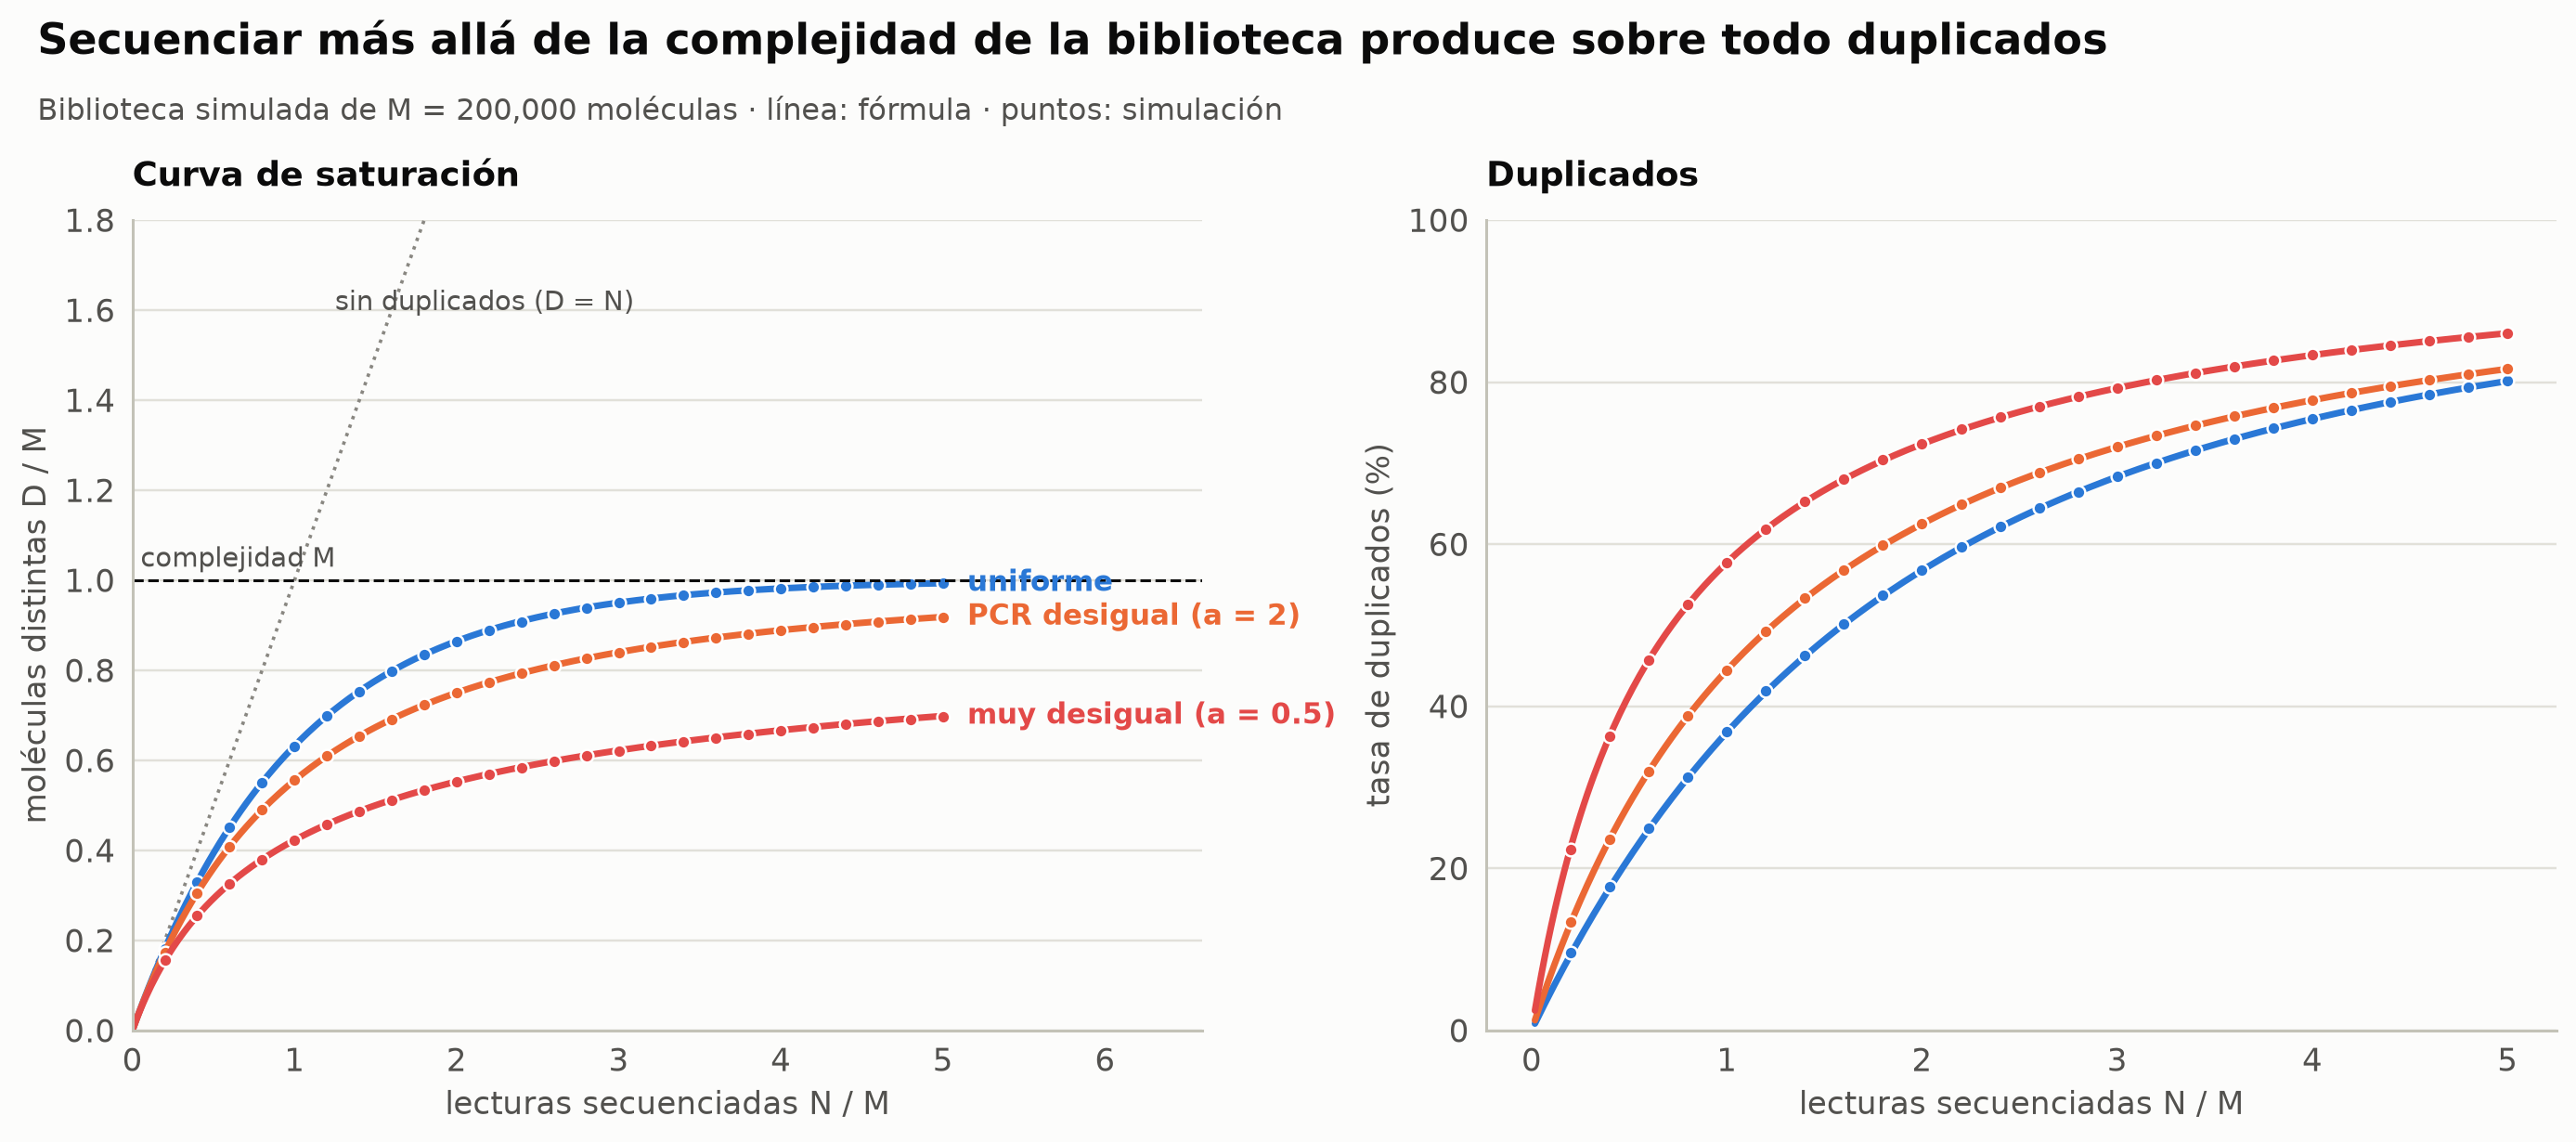

In [28]:
M_LIB = 200_000
n_max = 5 * M_LIB
n_pts = np.linspace(0, n_max, 26).astype(int)[1:]

def unique_curve(weights):
    """Simula n_max lecturas de una biblioteca y cuenta las moléculas únicas vistas en las primeras n."""
    sample = rng.choice(M_LIB, size=n_max, p=None if weights is None else weights / weights.sum())
    _, first = np.unique(sample, return_index=True)       # primera vez que se ve cada molécula
    return np.searchsorted(np.sort(first), n_pts)

def u_theory(n, M, a=None):
    return M * (1 - np.exp(-n / M)) if a is None else M * (1 - (1 + n / (a * M)) ** (-a))

n_line = np.linspace(0, n_max, 300)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
axes[0].plot(n_line / M_LIB, n_line / M_LIB, color=ec.MUTED, lw=1.2, ls=":")
axes[0].text(1.25, 1.6, "sin duplicados (D = N)", color=ec.INK_2, fontsize=9.5, rotation=0)
for a, col, lab in [(None, ec.BLUE, "uniforme"), (2, ec.ORANGE, "PCR desigual (a = 2)"), (0.5, ec.RED, "muy desigual (a = 0.5)")]:
    w = None if a is None else rng.gamma(a, 1 / a, M_LIB)
    u_sim = unique_curve(w)
    u_th = u_theory(n_line, M_LIB, a)
    axes[0].plot(n_line / M_LIB, u_th / M_LIB, color=col, lw=2.3)
    axes[0].plot(n_pts / M_LIB, u_sim / M_LIB, "o", color=col, ms=4.5, mec="white", mew=0.8)
    axes[0].text(5.15, u_th[-1] / M_LIB, lab, color=col, fontsize=10, fontweight="bold", va="center")
    dup_th = 1 - u_th[1:] / n_line[1:]
    axes[1].plot(n_line[1:] / M_LIB, dup_th * 100, color=col, lw=2.3)
    axes[1].plot(n_pts / M_LIB, (1 - u_sim / n_pts) * 100, "o", color=col, ms=4.5, mec="white", mew=0.8)
axes[0].axhline(1, color=ec.INK, lw=1, ls="--"); axes[0].text(0.05, 1.03, "complejidad M", fontsize=9.5, color=ec.INK_2)
axes[0].set_xlim(0, 6.6); axes[0].set_ylim(0, 1.8)
axes[0].set_xlabel("lecturas secuenciadas N / M"); axes[0].set_ylabel("moléculas distintas D / M")
axes[0].set_title("Curva de saturación", loc="left", fontsize=12)
axes[1].set_xlabel("lecturas secuenciadas N / M"); axes[1].set_ylabel("tasa de duplicados (%)")
axes[1].set_ylim(0, 100); axes[1].set_title("Duplicados", loc="left", fontsize=12)
ec.fig_title(fig, "Secuenciar más allá de la complejidad de la biblioteca produce sobre todo duplicados",
             f"Biblioteca simulada de M = {M_LIB:,} moléculas · línea: fórmula · puntos: simulación")
plt.show()

> 🔎 **Qué observamos.** Las simulaciones siguen las fórmulas. Con amplificación uniforme, al secuenciar tantas
> lecturas como moléculas hay ($N = M$) ya se ha visto el 63 % de la biblioteca y el 37 % de las lecturas son
> duplicados; con amplificación desigual la curva se aplana antes, porque las moléculas "favoritas" acaparan las
> lecturas. La lección práctica: si una secuenciación inicial muestra muchos duplicados, **no** tiene sentido pedir más
> lecturas de la misma biblioteca; hay que preparar una biblioteca nueva, más compleja.

Con la fórmula podemos **estimar $M$** a partir de una secuenciación de prueba y predecir cuántas lecturas útiles
dará una más profunda. Sólo hay que resolver $D = M(1 - e^{-N/M})$ para $M$:

In [29]:
from scipy.optimize import brentq

def estimate_complexity(n, u):
    """M tal que M·(1 − e^(−N/M)) = D (ecuación de Lander-Waterman para bibliotecas); n = N, u = D."""
    return brentq(lambda M: M * (1 - np.exp(-n / M)) - u, u, 1e4 * n)

n_pilot, u_pilot = 2_000_000, 1_800_000
M_hat = estimate_complexity(n_pilot, u_pilot)
print(f"Prueba: {n_pilot:,} lecturas, {u_pilot:,} únicas ({1 - u_pilot / n_pilot:.0%} duplicados) → M ≈ {M_hat / 1e6:.1f} millones")
for n in (10e6, 20e6, 40e6):
    u = u_theory(n, M_hat)
    print(f"  con {n / 1e6:>4.0f} M lecturas: {u / 1e6:5.1f} M únicas · duplicados {1 - u / n:.0%}")

Prueba: 2,000,000 lecturas, 1,800,000 únicas (10% duplicados) → M ≈ 9.3 millones
  con   10 M lecturas:   6.1 M únicas · duplicados 39%
  con   20 M lecturas:   8.2 M únicas · duplicados 59%
  con   40 M lecturas:   9.2 M únicas · duplicados 77%


> 🔎 **Qué observamos.** Un 10 % de duplicados con 2 millones de lecturas parece poco, pero indica una biblioteca de
> sólo ~9.3 millones de moléculas: secuenciar 40 millones de lecturas de ella daría más del 75 % de duplicados. Esta
> cuenta, hecha **antes** de encargar la secuenciación grande, ahorra mucho dinero.

## 12. Planificar un experimento: la calculadora final

Juntemos todo. Para pedir un servicio de secuenciación hay que traducir "quiero $c$ de cobertura útil" en **lecturas
brutas** o **gigabases** (Gb), sabiendo que parte de lo secuenciado se pierde por el camino:

$$
\text{Gb brutas} = \frac{c \cdot G}{f_{\text{obj}} \cdot (1 - f_{\text{dup}}) \cdot f_{\text{útil}}} \times 10^{-9},
\qquad
N_{\text{pares}} = \frac{\text{Gb brutas} \times 10^{9}}{2L}
$$

| Símbolo | Significado | Valor típico (ilustrativo) |
|---|---|---|
| $c$ | cobertura útil deseada | 30× (genoma humano), 100× (exoma) |
| $G$ | tamaño del genoma o de la región objetivo | 3.1 Gb; ~50 Mb para un exoma |
| $f_{\text{obj}}$ | fracción de lecturas que cae en la región objetivo (captura) | 1 en genomas; 0.6–0.8 en exomas |
| $f_{\text{dup}}$ | tasa de duplicados | 5–20 % |
| $f_{\text{útil}}$ | fracción que pasa filtros de calidad y se alinea bien | 0.9–0.95 |
| $L$ | longitud de cada lectura del par | 150 pb |

### Ejemplo a mano: exoma humano a 100×

Región objetivo $G = 50$ Mb, $f_{\text{obj}} = 0.7$, $f_{\text{dup}} = 0.15$, $f_{\text{útil}} = 0.95$:

$$
\frac{100 \times 5\times10^{7}}{0.7 \times 0.85 \times 0.95} = \frac{5\times10^{9}}{0.565} \approx 8.8\ \text{Gb}
\;\Longrightarrow\;
\frac{8.8\times10^{9}}{300} \approx 29 \text{ millones de pares de } 2\times150
$$

Compare con los ~100 Gb de un genoma completo a 30×: un exoma cuesta unas diez veces menos en secuenciación, a cambio
de ver sólo ~1.5 % del genoma.

In [30]:
def plan_experiment(name, G, c, L=150, on_target=1.0, dup=0.08, usable=0.95, phi=0.05, diploid=True):
    """Gb brutas y pares de lecturas necesarios para una cobertura útil c, con predicciones de calidad."""
    raw_bases = c * G / (on_target * (1 - dup) * usable)
    pairs = raw_bases / (2 * L)
    return {"experimento": name, "G (Mb)": G / 1e6, "c útil": c, "Gb brutas": raw_bases / 1e9,
            "pares (M)": pairs / 1e6,
            "% bases con D ≤ 9 (NB)": 100 * nb_pmf(np.arange(10), c, phi).sum(),
            "sens. heterocigoto (k=3)": het_sensitivity(c, 3, phi) if diploid else np.nan}

plans = pd.DataFrame([
    plan_experiment("SARS-CoV-2 (amplicones)", 29_903, 1000, on_target=0.9, dup=0.4, diploid=False),
    plan_experiment("E. coli, ensamblaje", 4.64e6, 100, diploid=False),
    plan_experiment("S. cerevisiae", 12.1e6, 50),
    plan_experiment("Exoma humano", 50e6, 100, on_target=0.7, dup=0.15),
    plan_experiment("Genoma humano 30×", 3.1e9, 30),
    plan_experiment("Genoma humano 60× (tumor)", 3.1e9, 60),
])
plans.style.format({"G (Mb)": "{:,.3g}", "Gb brutas": "{:,.3g}", "pares (M)": "{:,.3g}",
                    "% bases con D ≤ 9 (NB)": "{:.2g}", "sens. heterocigoto (k=3)": "{:.4f}"}, na_rep="—")

,experimento,G (Mb),c útil,Gb brutas,pares (M),% bases con D ≤ 9 (NB),sens. heterocigoto (k=3)
0,SARS-CoV-2 (amplicones),0.0299,1000,0.0583,0.194,6e-26,—
1,"E. coli, ensamblaje",4.64,100,0.531,1.77,5.8e-08,—
2,S. cerevisiae,12.1,50,0.692,2.31,0.00076,1.0000
3,Exoma humano,50,100,8.85,29.5,5.8e-08,1.0000
4,Genoma humano 30×,3.1e+03,30,106,355,0.15,0.9993
5,Genoma humano 60× (tumor),3.1e+03,60,213,709,7.9e-05,1.0000


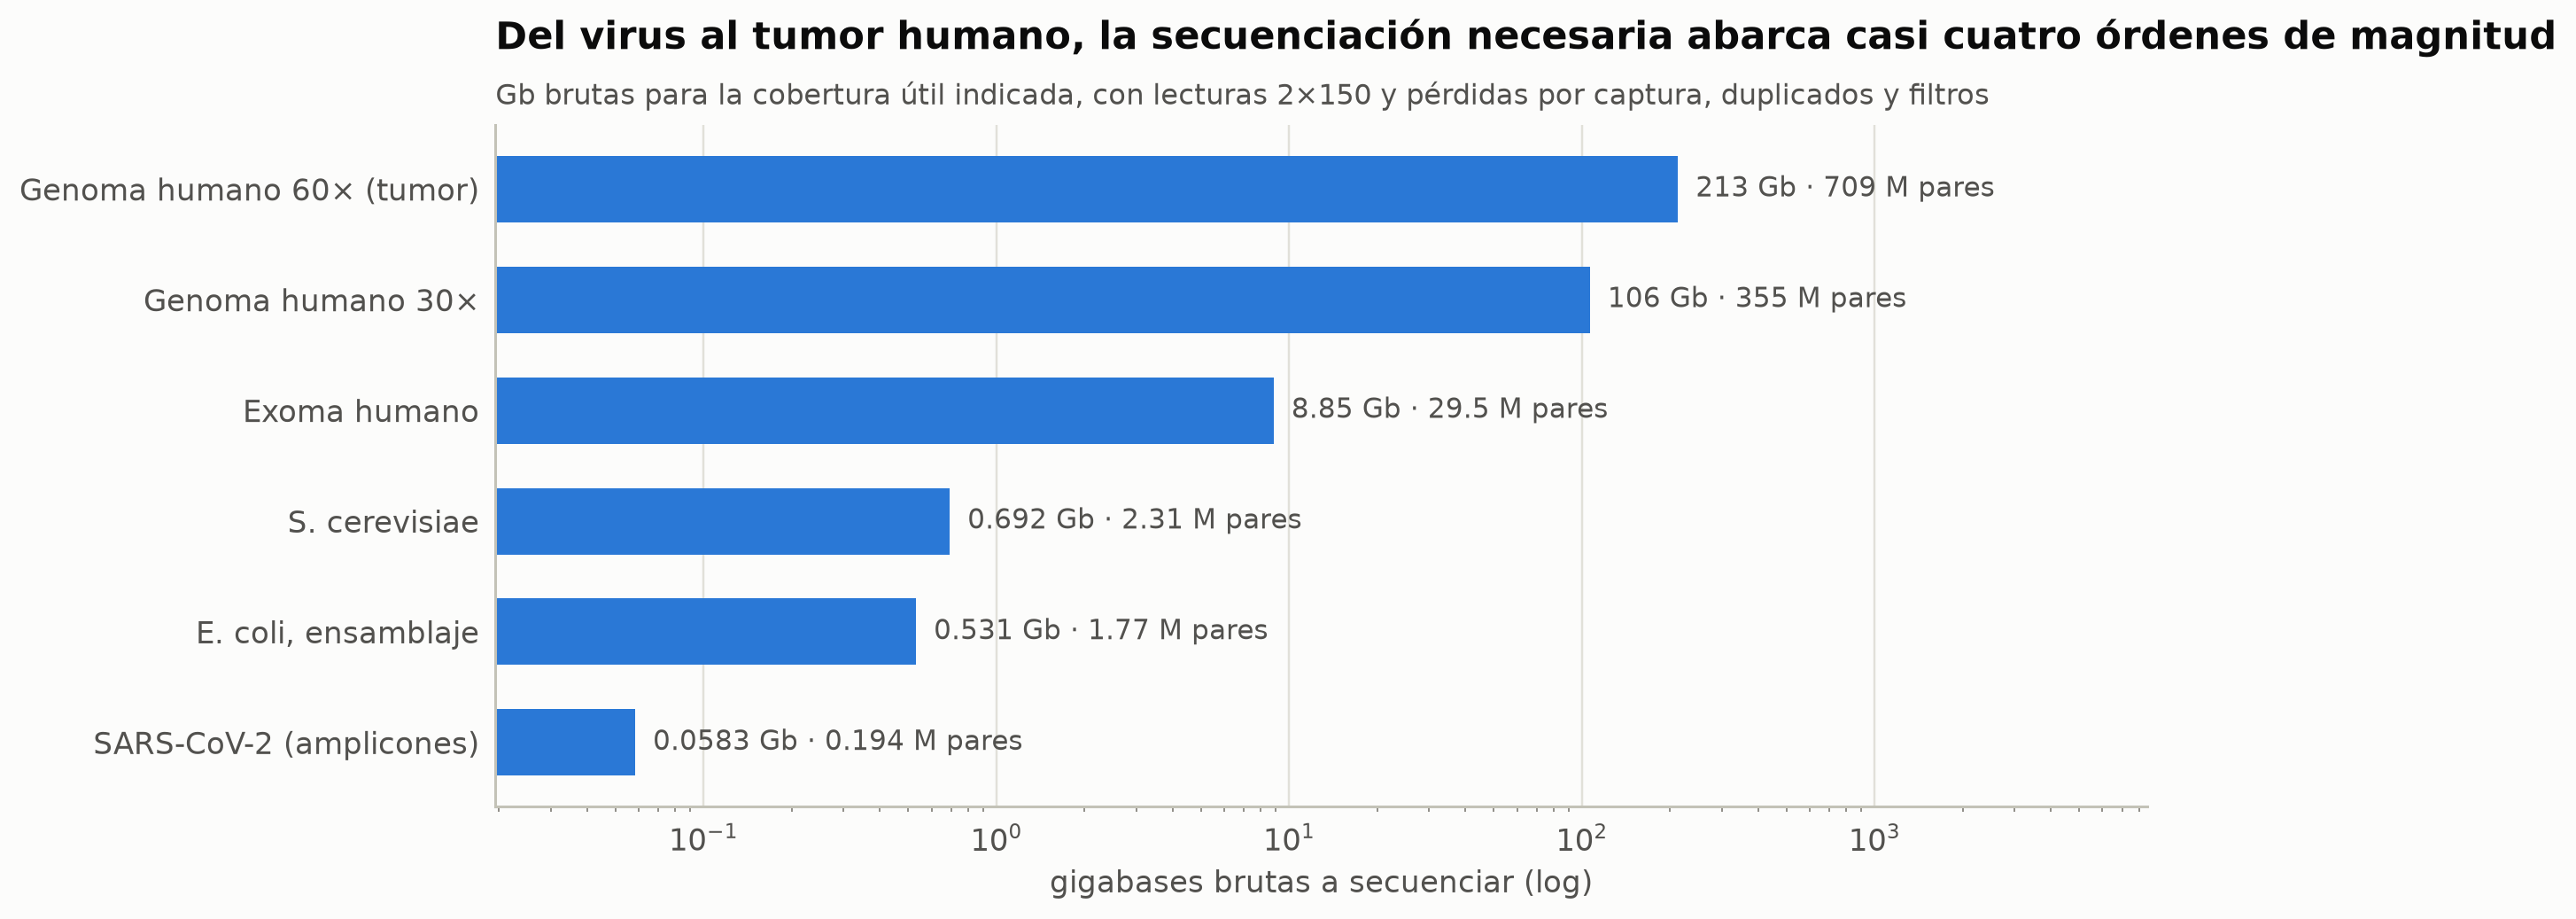

In [31]:
fig, ax = plt.subplots(figsize=(11, 4.6))
order = plans.sort_values("Gb brutas")
ypos = np.arange(len(order))
ax.barh(ypos, order["Gb brutas"], color=ec.BLUE, height=0.6)
ax.set_xscale("log"); ax.set_yticks(ypos, order["experimento"])
for y, (gb, pr) in enumerate(zip(order["Gb brutas"], order["pares (M)"])):
    ax.text(gb * 1.15, y, f"{gb:,.3g} Gb · {pr:,.3g} M pares", va="center", fontsize=10, color=ec.INK_2)
ax.set_xlim(order["Gb brutas"].min() / 3, order["Gb brutas"].max() * 40)
ax.set_xlabel("gigabases brutas a secuenciar (log)")
ax.xaxis.grid(True, color=ec.GRID); ax.yaxis.grid(False)
ec.title(ax, "Del virus al tumor humano, la secuenciación necesaria abarca casi cuatro órdenes de magnitud",
         "Gb brutas para la cobertura útil indicada, con lecturas 2×150 y pérdidas por captura, duplicados y filtros")
plt.show()

> 🔎 **Qué observamos.** Un genoma viral a 1 000× cabe en una fracción mínima de una corrida; una bacteria a 100×
> necesita ~0.5 Gb, de modo que decenas de bacterias comparten una misma celda de flujo (con códigos de barras). Un
> genoma humano a 30× requiere ~100 Gb y un tumor a 60×, el doble. Las columnas de la tabla recuerdan que la cobertura
> media no lo es todo: con una dispersión modesta ($\varphi = 0.05$), el 30× humano deja ~0.15 % de bases por debajo de
> 10× (unos 5 millones de posiciones) y la sensibilidad para heterocigotos ronda el 99.9 %. Las columnas suponen
> $\varphi = 0.05$ para todos; en un exoma, con captura irregular, la dispersión real suele ser bastante mayor.

✅ **Compruebe su comprensión.** Un laboratorio le ofrece "100 millones de pares de 2×150" por un precio fijo.
¿Qué cobertura útil tendrá un genoma humano con 8 % de duplicados y 95 % de lecturas útiles? (Respuesta:
$100\times10^6 \times 300 = 30$ Gb brutas; útiles $30 \times 0.92 \times 0.95 = 26.2$ Gb; $c = 26.2/3.1 \approx 8.5\times$.
Suficiente para detectar variantes comunes en estudios de población, no para un diagnóstico clínico.)

## 13. Ejercicios

**Ejercicio 1 — Levadura a mano.** Se secuencia *S. cerevisiae* ($G = 12.1$ Mb) con 2 millones de pares de 2×150 pb.
Calcule (a) la cobertura; (b) la fracción del genoma sin cubrir y el número de bases correspondiente; (c) el número de
contigs esperado por Lander-Waterman con $T = 30$ pb, y la longitud media de los contigs. Compruebe (c) con una
simulación.

**Ejercicio 2 — Variantes somáticas.** En un tumor, una mutación está presente en el 10 % de las moléculas (frecuencia
alélica, VAF, de 0.1). Si el programa exige al menos $k = 5$ lecturas alternativas, ¿qué profundidad **fija** hace
falta para detectarla con un 95 % de probabilidad? ¿Y qué cobertura **media**, si la profundidad es Poisson? Compare
con el caso heterocigoto (VAF = 0.5).

**Ejercicio 3 — ¿Vale la pena secuenciar más?** Una corrida de prueba produce 5 millones de lecturas, de las que 4.2
millones son únicas. Estime la complejidad $M$ de la biblioteca, las lecturas únicas y la tasa de duplicados que se
obtendrían con 50 millones de lecturas, y cuántas lecturas **secuenciadas** hacen falta para llegar a 8 millones de
únicas.

**Ejercicio 4 — Amplitud real frente a teoría.** Con la simulación con sesgo GC de la sección 7 (`d_gc`), calcule la
fracción del genoma de *E. coli* con $D \geq 10$ y con $D \geq 20$. Compárela con la predicción de la Poisson(30) y de
la binomial negativa ajustada. ¿Cuál acierta más? ¿Por qué ninguna es perfecta?

**Ejercicio 5 — Secuenciar un brote.** Un laboratorio de vigilancia secuenciará 48 aislados bacterianos de un brote
hospitalario ($G = 5$ Mb cada uno). Para comparar aislados exige **al menos 20 lecturas** en el **99.9 %** del genoma
($\alpha = 0.001$), y una corrida piloto indica una profundidad sobredispersa con $r = 10$.
(a) Demuestre, poniendo $k = 0$ en la binomial negativa, que la fracción sin ninguna lectura es $(1 + c/r)^{-r}$, y
compárela con $e^{-c}$ para $c = 10$ y $r = 5$ (el ejercicio del libro). (b) ¿Qué cobertura media hace falta con la
Poisson y con la binomial negativa? (c) Si la cobertura efectiva es el 75 % de la bruta (duplicados, filtros), ¿cuántas
gigabases brutas hay que pedir para los 48 aislados?

In [32]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
G_y, L_y, N_y, T_y = 12.1e6, 150, 4e6, 30
c_y = coverage(L_y, N_y, G_y)
theta_y = T_y / L_y
print(f"(a) c = 150 × 4e6 / 12.1e6 = {c_y:.1f}×")
print(f"(b) sin cubrir: e^(−c) = {np.exp(-c_y):.2e} → {G_y * np.exp(-c_y):.2e} bases (ninguna, en teoría)")
print(f"(c) contigs = N·e^(−c(1−θ)) = {lw_contigs(c_y, L_y, G_y, theta_y):.2e} → prácticamente 1 contig por cromosoma"
      " si no hubiera repeticiones")
# Con c ≈ 50 no se aprecia nada: simulamos a 6× para ver la fórmula en acción
G_s = int(G_y); c_s = 6
n_c, lens = count_contigs(simulate_starts(reads_needed(c_s, L_y, G_s), G_s, rng), L_y, G_s, theta_y)
print(f"    A {c_s}× (θ = {theta_y}): teoría {lw_contigs(c_s, L_y, G_s, theta_y):,.0f} contigs de "
      f"{lw_contig_length(c_s, L_y, theta_y):,.0f} pb · simulación {n_c:,} contigs de {lens.mean():,.0f} pb")

(a) c = 150 × 4e6 / 12.1e6 = 49.6×
(b) sin cubrir: e^(−c) = 2.92e-22 → 3.53e-15 bases (ninguna, en teoría)
(c) contigs = N·e^(−c(1−θ)) = 2.37e-11 → prácticamente 1 contig por cromosoma si no hubiera repeticiones
    A 6× (θ = 0.2): teoría 3,983 contigs de 3,043 pb · simulación 3,993 contigs de 3,034 pb


In [33]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
def sens_vaf(d, vaf, k):
    return binom.sf(k - 1, d, vaf)

for vaf in (0.1, 0.5):
    d_ok = next(d for d in range(1, 2000) if sens_vaf(d, vaf, 5) >= 0.95)
    c_ok = next(c for c in range(1, 2000)
                if np.sum(poisson.pmf(np.arange(4000), c) * sens_vaf(np.arange(4000), vaf, 5)) >= 0.95)
    print(f"VAF = {vaf}: profundidad fija ≥ {d_ok} · cobertura media Poisson ≥ {c_ok}×")
print("Una variante al 10 % exige ~5 veces más profundidad que un heterocigoto: por eso los tumores se secuencian a")
print("60–100× (genoma) o a cientos o miles de × (paneles dirigidos).")

VAF = 0.1: profundidad fija ≥ 89 · cobertura media Poisson ≥ 92×
VAF = 0.5: profundidad fija ≥ 16 · cobertura media Poisson ≥ 19×
Una variante al 10 % exige ~5 veces más profundidad que un heterocigoto: por eso los tumores se secuencian a
60–100× (genoma) o a cientos o miles de × (paneles dirigidos).


In [34]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
M3 = estimate_complexity(5e6, 4.2e6)
u50 = u_theory(50e6, M3)
print(f"M ≈ {M3 / 1e6:.1f} millones de moléculas")
print(f"Con 50 M lecturas: {u50 / 1e6:.1f} M únicas, duplicados {1 - u50 / 50e6:.0%}")
n8 = brentq(lambda n: u_theory(n, M3) - 8e6, 1e6, 1e10)
print(f"Para 8 M únicas hacen falta {n8 / 1e6:.1f} M lecturas ({1 - 8e6 / n8:.0%} de duplicados)")

M ≈ 13.9 millones de moléculas
Con 50 M lecturas: 13.5 M únicas, duplicados 73%
Para 8 M únicas hacen falta 11.9 M lecturas (33% de duplicados)


In [35]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for thr in (10, 20):
    obs_b = np.mean(d_gc >= thr)
    p_b = poisson.sf(thr - 1, mu_g)
    nb_b = 1 - nb_pmf(np.arange(thr), mu_g, phi_g).sum()
    print(f"D ≥ {thr}: simulación {obs_b:.2%} · Poisson {p_b:.2%} · binomial negativa {nb_b:.2%}")
print("La NB acierta mucho más que la Poisson, pero no del todo: la profundidad real proviene de una curva de sesgo")
print("concreta (no de una Gamma) y las bases vecinas están correlacionadas, algo que ningún modelo por base captura.")

D ≥ 10: simulación 94.85% · Poisson 100.00% · binomial negativa 99.36%
D ≥ 20: simulación 84.88% · Poisson 97.81% · binomial negativa 84.79%
La NB acierta mucho más que la Poisson, pero no del todo: la profundidad real proviene de una curva de sesgo
concreta (no de una Gamma) y las bases vecinas están correlacionadas, algo que ningún modelo por base captura.


In [36]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
# (a) P(D = 0) = Γ(r)/(0!·Γ(r)) · (r/(r + c))^r · (c/(r + c))^0 = (r/(r + c))^r = (1 + c/r)^(−r)
c5, r5 = 10, 5
print(f"(a) c = 10, r = 5: (1 + c/r)^(−r) = 3^(−5) = {(1 + c5 / r5) ** -r5:.4f} · e^(−10) = {np.exp(-c5):.2e}"
      f" · cociente ≈ {(1 + c5 / r5) ** -r5 / np.exp(-c5):.0f}")
print(f"    comprobación con scipy: nbinom.pmf(0) = {nbinom.pmf(0, r5, r5 / (r5 + c5)):.4f}")
c_pois = coverage_needed(20, alpha=0.001)
c_nb = coverage_needed(20, alpha=0.001, r=10)
print(f"(b) ≥ 20 lecturas en el 99.9 %: Poisson {c_pois:.1f}× · binomial negativa (r = 10) {c_nb:.1f}×")
gb_raw = 48 * c_nb * 5e6 / 0.75 / 1e9
print(f"(c) {48} aislados × {c_nb:.1f}× × 5 Mb / 0.75 = {gb_raw:.1f} Gb brutas"
      f" (≈ {gb_raw * 1e9 / 300 / 1e6:.0f} M pares de 2×150)")
print("Con sesgo, secuenciar más rinde poco: la fracción sin leer baja como una potencia de c, no exponencialmente.")

(a) c = 10, r = 5: (1 + c/r)^(−r) = 3^(−5) = 0.0041 · e^(−10) = 4.54e-05 · cociente ≈ 91
    comprobación con scipy: nbinom.pmf(0) = 0.0041
(b) ≥ 20 lecturas en el 99.9 %: Poisson 36.7× · binomial negativa (r = 10) 77.1×
(c) 48 aislados × 77.1× × 5 Mb / 0.75 = 24.7 Gb brutas (≈ 82 M pares de 2×150)
Con sesgo, secuenciar más rinde poco: la fracción sin leer baja como una potencia de c, no exponencialmente.


## 📌 Resumen

* **Cobertura** media: $c = LN/G$ (en *paired-end*, cada par cuenta como dos lecturas). La **profundidad** es de cada
  base; la **amplitud** es la fracción del genoma cubierta.
* Con lecturas uniformes, la profundidad de una base es Binomial$(N, L/G) \approx$ **Poisson($c$)**: varianza igual a
  la media, coeficiente de variación $1/\sqrt{c}$.
* Fracción sin cubrir: $e^{-c}$; fracción cubierta: $1 - e^{-c}$; bases sin cubrir: $G e^{-c}$ (Clarke y Carbon, 1976).
* **Lander-Waterman (1988)**: con solapamiento mínimo $\theta = T/L$ y $\sigma = 1 - \theta$, hay $N e^{-c\sigma}$ contigs,
  $e^{c\sigma}$ lecturas por contig y una longitud media $L[(e^{c\sigma}-1)/c + \theta]$. El número de contigs es máximo
  en $c = 1/\sigma$. Con $\theta = 0$, los huecos miden en promedio $L/c$ y suman $G e^{-c}$.
* Las **repeticiones** más largas que la lectura imponen un piso de contigs que la cobertura no rompe; las **lecturas
  largas** lo eliminan.
* En datos reales, el **sesgo por GC**, los duplicados y la mapeabilidad producen **sobredispersión**: la profundidad
  se describe mejor con una **binomial negativa**, $\operatorname{Var} = \mu + \varphi\mu^2 = c + c^2/r$ ($\mu = c$, $\varphi = 1/r$). La misma media puede ocultar
  millones de bases con poca profundidad.
* **Diseño**: el menor $c$ con $P(D \geq k \mid c) \geq 1 - \alpha$. Para 10 lecturas en el 99 % del genoma: 18.8× (Poisson),
  29.4× (NB $r = 10$), 44.1× (NB $r = 5$); para 20 lecturas, 31.9×, 53.9× y 83.3×. Con sesgo, la fracción sin leer es
  $(1 + c/r)^{-r}$, que cae como una potencia de $c$ y no como $e^{-c}$. Planifique con la cobertura **efectiva**.
* Detectar un heterocigoto con $\geq k$ lecturas alternativas es un problema binomial; promediado sobre la profundidad
  explica por qué se piden **30×** para genomas humanos.
* La **saturación** de una biblioteca sigue $\mathbb{E}[D] = M(1 - e^{-N/M})$ ($D$ moléculas distintas, $N$ lecturas): la complejidad $M$ limita cuántas lecturas útiles
  se pueden obtener; preseq extrapola esta curva.
* Para planificar: Gb brutas $= cG/(f_{\text{obj}}(1 - f_{\text{dup}})f_{\text{útil}})$.

## 📚 Para profundizar

* Lander, E. S. & Waterman, M. S. (1988). Genomic mapping by fingerprinting random clones: a mathematical analysis.
  *Genomics* 2(3): 231–239.
* Clarke, L. & Carbon, J. (1976). A colony bank containing synthetic ColE1 hybrid plasmids representative of the
  entire *E. coli* genome. *Cell* 9(1): 91–99.
* Sims, D., Sudbery, I., Ilott, N. E., Heger, A. & Ponting, C. P. (2014). Sequencing depth and coverage: key
  considerations in genomic analyses. *Nature Reviews Genetics* 15(2): 121–132.
* Benjamini, Y. & Speed, T. P. (2012). Summarizing and correcting the GC content bias in high-throughput sequencing.
  *Nucleic Acids Research* 40(10): e72.
* Daley, T. & Smith, A. D. (2013). Predicting the molecular complexity of sequencing libraries. *Nature Methods*
  10(4): 325–327.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)